# Lección 16.2 · Redes de regulación génica y modelos dinámicos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-16-sistemas-redes/16.2_redes_regulacion_ode.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 16 — Biología de sistemas y redes** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 16.1 (grafos), cálculo básico (derivadas, exponencial), NumPy/SciPy; deseable: Módulo 11 (RNA-seq) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es una red de regulación génica (dirigida y con signo) y **modelar** la respuesta de un promotor
   con la **función de Hill**, incluida la regla $X_{90}/X_{10}=81^{1/n}$.
2. **Resolver** el modelo básico $dY/dt=\beta-\alpha Y$ y **calcular** el tiempo de respuesta $t_{1/2}=\ln2/\alpha$
   de una proteína de *E. coli* (ejemplo «Cuánto tarda en responder un gen»).
3. **Demostrar** por simulación que la **autorregulación negativa** acelera la respuesta (8,1 veces en el ejemplo del
   libro) y amortigua el ruido del promotor.
4. **Contar motivos de red** en la red transcripcional **real** de *E. coli* (RegulonDB) y **calcular** su puntuación
   $Z$ frente a redes aleatorizadas que conservan los grados.
5. **Simular** el *feed-forward loop* coherente tipo 1 y **mostrar** que filtra pulsos breves de señal.
6. **Analizar** el **interruptor biestable** de Gardner et al. en el plano de fases: nulclinas, puntos fijos,
   jacobiano, autovalores y separatriz (ejemplo «Biestabilidad con $\alpha_1=\alpha_2=10$ y $\beta=\gamma=2$»).
7. **Deducir** la condición de oscilación del **repressilator** de Elowitz y Leibler y **ubicar** un circuito en su
   diagrama de estabilidad.
8. **Implementar** el algoritmo de **Gillespie** y **comparar** la simulación estocástica con la ODE y con la
   distribución de Poisson de la ecuación maestra.
9. **Inferir** una red a partir de datos de expresión con **correlación** y con **GENIE3**, y **evaluarlas** con curvas
   de precisión-exhaustividad (AUPR).

## 🗺️ Mapa de la clase

1. Una bañera con termostato: la idea de la clase
2. De la unión al promotor a la función de Hill (🎛️ deslizador de cooperatividad)
3. El modelo básico: producción y eliminación («Cuánto tarda en responder un gen»)
4. Autorregulación negativa: acelerar sin desperdiciar
5. Motivos de red en la red real de *E. coli* (RegulonDB)
6. El *feed-forward loop* coherente: un filtro de persistencia (🎛️ duración del pulso)
7. El interruptor biestable: nulclinas y estabilidad (🎬 animación, 🎛️ plano de fases con deslizador)
8. El *repressilator*: oscilaciones (🎬 animación, 🎛️ diagrama de estabilidad)
9. Ruido: la ecuación maestra y el algoritmo de Gillespie (🎬 animación)
10. Inferir la red a partir de los datos: correlación frente a GENIE3 (🎛️ curvas PR)
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Redes de regulación génica y modelos dinámicos» del
> capítulo 16 del libro *Bioinformática Práctica*. Usamos exactamente sus símbolos, reproducimos con código sus ejemplos
> resueltos cifra por cifra y volvemos a correr sus simulaciones con los mismos parámetros y semillas; pero el notebook
> se puede seguir sin el libro. **Ojo con una trampa de notación que hereda de la literatura:** la letra $\beta$
> significa cosas distintas en cada modelo (fuerza del promotor en las secciones 2–4, cooperatividad en el
> interruptor, cociente de vidas medias en el *repressilator*). En cada tabla de símbolos le recordamos qué significa
> *en esa sección*.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import math, gzip, json, time
import plotly.express as px
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

T0_NOTEBOOK = time.time()
print("NumPy", np.__version__)

Entorno listo ✔  |  Colab: False


NumPy 2.5.3


## 1. Una bañera con termostato

Piense en una bañera con el grifo abierto y el desagüe destapado. El nivel del agua sube hasta que lo que entra por el
grifo iguala lo que sale por el desagüe, y ahí se estabiliza. Si queremos llenarla **más rápido** sin cambiar el nivel
final hay un truco: abrir el grifo a tope al principio y cerrarlo a medida que el agua se acerca a la marca, como hace
un termostato.

La concentración de una proteína en una célula se comporta exactamente como esa bañera:

* el **grifo** es la síntesis (transcripción y traducción);
* el **desagüe** es la degradación por proteasas y, sobre todo en bacterias, la **dilución**: cada vez que la célula se
  divide, las moléculas se reparten entre dos hijas;
* un gen que **reprime su propio promotor** es un termostato molecular.

Con dos o tres «bañeras» que se abren y cierran los grifos unas a otras, la célula construye **memorias** (el
interruptor biestable), **relojes** (el *repressilator*) y **filtros** (el *feed-forward loop*). Y esto no es solo
teoría: en el año 2000 dos grupos construyeron estos circuitos con piezas de ADN dentro de *E. coli*, y con ellos nació
la **biología sintética**.

### Redes dirigidas y con signo

Las redes de proteínas de la Lección 16.1 eran mapas **no dirigidos**: «A toca a B». Una red de regulación génica es
**dirigida**: sus nodos son genes, y una arista $X\to Y$ significa que el producto de $X$, un **factor de
transcripción**, cambia la tasa de transcripción de $Y$. Además tiene **signo**:

| Notación | Significado | Ejemplo en *E. coli* |
|---|---|---|
| $X\to Y$ | $X$ **activa** a $Y$ | CRP (con AMPc) activa los operones de azúcares alternativos |
| $X\dashv Y$ | $X$ **reprime** a $Y$ | LacI reprime el operón *lac* en ausencia de lactosa |
| $X\dashv X$ | **autorregulación negativa** | LexA reprime su propio gen (respuesta SOS) |

Saber **quién regula a quién** (la topología) no basta para saber **qué hace** un circuito: necesitamos ecuaciones
que digan cómo cambian las concentraciones en el tiempo. El libro de texto de referencia para todo lo que sigue es el
de Uri Alon (*An Introduction to Systems Biology*).

## 2. De la unión al promotor a la función de Hill

### Primero, una enzima

La cinética enzimática ofrece el primer modelo de respuesta **saturable**. En la reacción
$E+S\rightleftharpoons ES\to E+P$, si el complejo $ES$ alcanza rápido un estado cuasiestacionario, la velocidad es la
ley de Michaelis y Menten (1913):

$$
v=\frac{V_{\max}\,[S]}{K_M+[S]}
$$

| Símbolo | Significado |
|---|---|
| $v$ | velocidad de la reacción |
| $V_{\max}$ | velocidad máxima, con la enzima saturada |
| $K_M$ | constante de Michaelis: concentración de sustrato que da la mitad de $V_{\max}$ |

La misma forma aparece cuando un factor de transcripción $X$ se une a un sitio $D$ del promotor: en equilibrio
$[D][X]/[DX]=K$, y la **fracción de promotores ocupados** es $[X]/(K+[X])$. Con poco $X$ casi ningún promotor está
ocupado; con mucho $X$, casi todos; y con $[X]=K$, justo la mitad.

### Cooperatividad: cuando hacen falta varias moléculas a la vez

Muchos factores de transcripción actúan como dímeros o tetrámeros (LacI es un tetrámero) o se unen a varios sitios
de forma cooperativa. Si el promotor solo se activa cuando se unen $n$ moléculas a la vez,
$D+nX\rightleftharpoons DX_n$ con $K^n=[D][X]^n/[DX_n]$, la fracción ocupada es

$$
\theta=\frac{[DX_n]}{[D]+[DX_n]}=\frac{[X]^n/K^n}{1+[X]^n/K^n}.
$$

**Funciones de Hill** (definición del libro). La tasa de producción de un gen regulado por $X$ se modela como

$$
f_{\text{act}}(X)=\beta\,\frac{X^n}{K^n+X^n},\qquad
f_{\text{rep}}(X)=\beta\,\frac{1}{1+(X/K)^n}.
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $\beta$ | tasa **máxima** de producción (fuerza del promotor) |
| $K$ | coeficiente de activación o represión: concentración de $X$ que da la **mitad** del efecto |
| $n$ | coeficiente de Hill: mide la **cooperatividad** y, con ella, lo abrupta que es la respuesta |

### Ejemplo a mano: ¿cuán abrupta es la respuesta?

Llamemos $x=X/K$. Para pasar del 10 % al 90 % de activación hay que resolver $x^n/(1+x^n)=0{,}1$ y $=0{,}9$:

* $x^n/(1+x^n)=0{,}1 \Rightarrow x^n=1/9 \Rightarrow x_{10}=9^{-1/n}$;
* $x^n/(1+x^n)=0{,}9 \Rightarrow x^n=9 \Rightarrow x_{90}=9^{1/n}$.

Su cociente es

$$
\frac{X_{90}}{X_{10}}=81^{1/n},
$$

que vale **81** para $n=1$, **9** para $n=2$ y solo **3** para $n=4$. Con $n=1$ hay que multiplicar la concentración del
activador por 81 para encender el gen del 10 % al 90 %; con $n=4$ basta con triplicarla. Con $n$ grande la función de
Hill se parece a un **escalón**: el gen se comporta como un interruptor lógico, encendido por encima de $K$ y apagado
por debajo. Esa es la base de las aproximaciones «lógicas» con las que se razona sobre circuitos.

In [2]:
def hill_act(X, K=1.0, n=1, beta=1.0):
    """Función de Hill activadora: beta * X^n / (K^n + X^n)."""
    return beta * X**n / (K**n + X**n)

def hill_rep(X, K=1.0, n=1, beta=1.0):
    """Función de Hill represora: beta / (1 + (X/K)^n)."""
    return beta / (1 + (X / K)**n)

for n in (1, 2, 4):
    x10, x90 = 9 ** (-1 / n), 9 ** (1 / n)
    print(f"n = {n}:  X10/K = {x10:.3f}   X90/K = {x90:.3f}   X90/X10 = {x90 / x10:5.1f}   (81^(1/n) = {81 ** (1 / n):.1f})")

n = 1:  X10/K = 0.111   X90/K = 9.000   X90/X10 =  81.0   (81^(1/n) = 81.0)
n = 2:  X10/K = 0.333   X90/K = 3.000   X90/X10 =   9.0   (81^(1/n) = 9.0)
n = 4:  X10/K = 0.577   X90/K = 1.732   X90/X10 =   3.0   (81^(1/n) = 3.0)


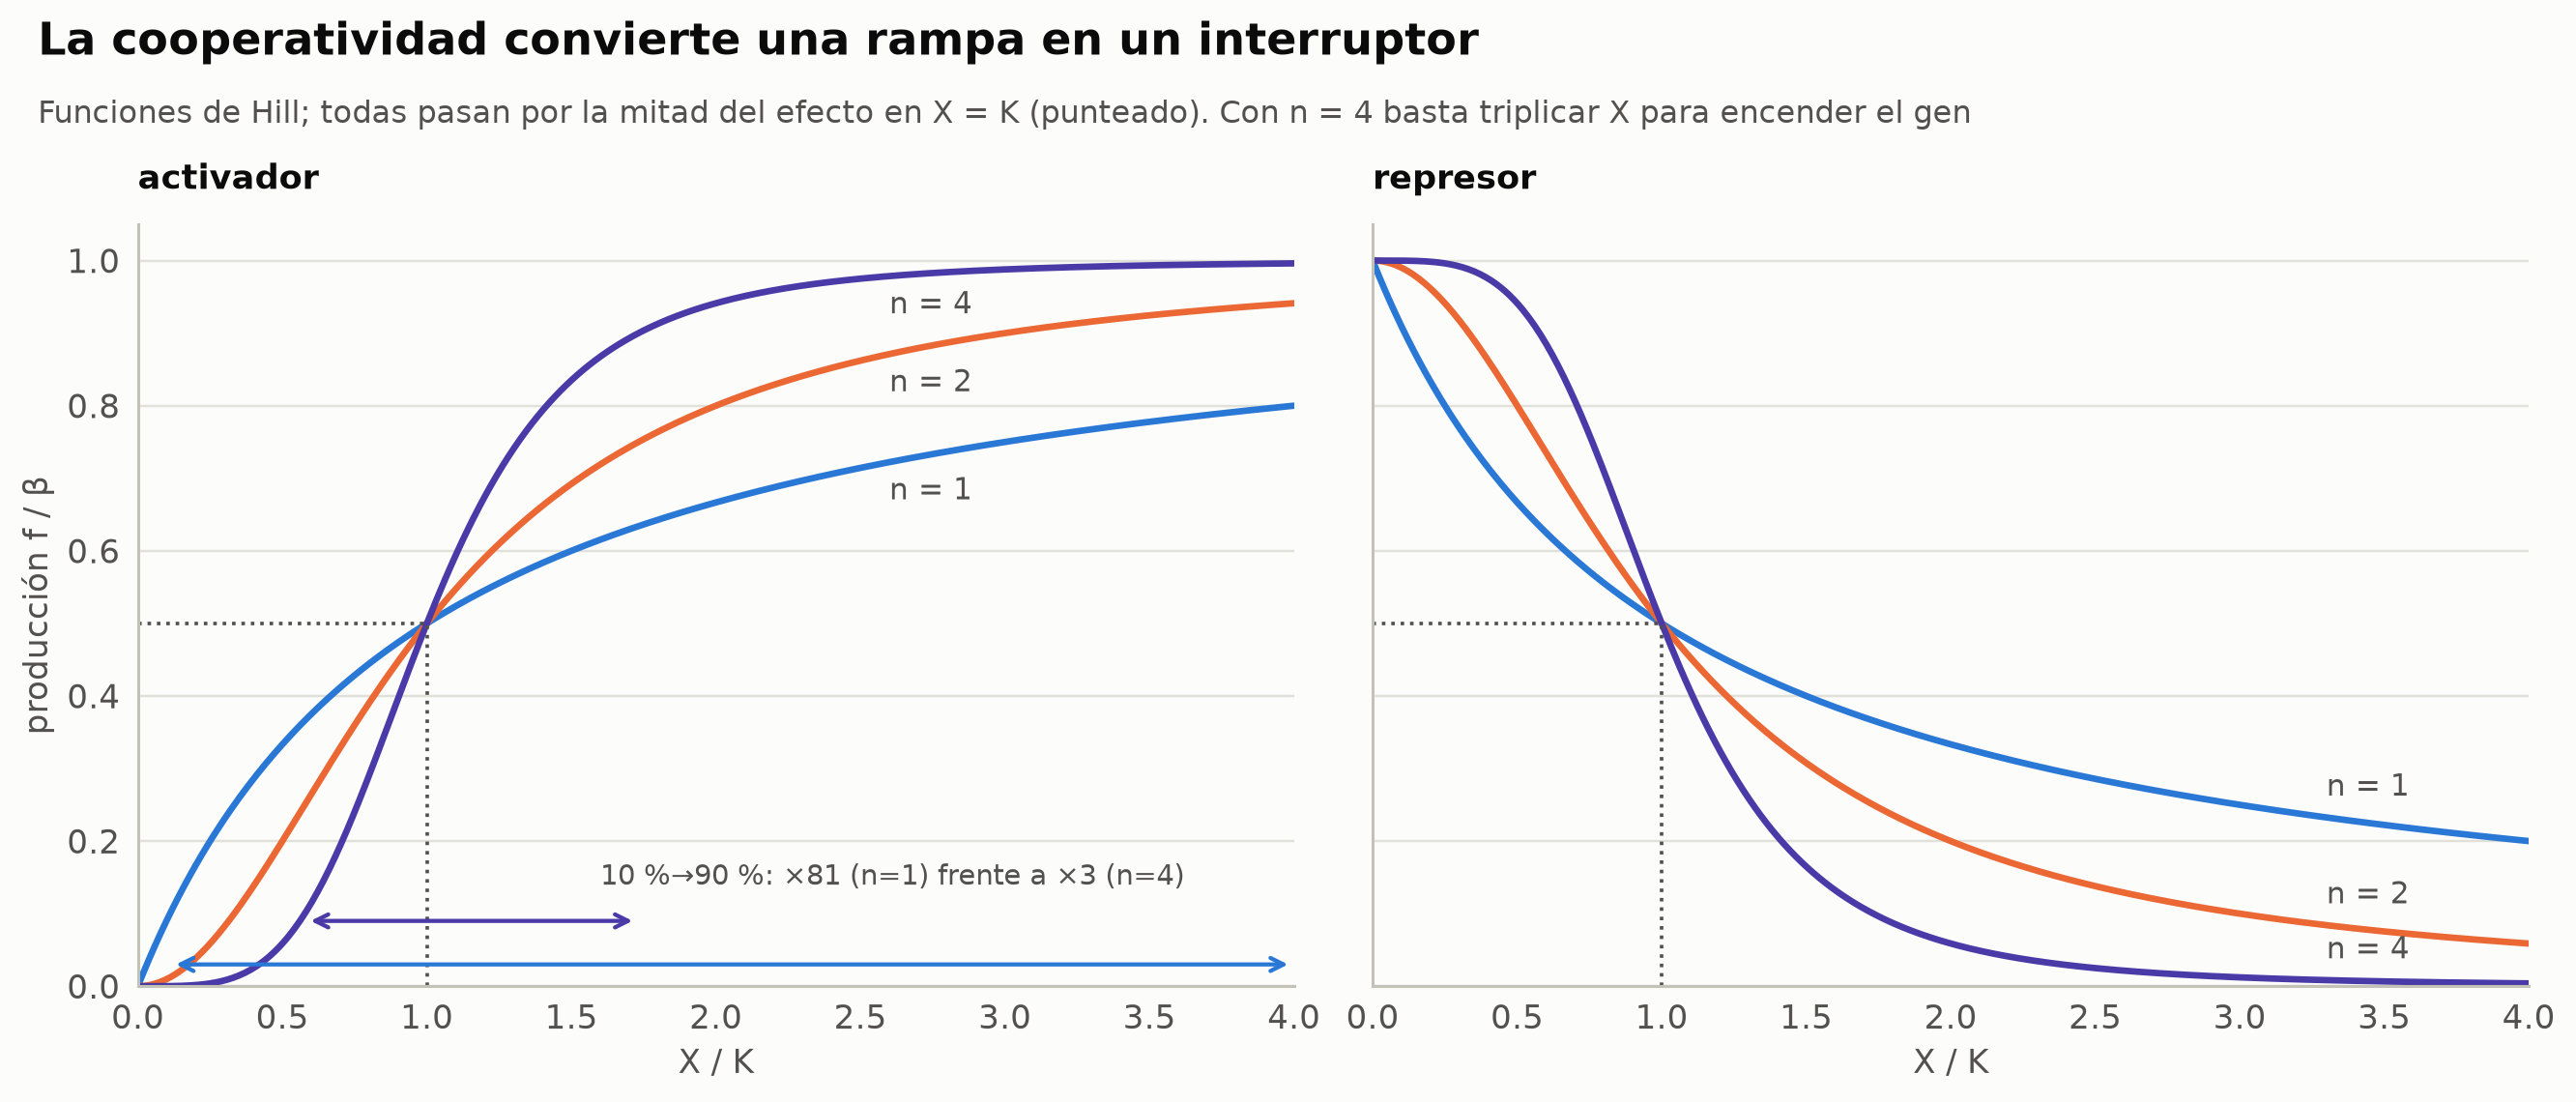

In [3]:
x = np.linspace(0, 4, 400)
cols_n = {1: ec.BLUE, 2: ec.ORANGE, 4: ec.VIOLET}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, fun, name in ((axes[0], hill_act, "activador"), (axes[1], hill_rep, "represor")):
    for n, c in cols_n.items():
        y = fun(x, n=n)
        ax.plot(x, y, color=c, lw=2.2)
        xe = 2.6 if name == "activador" else 3.3
        ax.annotate(f"n = {n}", (xe, fun(xe, n=n)), xytext=(0, -5 if name == "activador" else 5),
                    textcoords="offset points", ha="left", va="top" if name == "activador" else "bottom",
                    fontsize=10, color=ec.INK_2)
    ax.plot([1, 1, 0], [0, 0.5, 0.5], ls=":", color=ec.INK_2, lw=1.2)
    ax.set_xlim(0, 4); ax.set_ylim(0, 1.05); ax.set_xlabel("X / K")
    ax.set_title(name, loc="left", fontsize=11.5)
axes[0].set_ylabel("producción f / β")
# franja 10 %-90 % para n = 1 y n = 4 en el activador
for n, yy in ((1, 0.03), (4, 0.09)):
    axes[0].annotate("", xy=(min(9 ** (1 / n), 4), yy), xytext=(9 ** (-1 / n), yy),
                     arrowprops=dict(arrowstyle="<->", color=cols_n[n], lw=1.4))
axes[0].text(1.6, 0.14, "10 %→90 %: ×81 (n=1) frente a ×3 (n=4)", fontsize=9.5, color=ec.INK_2)
ec.fig_title(fig, "La cooperatividad convierte una rampa en un interruptor",
             "Funciones de Hill; todas pasan por la mitad del efecto en X = K (punteado). Con n = 4 basta triplicar X para "
             "encender el gen")
plt.show()

> 🔎 **Qué observamos.** Las tres curvas cruzan el 50 % en el mismo punto, $X=K$, pero con $n=4$ la transición es mucho
> más estrecha. La pendiente en $X=K$, en escala logarítmica, es $n/4$: cooperatividad y sensibilidad son la misma cosa.

### 🎛️ Explore la cooperatividad con un deslizador

Mueva el deslizador para cambiar $n$ entre 0,5 y 8. Al pasar el ratón por la curva verá la producción relativa, la
**sensibilidad logarítmica** $d\ln f/d\ln X$ (cuánto cambia la producción, en porcentaje, por cada 1 % de cambio en
$X$) y el cociente $81^{1/n}$.

> 🤔 **Antes de mover el deslizador, prediga.** ¿Qué valor mínimo de $n$ hace falta para que el gen pase del 10 % al 90 %
> con solo **duplicar** la concentración del activador?

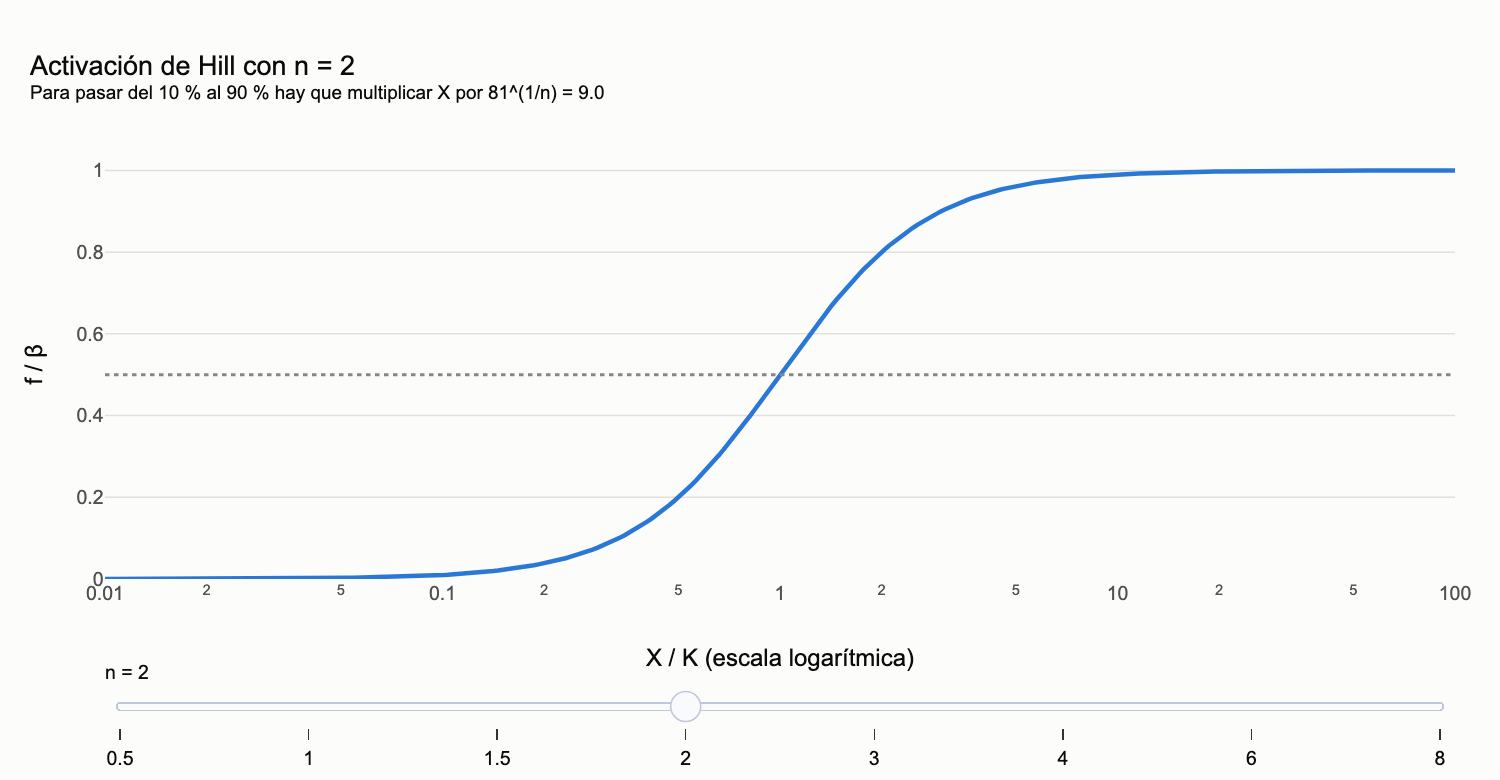

In [4]:
ns_sl = [0.5, 1, 1.5, 2, 3, 4, 6, 8]
xs = np.logspace(-2, 2, 300)
fig = go.Figure()
for n in ns_sl:
    f = xs**n / (1 + xs**n)
    sens = n / (1 + xs**n)          # d ln f / d ln X para el activador
    fig.add_trace(go.Scatter(
        x=xs, y=f, mode="lines", visible=(n == 2), line=dict(width=3, color=ec.BLUE), name=f"n = {n}",
        customdata=np.column_stack([sens, np.full_like(xs, 81 ** (1 / n))]),
        hovertemplate=("X/K = %{x:.3g}<br>producción f/β = %{y:.3f}<br>sensibilidad d ln f / d ln X = "
                       "%{customdata[0]:.2f}<br>X90/X10 = 81^(1/n) = %{customdata[1]:.1f}<extra>n = " + str(n) + "</extra>")))
fig.add_trace(go.Scatter(x=[1e-2, 1e2], y=[0.5, 0.5], mode="lines", line=dict(dash="dot", color=ec.MUTED),
                         hoverinfo="skip", showlegend=False))
steps = []
for k, n in enumerate(ns_sl):
    vis = [i == k for i in range(len(ns_sl))] + [True]
    steps.append(dict(method="update", label=str(n), args=[{"visible": vis},
        {"title.text": f"Activación de Hill con n = {n}<br><sup>Para pasar del 10 % al 90 % hay que multiplicar X por "
                       f"81^(1/n) = {81 ** (1 / n):.1f}</sup>"}]))
fig.update_layout(sliders=[dict(active=ns_sl.index(2), steps=steps, currentvalue=dict(prefix="n = "), pad=dict(t=50))],
                  title="Activación de Hill con n = 2<br><sup>Para pasar del 10 % al 90 % hay que multiplicar X por "
                        "81^(1/n) = 9.0</sup>",
                  xaxis=dict(type="log", title="X / K (escala logarítmica)"), yaxis=dict(title="f / β", range=[0, 1.05]),
                  height=520, margin=dict(t=100, l=70, r=30, b=40), showlegend=False)
fig.show()

> ✅ **Compruebe su comprensión.** Respuesta a la predicción: queremos $81^{1/n}\le2$, es decir $n\ge\ln81/\ln2\approx6{,}3$.
> Ningún factor de transcripción típico llega a tanto por sí solo; las células obtienen respuestas tan abruptas
> combinando cooperatividad con otros mecanismos (secuestro de factores, cascadas de fosforilación).

## 3. El modelo básico: producción y eliminación

Consideremos un gen $Y$ cuyo activador $X$ pasa de golpe, en $t=0$, a un nivel que satura su promotor (por ejemplo,
porque añadimos al medio la señal que activa a $X$). Desde ese momento $Y$ se produce a **tasa constante** $\beta$ y
se elimina en **proporción a su concentración** (cada molécula tiene la misma probabilidad por unidad de tiempo de
desaparecer):

$$
\frac{dY}{dt}=\beta-\alpha Y,\qquad \alpha=\alpha_{\text{deg}}+\alpha_{\text{dil}}.
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $Y(t)$ | concentración de la proteína $Y$ |
| $\beta$ | tasa de producción (el grifo) |
| $\alpha_{\text{deg}}$ | tasa de degradación activa (proteólisis) |
| $\alpha_{\text{dil}}$ | tasa de dilución por crecimiento: $\ln2/\tau$ si la célula se divide cada $\tau$ |
| $\alpha$ | tasa total de eliminación (el desagüe) |

**Respuesta de la regulación simple.** Con $Y(0)=0$, la solución es

$$
Y(t)=Y_{\text{est}}\left(1-e^{-\alpha t}\right),\qquad Y_{\text{est}}=\frac{\beta}{\alpha},\qquad t_{1/2}=\frac{\ln 2}{\alpha}.
$$

*Demostración en dos líneas.* Con $u=Y_{\text{est}}-Y$ la ecuación queda $du/dt=-\alpha u$, cuya solución es
$u(t)=Y_{\text{est}}e^{-\alpha t}$. Imponer $Y(t_{1/2})=Y_{\text{est}}/2$ da $e^{-\alpha t_{1/2}}=1/2$, es decir,
$t_{1/2}=\ln2/\alpha$. Al apagar el gen, $Y(t)=Y_{\text{est}}e^{-\alpha t}$ decae con el mismo $t_{1/2}$.

La consecuencia es contraintuitiva y profunda: el **nivel** final depende de $\beta$, pero la **velocidad** no. Una
célula que quiere **más** proteína puede usar un promotor más fuerte; si la quiere **más rápido**, un promotor fuerte no
sirve. Para las proteínas estables de las bacterias, que solo se eliminan por dilución, $\alpha=\ln2/\tau$ y el tiempo
de respuesta es exactamente **un tiempo de generación**.

> 🤔 **Antes de ejecutar, prediga.** Si triplicamos la fuerza del promotor ($\beta\to3\beta$), ¿qué pasa con el
> tiempo que tarda $Y$ en llegar a la mitad de **su** nivel final?

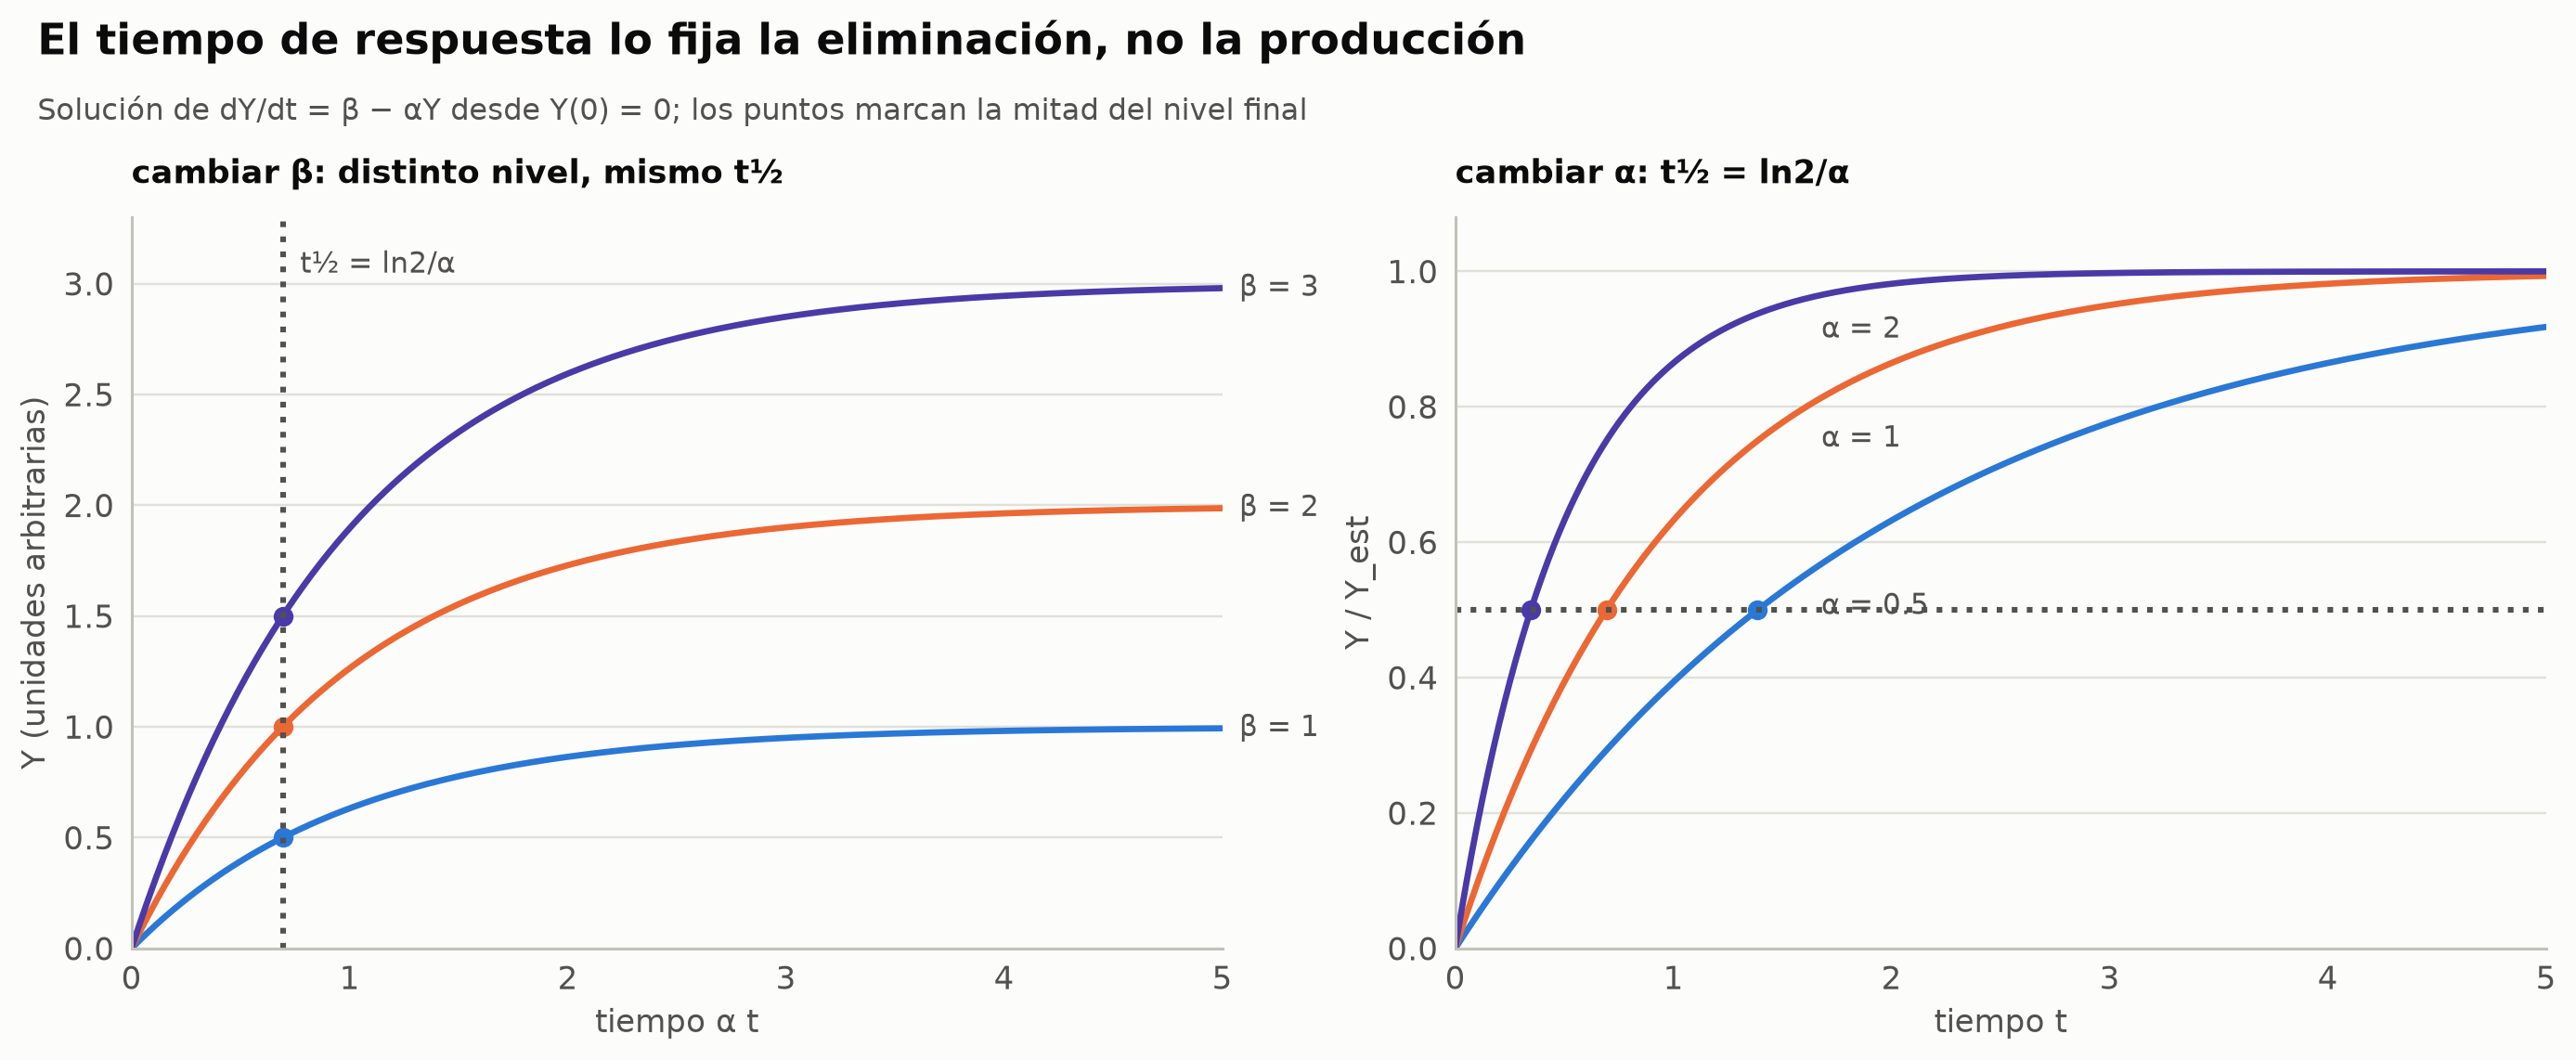

In [5]:
t = np.linspace(0, 5, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
for beta_, c in zip((1, 2, 3), (ec.BLUE, ec.ORANGE, ec.VIOLET)):
    y = beta_ * (1 - np.exp(-t))
    ax.plot(t, y, color=c, lw=2.2)
    ax.plot(np.log(2), beta_ / 2, "o", color=c, ms=6)
    ec.label_end(ax, t[-1], y[-1], f"β = {beta_}")
ax.axvline(np.log(2), ls=":", color=ec.INK_2)
ax.text(np.log(2) + 0.08, 3.05, "t½ = ln2/α", color=ec.INK_2, fontsize=10)
ax.set_xlabel("tiempo α t"); ax.set_ylabel("Y (unidades arbitrarias)"); ax.set_xlim(0, 5); ax.set_ylim(0, 3.3)
ax.set_title("cambiar β: distinto nivel, mismo t½", loc="left", fontsize=11.5)
ax = axes[1]
for a_, c in zip((0.5, 1, 2), (ec.BLUE, ec.ORANGE, ec.VIOLET)):
    y = 1 - np.exp(-a_ * t)
    ax.plot(t, y, color=c, lw=2.2)
    ax.plot(np.log(2) / a_, 0.5, "o", color=c, ms=6)
    ax.annotate(f"α = {a_}", (1.6, 1 - np.exp(-a_ * 1.6)), xytext=(6, -6), textcoords="offset points",
                ha="left", va="top", fontsize=10, color=ec.INK_2)
ax.axhline(0.5, ls=":", color=ec.INK_2)
ax.set_xlabel("tiempo t"); ax.set_ylabel("Y / Y_est"); ax.set_xlim(0, 5); ax.set_ylim(0, 1.08)
ax.set_title("cambiar α: t½ = ln2/α", loc="left", fontsize=11.5)
ec.fig_title(fig, "El tiempo de respuesta lo fija la eliminación, no la producción",
             "Solución de dY/dt = β − αY desde Y(0) = 0; los puntos marcan la mitad del nivel final")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, triplicar $\beta$ triplica el nivel final, pero los tres puntos de «mitad del
> camino» caen en la misma vertical $t=\ln2/\alpha$. A la derecha, duplicar $\alpha$ divide por dos el tiempo de respuesta.

### Ejemplo resuelto del libro: «Cuánto tarda en responder un gen»

En *Escherichia coli* creciendo con $\tau=30$ min (medio rico a 37 °C), una proteína **estable** tiene
$\alpha=\ln2/30=0{,}0231\ \text{min}^{-1}$ y $t_{1/2}=30$ min. Si la proteína además se degrada activamente con una vida
media de 5 min, las dos tasas se **suman**: $\alpha=0{,}0231+\ln2/5=0{,}162\ \text{min}^{-1}$ y $t_{1/2}=4{,}3$ min, siete
veces más rápido. Con una vida media de 60 min, $t_{1/2}=20$ min. La degradación acelera la respuesta, pero a un costo:
para mantener el mismo nivel final ($\beta/\alpha$) hay que producir la proteína, y gastar energía, a una tasa
proporcionalmente mayor.

In [6]:
tau = 30.0                                   # tiempo de generación (min)
a_dil = math.log(2) / tau
rows = [("estable (solo dilución)", None, a_dil)]
for half in (60, 5):
    rows.append((f"vida media activa {half} min", half, a_dil + math.log(2) / half))
tab = pd.DataFrame([dict(proteína=name, **{"α (1/min)": round(a, 4), "t½ (min)": round(math.log(2) / a, 1),
                                           "síntesis relativa para igual nivel": round(a / a_dil, 1)})
                    for name, h, a in rows])
tab

,proteína,α (1/min),t½ (min),síntesis relativa para igual nivel
0,estable (solo dilución),0.0231,30.0,1.0
1,vida media activa 60 min,0.0347,20.0,1.5
2,vida media activa 5 min,0.1617,4.3,7.0


> ✅ **Compruebe su comprensión.** La última columna es el precio: la proteína que responde en 4,3 min obliga a
> sintetizar **7 veces** más moléculas por minuto para mantener el mismo nivel. ¿Hay alguna forma de responder rápido
> sin pagar ese precio? La siguiente sección responde que sí.

## 4. Autorregulación negativa: acelerar sin desperdiciar

Existe una forma más económica de acelerar la respuesta. Supongamos que $X$ **reprime su propio promotor**:

$$
\frac{dX}{dt}=\frac{\beta}{1+(X/K)^n}-\alpha X .
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $X$ | concentración de la proteína autorreprimida |
| $\beta$ | producción máxima (promotor libre) |
| $K$ | concentración de $X$ que reduce la producción a la mitad |
| $n$ | coeficiente de Hill de la autorrepresión |
| $\alpha$ | tasa de eliminación (degradación + dilución) |
| $X_{\text{est}}$ | nivel estacionario |

**En palabras.** Al principio, con $X\ll K$, el promotor funciona a pleno rendimiento y $X$ crece a la tasa máxima
$\beta$: el grifo está abierto del todo. Cuando $X$ se acerca a $K$ la represión cierra el grifo y el sistema se
estabiliza. Si elegimos un promotor **muy fuerte** y una represión que lo compense, obtenemos el **mismo nivel final**
que con regulación simple pero con un **arranque mucho más rápido**: es el termostato de la bañera. Y, a diferencia
de acelerar con degradación, no tiramos proteína: la célula deja de fabricarla cuando ya no la necesita.

**Ejemplo del libro (figura «La autorregulación negativa acelera la respuesta»).** Tomamos $\alpha=1$ y un nivel
estacionario $X_{\text{est}}=1$, con $K=0{,}3X_{\text{est}}$ y $n=2$. Para que el estado estacionario sea el mismo que el
de la regulación simple, en $X=X_{\text{est}}$ producción y eliminación deben igualarse:

$$
\frac{\beta'}{1+(1/0{,}3)^2}=\alpha\cdot1\quad\Longrightarrow\quad \beta'=1+11{,}1=12{,}1\,\beta .
$$

Una estimación a mano del tiempo de respuesta: si al principio $X$ crece casi linealmente a tasa $\beta'$, llega a la
mitad en $0{,}5/12{,}1\approx0{,}041$; la represión lo frena, así que el valor verdadero será algo mayor. Veámoslo.

In [7]:
alpha, beta, K, nH = 1.0, 1.0, 0.3, 2
x_st = beta / alpha
beta_nar = alpha * x_st * (1 + (x_st / K) ** nH)       # 12,1 veces beta

def nar_rhs(_t, x, b=beta_nar, K=K, n=nH):
    return [b / (1 + (x[0] / K) ** n) - alpha * x[0]]

t = np.linspace(0, 5, 251)
x_simple = x_st * (1 - np.exp(-alpha * t))
x_nar = solve_ivp(nar_rhs, (0, 5), [0], t_eval=t, rtol=1e-9, atol=1e-12, method="LSODA").y[0]
fine = solve_ivp(nar_rhs, (0, 1), [0], dense_output=True, rtol=1e-10, atol=1e-12, method="LSODA")
t12_simple = math.log(2) / alpha
t12_nar = brentq(lambda s: fine.sol(s)[0] - 0.5 * x_st, 1e-6, 1)
print(f"beta'/beta = {beta_nar / beta:.1f}")
print(f"t1/2 simple = {t12_simple:.3f}   t1/2 NAR = {t12_nar:.4f}   aceleración = {t12_simple / t12_nar:.1f}x")
print(f"estimación lineal a mano: 0.5/beta' = {0.5 * x_st / beta_nar:.4f}")

# Variantes del libro: otras K y n con el mismo nivel final
rows = []
for K2, n2 in ((0.25, 1), (0.1, 1), (0.3, 2), (0.2, 2)):
    b2 = alpha * x_st * (1 + (x_st / K2) ** n2)
    f2 = solve_ivp(lambda _t, x: [b2 / (1 + (x[0] / K2) ** n2) - alpha * x[0]], (0, 1), [0],
                   dense_output=True, rtol=1e-10, atol=1e-12, method="LSODA")
    t2 = brentq(lambda s_: f2.sol(s_)[0] - 0.5 * x_st, 1e-6, 1)
    rows.append({"K/X_est": K2, "n": n2, "β'/β": round(b2, 1), "t½ (1/α)": round(t2, 4),
                 "aceleración": f"{t12_simple / t2:.1f}×"})
pd.DataFrame(rows)

beta'/beta = 12.1
t1/2 simple = 0.693   t1/2 NAR = 0.0855   aceleración = 8.1x
estimación lineal a mano: 0.5/beta' = 0.0413


,K/X_est,n,β'/β,t½ (1/α),aceleración
0,0.25,1,5.0,0.2355,2.9×
1,0.10,1,11.0,0.1847,3.8×
2,0.30,2,12.1,0.0855,8.1×
3,0.20,2,26.0,0.0634,10.9×


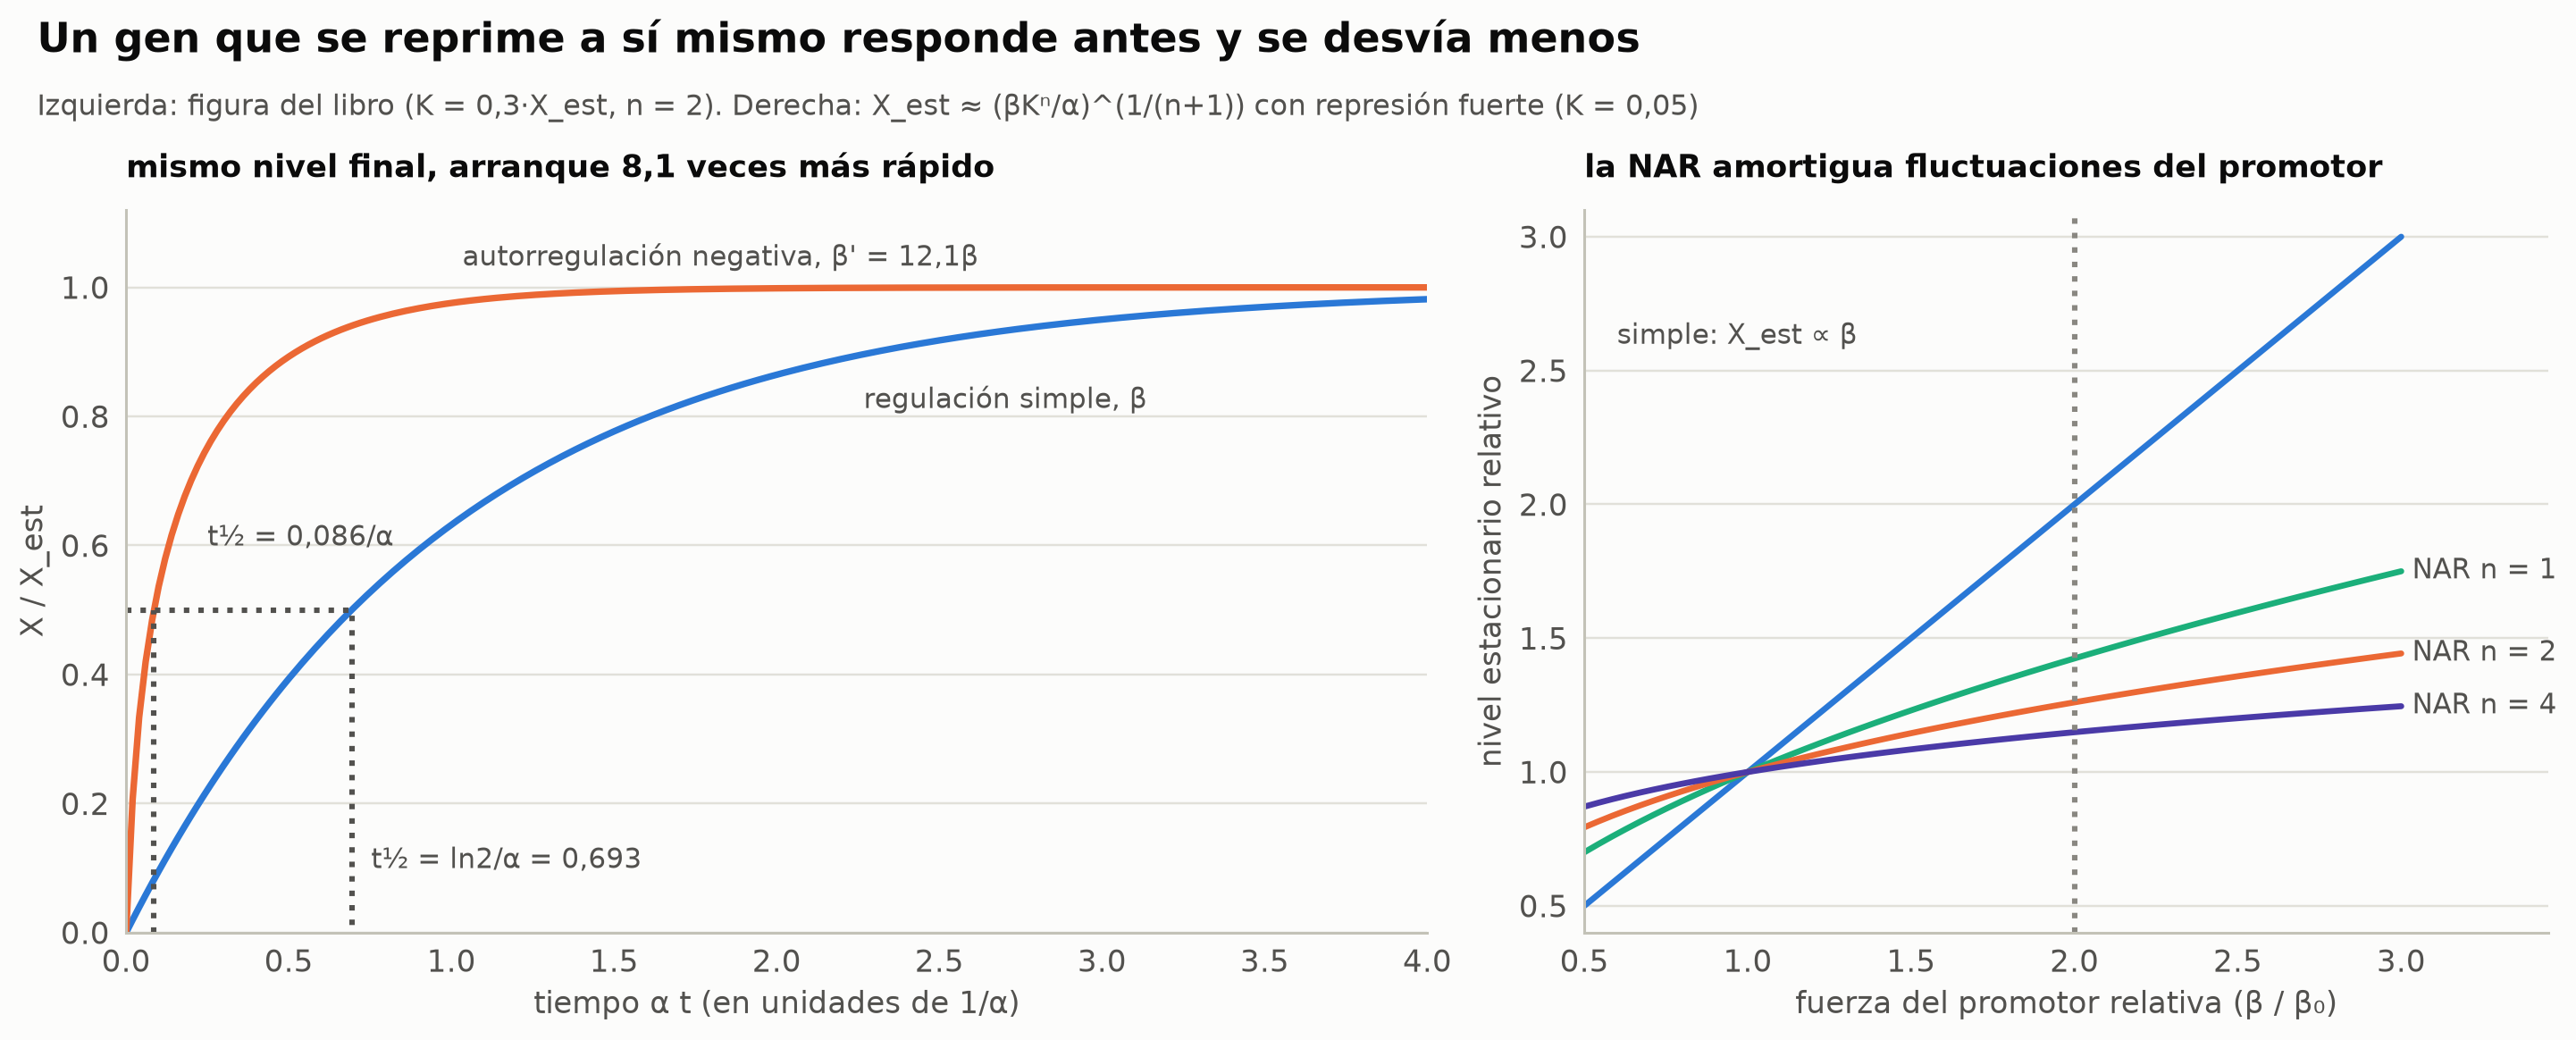

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax = axes[0]
ax.plot(t, x_simple, color=ec.BLUE, lw=2.4)
ax.plot(t, x_nar, color=ec.ORANGE, lw=2.4)
ax.plot([0, t12_simple, t12_simple], [0.5, 0.5, 0], ls=":", color=ec.INK_2)
ax.plot([t12_nar, t12_nar], [0, 0.5], ls=":", color=ec.INK_2)
ax.text(t12_simple + 0.06, 0.1, "t½ = ln2/α = 0,693", fontsize=10, color=ec.INK_2)
ax.text(0.25, 0.6, f"t½ = {t12_nar:.3f}/α".replace(".", ","), fontsize=10, color=ec.INK_2)
ax.annotate("regulación simple, β", (2.2, 1 - np.exp(-2.2)), xytext=(8, -18), textcoords="offset points",
            fontsize=10, color=ec.INK_2)
ax.annotate("autorregulación negativa, β' = 12,1β", (1.0, 1.0), xytext=(4, 8), textcoords="offset points",
            fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 4); ax.set_ylim(0, 1.12); ax.set_xlabel("tiempo α t (en unidades de 1/α)"); ax.set_ylabel("X / X_est")
ax.set_title("mismo nivel final, arranque 8,1 veces más rápido", loc="left", fontsize=11.5)

# Robustez: cuánto cambia X_est si una fluctuación multiplica la fuerza del promotor
ax = axes[1]
folds = np.linspace(0.5, 3, 60)
ax.plot(folds, folds, color=ec.BLUE, lw=2.2)
ax.text(0.6, 2.6, "simple: X_est ∝ β", fontsize=10, color=ec.INK_2)
for n2, c in ((1, ec.AQUA), (2, ec.ORANGE), (4, ec.VIOLET)):
    Kr = 0.05       # represión fuerte: X_est >> K
    b0 = 1 * (1 + (1 / Kr) ** n2)
    xs_ = [brentq(lambda X: f * b0 / (1 + (X / Kr) ** n2) - X, 1e-9, 1e3) for f in folds]
    ax.plot(folds, xs_, color=c, lw=2.2)
    ax.annotate(f"NAR n = {n2}", (3, xs_[-1]), xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=10, color=ec.INK_2)
ax.axvline(2, ls=":", color=ec.MUTED)
ax.set_xlim(0.5, 3.45); ax.set_ylim(0.4, 3.1)
ax.set_xlabel("fuerza del promotor relativa (β / β₀)"); ax.set_ylabel("nivel estacionario relativo")
ax.set_title("la NAR amortigua fluctuaciones del promotor", loc="left", fontsize=11.5)
ec.fig_title(fig, "Un gen que se reprime a sí mismo responde antes y se desvía menos",
             "Izquierda: figura del libro (K = 0,3·X_est, n = 2). Derecha: X_est ≈ (βKⁿ/α)^(1/(n+1)) con represión fuerte (K = 0,05)")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la curva naranja llega a la mitad en $0{,}0855/\alpha$ en lugar de
> $0{,}693/\alpha$: **8,1 veces** más rápido, sin cambiar el estado final ni la tasa de eliminación. Nuestra estimación a
> mano (0,041) era demasiado optimista porque la represión empieza a frenar antes de la mitad. A la derecha, duplicar el
> promotor (línea punteada) duplica el nivel con regulación simple, pero con autorregulación $n=2$ solo lo sube un 26 %.

**¿De dónde sale ese 26 %?** En el límite de represión fuerte ($X_{\text{est}}\gg K$), el estado estacionario satisface
$\beta(K/X)^n\approx\alpha X$, es decir,

$$
X_{\text{est}}\approx\left(\frac{\beta K^n}{\alpha}\right)^{1/(n+1)} .
$$

El nivel depende de $\beta$ solo a través de una raíz de orden $n+1$: si una fluctuación duplica la fuerza del promotor,
con $n=2$ el nivel sube $2^{1/3}-1=26\,\%$, no un 100 %. La autorregulación negativa **acelera la respuesta y amortigua
el ruido de producción**. Rosenfeld, Elowitz y Alon (2002) lo midieron con circuitos sintéticos en *E. coli*: la unidad
sin autorregulación tardaba un ciclo celular en alcanzar la mitad de su nivel final; la autorregulada, alrededor de una
quinta parte de ciclo. También señalaron que este motivo aparece en más del 40 % de los factores de transcripción
conocidos de *E. coli*. En la siguiente sección lo comprobamos con la base de datos actual.

> ✅ **Compruebe su comprensión.** Con $n=4$, ¿cuánto sube el nivel si el promotor se duplica? *(Respuesta:
> $2^{1/5}-1\approx15\,\%$; compárelo con la curva violeta en $\beta/\beta_0=2$.)*

## 5. Motivos de red en la red real de *E. coli*

### ¿Hay patrones que se repiten?

Si miramos una red de regulación grande, ¿aparecen ciertos «circuitos» con más frecuencia de la que esperaríamos por
azar? Milo et al. (2002) definieron los **motivos de red** como patrones de interconexión que aparecen
significativamente más a menudo que en redes aleatorizadas. Para cada subgrafo de tres nodos se cuenta su número de
apariciones $N_{\text{real}}$ y se compara con el de muchas redes **aleatorizadas que conservan el grado de entrada y de
salida de cada nodo** (así, un gen que regula a 400 genes sigue regulando a 400 genes; solo cambia a cuáles):

$$
Z=\frac{N_{\text{real}}-\langle N_{\text{azar}}\rangle}{\sigma_{\text{azar}}} .
$$

| Símbolo | Significado |
|---|---|
| $N_{\text{real}}$ | apariciones del subgrafo en la red real |
| $\langle N_{\text{azar}}\rangle,\ \sigma_{\text{azar}}$ | media y desviación estándar en las redes aleatorizadas |
| $Z$ | puntuación de significación del motivo |

Shen-Orr et al. (2002) aplicaron la idea a la red de interacciones transcripcionales de *E. coli* y encontraron que
buena parte de ella está hecha de tres motivos: el ***feed-forward loop*** (FFL: $X\to Y\to Z$ y además $X\to Z$), el
**módulo de entrada única** (SIM: un regulador que controla a un grupo de genes) y los **regulones densos
superpuestos**. Vamos a repetir el cálculo principal con la versión 11.0 de **RegulonDB**, la base de datos curada de
la regulación transcripcional de *E. coli* K-12 (Tierrafría et al., 2022).

> 🤔 **Antes de ejecutar, prediga.** Un FFL ($X\to Y$, $Y\to Z$, $X\to Z$) y un ciclo de retroalimentación
> ($X\to Y\to Z\to X$) tienen ambos tres nodos y tres aristas. ¿Cuál cree que la evolución ha favorecido en la red de
> *E. coli*, y cuál ha evitado?

> ⚖️ **Licencia de RegulonDB.** RegulonDB es de uso libre **académico y no comercial**, pero sus condiciones prohíben
> integrar sus datos, total o parcialmente, en otros sistemas sin permiso escrito del CCG-UNAM. Por eso el curso **no
> redistribuye** el archivo de interacciones: por defecto cargamos un **resumen derivado** (recuentos, los resultados
> de las aleatorizaciones y los tipos de FFL) que generamos con este mismo código a partir de RegulonDB 11.0. Si quiere
> rehacer todo el cálculo, ponga `RECOMPUTE_REGULONDB = True`: el notebook descargará el archivo de la fuente oficial
> (https://regulondb.ccg.unam.mx) a su disco, sin subirlo a ningún sitio. Si publica resultados, cite a Tierrafría et
> al. (2022).

In [9]:
# RegulonDB 11.0: interacciones factor de transcripción -> gen. Por la licencia, el curso sólo distribuye un resumen
# derivado (data/162_regulondb_resumen.json); con RECOMPUTE_REGULONDB = True se descarga el archivo y se recalcula todo.
RECOMPUTE_REGULONDB = False
REGULONDB_URLS = [
    "https://regulondb.ccg.unam.mx/menu/download/datasets/files/network_tf_gene.txt",   # fuente oficial
    # espejo en GitHub de RegulonDB 11.0 (el que se usó para generar el resumen del curso)
    "https://raw.githubusercontent.com/Natpod/Synthetic-Biology-Network-Analysis-on-Regulon-DB-E-coli-Data/HEAD/network_tf_gene.txt",
]
RDB_LOCAL = "regulondb_network_tf_gene.txt"      # copia local: NO la suba a ningún repositorio

def fetch_regulondb():
    """Descarga el archivo TF -> gen y comprueba que es el archivo de texto esperado (no una página HTML)."""
    if os.path.exists(RDB_LOCAL):
        return RDB_LOCAL
    for url in REGULONDB_URLS:
        try:
            with urllib.request.urlopen(url, timeout=60) as resp:
                raw = resp.read()
        except Exception as err:                  # incluye errores de certificado SSL del servidor
            print(f"  no se pudo descargar {url}: {err}")
            continue
        text = raw.decode("latin1")
        if text.startswith("#") and "Transcription Factor (TF) ID" in text:
            with open(RDB_LOCAL, "w", encoding="latin1") as fh:
                fh.write(text)
            print("descargado de", url)
            return RDB_LOCAL
        print(f"  {url} no devolvió el archivo esperado (¿página HTML?)")
    raise RuntimeError("No se pudo descargar RegulonDB; descárguelo a mano y guárdelo como " + RDB_LOCAL)

if RECOMPUTE_REGULONDB:
    fn = fetch_regulondb()
    with open(fn, encoding="latin1") as fh:
        header_lines = [ln for ln in fh.readlines()[:40] if ln.startswith("#")]
    rdb = pd.read_csv(fn, sep="\t", comment="#", header=None, encoding="latin1").iloc[:, :7]
    rdb.columns = ["tf_id", "tf", "gene_id", "gene", "effect", "evidence", "evidence_type"]
    i_cite = next(i for i, l in enumerate(header_lines) if "Tierra" in l)     # la cita ocupa dos líneas
    R = {"version": [l.strip("# \n") for l in header_lines if "Release" in l][0],
         "cita": " ".join(l.strip("# \n") for l in header_lines[i_cite:i_cite + 2]),
         "forma": list(rdb.shape), "n_tf": int(rdb.tf.nunique()), "n_genes": int(rdb.gene.nunique()),
         "efectos": {k: int(v) for k, v in rdb.effect.value_counts().items()},
         "evidencia": {k: int(v) for k, v in rdb.evidence_type.value_counts().items()}}
    print("⚠️ Recalculando desde el archivo descargado: si RegulonDB ha publicado una versión más nueva que la 11.0,"
          " las cifras cambiarán respecto al texto.")
else:
    with open(course_file("162_regulondb_resumen.json"), encoding="utf-8") as fh:
        R = json.load(fh)
print(R["cita"]); print(R["version"])
print(tuple(R["forma"]), "interacciones;", R["n_tf"], "factores de transcripción;", R["n_genes"], "genes regulados")
print({{"+": "activación", "-": "represión", "?": "desconocido"}.get(k, k): v for k, v in R["efectos"].items()})
print("tipo de evidencia:", R["evidencia"])
print("columnas: TF ID, TF, gen ID, gen, efecto (+, -, ?), evidencia, tipo de evidencia (STRONG/WEAK)")

Tierrafría, V. H. et al. (2022). RegulonDB 11.0: Comprehensive high-throughput datasets on transcriptional regulation in Escherichia coli K-12, Microb Genom. 2022 May;8(5). doi: 10.1099/mgen.0.000833. PMID: 35584008. https://doi.org/10.1099/mgen.0.000833
Release: 11.0 Date:  08/22/2022
(4775, 7) interacciones; 216 factores de transcripción; 1870 genes regulados
{'activación': 2511, 'represión': 2244, 'desconocido': 20}
tipo de evidencia: {'STRONG': 4612, 'WEAK': 163}
columnas: TF ID, TF, gen ID, gen, efecto (+, -, ?), evidencia, tipo de evidencia (STRONG/WEAK)


El archivo enumera pares **(factor, gen regulado)**. Para ver circuitos necesitamos saber qué **gen codifica** cada
factor: la proteína AraC es el producto del gen *araC*, CRP de *crp*, H-NS de *hns*. La convención de nombres casi
siempre basta (primera letra en minúscula, o todo en minúscula); para los factores que son complejos de dos proteínas
(IHF, HU, FlhDC, GadE-RcsB…) tomamos la primera subunidad. Los factores que no conseguimos asociar a un gen quedan
como nodos «solo reguladores» (sin aristas entrantes), lo que es conservador para el recuento de motivos. Usamos
todas las interacciones, también las 163 que RegulonDB clasifica con evidencia débil (WEAK); filtrarlas es una
variante razonable del análisis.

In [10]:
SPECIAL = {"IHF": "ihfA", "HU": "hupA", "FlhDC": "flhD", "H-NS": "hns", "RcsAB": "rcsA"}

def tf_to_gene(name, genes):
    # Gen que codifica un factor de transcripción (o su primera subunidad)
    if name in SPECIAL and SPECIAL[name] in genes:
        return SPECIAL[name]
    first = name.split("-")[0]
    for cand in (name[0].lower() + name[1:], name.lower(), first[0].lower() + first[1:], first.lower(),
                 name.replace("-", "").lower()):
        if cand in genes:
            return cand
    return None

# Si una pareja aparece con los dos signos (regulación dual, según la condición), la marcamos como "±"
def merge_effect(s_):
    e = set(s_) - {"?"}
    return "±" if e == {"+", "-"} else (e.pop() if e else "?")

NAMED_TF = ("LexA", "Fur", "FNR", "AraC", "CRP")
if RECOMPUTE_REGULONDB:
    genes = set(rdb.gene)
    tf_gene = {tf: tf_to_gene(tf, genes) for tf in rdb.tf.unique()}
    rdb["src"] = [tf_gene[t] or t for t in rdb.tf]
    edges = (rdb.groupby(["src", "gene"]).agg(effect=("effect", merge_effect), tf=("tf", "first")).reset_index())
    auto = edges[edges.src == edges.gene]          # el factor regula el gen que lo codifica
    R["mapeo"] = {"asociados": sum(g is not None for g in tf_gene.values()),
                  "sin_asociar": sum(g is None for g in tf_gene.values())}
    R["signos_pares"] = {k: int(v) for k, v in edges.effect.value_counts().items()}
    R["auto_n"] = len(auto)
    R["auto_signos"] = {k: int(v) for k, v in auto.effect.value_counts().items()}
    R["auto_nombrados"] = {tf: auto.set_index("tf").effect.get(tf, "no") for tf in NAMED_TF}

n_tf_map = R["mapeo"]["asociados"]
print(f"{n_tf_map} de {R['n_tf']} factores asociados a su gen; "
      f"sin asociar (quedan como nodos solo reguladores): {R['mapeo']['sin_asociar']}")
print("signos por pareja regulador-gen:", R["signos_pares"])
print(f"\nAutorregulación: {R['auto_n']} factores = {R['auto_n'] / R['n_tf']:.0%} de los {R['n_tf']} (cota inferior)"
      f" y {R['auto_n'] / n_tf_map:.0%} de los {n_tf_map} asociados a su gen")
print("  por signo:", {{"+": "positiva", "-": "negativa", "±": "dual", "?": "desconocida"}[k]: v
                       for k, v in R["auto_signos"].items()})
for tf in NAMED_TF:
    print(f"  {tf:5s} regula su propio gen con signo {R['auto_nombrados'][tf]}")

166 de 216 factores asociados a su gen; sin asociar (quedan como nodos solo reguladores): 50
signos por pareja regulador-gen: {'+': 2293, '-': 2020, '±': 216, '?': 5}

Autorregulación: 128 factores = 59% de los 216 (cota inferior) y 77% de los 166 asociados a su gen
  por signo: {'negativa': 87, 'positiva': 30, 'dual': 11}
  LexA  regula su propio gen con signo -
  Fur   regula su propio gen con signo -
  FNR   regula su propio gen con signo -
  AraC  regula su propio gen con signo ±
  CRP   regula su propio gen con signo ±


> 🔎 **Qué observamos.** Al menos 128 de los 216 factores de transcripción de RegulonDB (59 %) regulan su propio gen.
> Es una **cota inferior**: sólo podemos detectar la autorregulación en los 166 factores que asociamos a su gen, y
> entre ellos la fracción es 128/166 = 77 %. La mayoría de esas autorregulaciones son **negativas** (87, frente a 30
> positivas y 11 duales): la cifra de «más del 40 %» de Rosenfeld et al. (2002) se ha
> quedado corta a medida que se ha curado más literatura. Entre los autorrepresores están LexA (el represor de la
> respuesta SOS al daño del ADN), Fur (hierro) y FNR (anaerobiosis); AraC y CRP aparecen como **duales**: según las
> condiciones activan o reprimen su propio promotor.

### Contar FFL y ciclos, y compararlos con el azar

Con la matriz de adyacencia $A$ (sin autoaristas), el número de FFL es $\sum_{ij}(A^2)_{ij}A_{ij}$: $(A^2)_{ij}$ cuenta
los caminos $i\to k\to j$ y el factor $A_{ij}$ exige que además exista el atajo $i\to j$. Los ciclos de tres nodos son
$\operatorname{tr}(A^3)/3$. Para aleatorizar usamos **intercambios de aristas**: se eligen dos aristas $a\to b$ y
$c\to d$ y se reconectan como $a\to d$ y $c\to b$, lo que conserva exactamente los grados de entrada y salida de los
cuatro nodos (se rechazan los intercambios que crearían autoaristas o aristas repetidas).

In [11]:
import scipy.sparse as sps

def motif_counts(s, t):
    A = sps.csr_matrix((np.ones(len(s)), (s, t)), shape=(N_nodes, N_nodes))
    A2 = A @ A
    return int(A2.multiply(A).sum()), int((A2 @ A).diagonal().sum() // 3)

def edge_swap(s, t, n_swaps, rng):
    """Aleatoriza conservando grados de entrada y salida (intercambios a->b, c->d  =>  a->d, c->b)."""
    s, t = s.copy(), t.copy()
    present = set(zip(s.tolist(), t.tolist()))
    done = tries = 0
    E = len(s)
    while done < n_swaps and tries < 20 * n_swaps:
        tries += 1
        i, j = rng.integers(0, E, 2)
        a, b, c, d = s[i], t[i], s[j], t[j]
        if a == d or c == b or (a, d) in present or (c, b) in present:
            continue
        present -= {(a, b), (c, d)}; present |= {(a, d), (c, b)}
        t[i], t[j] = d, b
        done += 1
    return s, t

if RECOMPUTE_REGULONDB:
    e_net = edges[edges.src != edges.gene]
    nodes = sorted(set(e_net.src) | set(e_net.gene))
    idx = {g: i for i, g in enumerate(nodes)}
    src = np.array([idx[g] for g in e_net.src]); dst = np.array([idx[g] for g in e_net.gene])
    N_nodes = len(nodes)
    ffl_real, cyc_real = motif_counts(src, dst)
    rng_m = np.random.default_rng(16)
    t0 = time.time()
    rand = np.array([motif_counts(*edge_swap(src, dst, 5 * len(src), rng_m)) for _ in range(30)])
    print(f"(30 redes aleatorizadas en {time.time() - t0:.1f} s)")
    R.update({"n_nodos": N_nodes, "n_aristas": len(src), "ffl_real": ffl_real, "cyc_real": cyc_real,
              "azar_ffl_ciclos": rand.tolist()})
else:
    ffl_real, cyc_real = R["ffl_real"], R["cyc_real"]
    rand = np.array(R["azar_ffl_ciclos"])       # 30 redes aleatorizadas: [FFL, ciclos] (semilla 16)
n_edges = R["n_aristas"]
z_ffl = (ffl_real - rand[:, 0].mean()) / rand[:, 0].std()
print(f"Red: {R['n_nodos']} genes, {n_edges} aristas reguladoras (sin autoaristas)")
print(f"FFL:    real = {ffl_real:5d}   azar = {rand[:, 0].mean():7.1f} ± {rand[:, 0].std():5.1f}   Z = {z_ffl:.1f}")
print(f"ciclos: real = {cyc_real:5d}   azar = {rand[:, 1].mean():7.1f} ± {rand[:, 1].std():5.1f}")
print(f"FFL real / media al azar = {ffl_real / rand[:, 0].mean():.2f}")

Red: 1919 genes, 4406 aristas reguladoras (sin autoaristas)


FFL:    real =  2176   azar =   822.6 ± 103.2   Z = 13.1
ciclos: real =    10   azar =     3.3 ±   2.1
FFL real / media al azar = 2.65


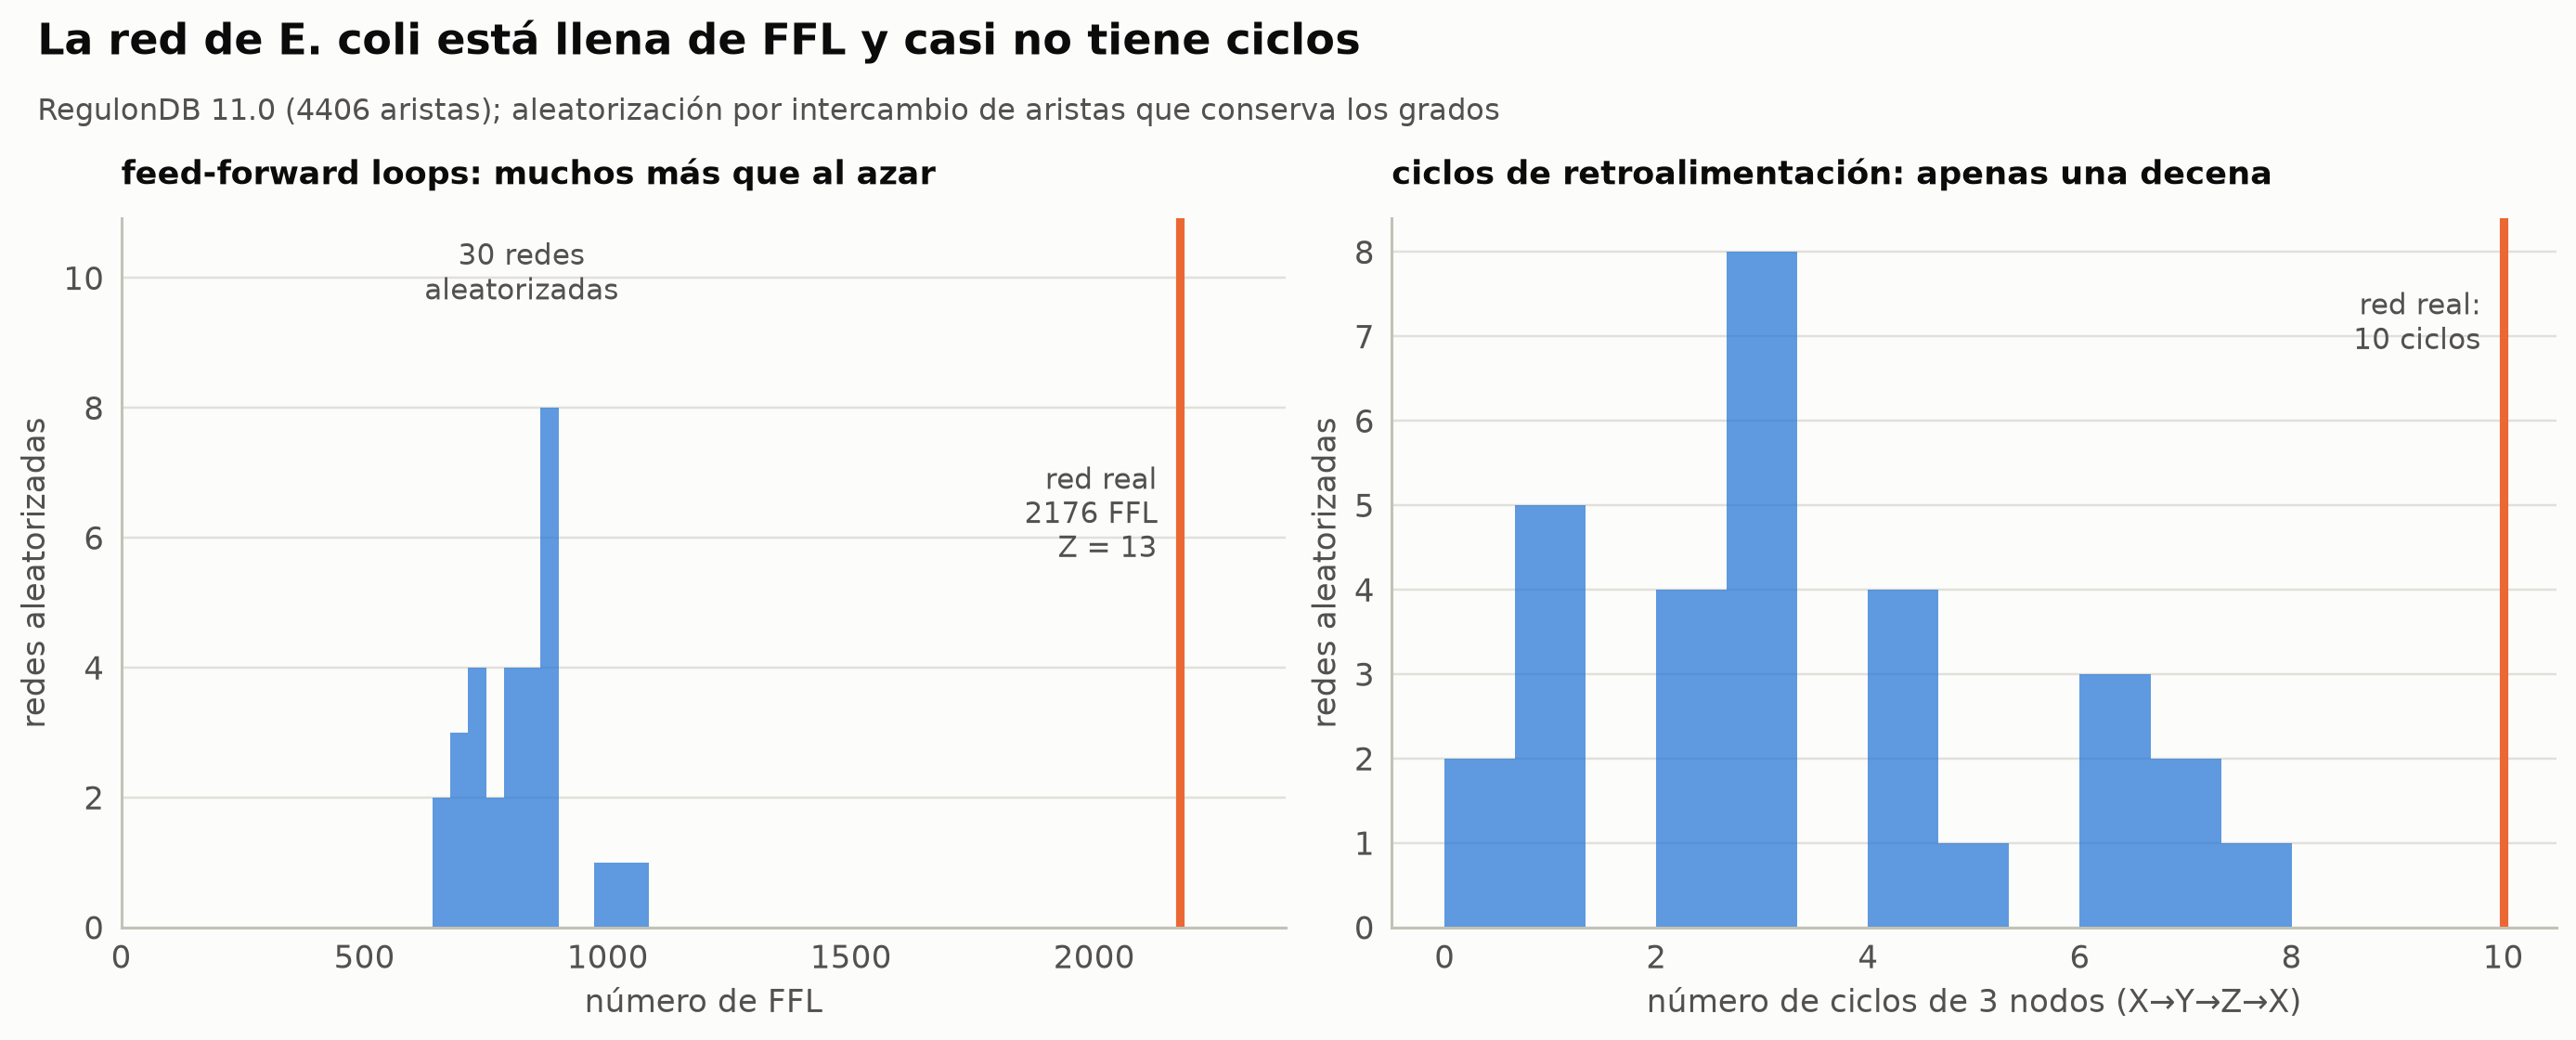

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax = axes[0]
ax.hist(rand[:, 0], bins=12, color=ec.BLUE, alpha=0.75, edgecolor="white")
ax.axvline(ffl_real, color=ec.ORANGE, lw=3)
ax.annotate(f"red real\n{ffl_real} FFL\nZ = {z_ffl:.0f}", (ffl_real, ax.get_ylim()[1] * 0.85), xytext=(-8, 0),
            textcoords="offset points", ha="right", va="top", fontsize=10, color=ec.INK_2)
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
ax.text(rand[:, 0].mean(), ax.get_ylim()[1] * 0.97, "30 redes\naleatorizadas", ha="center", va="top",
        fontsize=10, color=ec.INK_2)
ax.set_xlim(0, ffl_real * 1.1); ax.set_xlabel("número de FFL"); ax.set_ylabel("redes aleatorizadas")
ax.set_title("feed-forward loops: muchos más que al azar", loc="left", fontsize=11.5)
ax = axes[1]
ax.hist(rand[:, 1], bins=12, color=ec.BLUE, alpha=0.75, edgecolor="white")
ax.axvline(cyc_real, color=ec.ORANGE, lw=3)
ax.annotate(f"red real:\n{cyc_real} ciclos", (cyc_real, ax.get_ylim()[1] * 0.9), xytext=(-8, 0),
            textcoords="offset points", ha="right", va="top", fontsize=10, color=ec.INK_2)
ax.set_xlabel("número de ciclos de 3 nodos (X→Y→Z→X)"); ax.set_ylabel("redes aleatorizadas")
ax.set_title("ciclos de retroalimentación: apenas una decena", loc="left", fontsize=11.5)
ec.fig_title(fig, "La red de E. coli está llena de FFL y casi no tiene ciclos",
             f"RegulonDB 11.0 ({n_edges} aristas); aleatorización por intercambio de aristas que conserva los grados")
plt.show()

> 🔎 **Qué observamos.** La red real contiene 2 176 FFL frente a 822,6 de media en las redes aleatorizadas con los
> mismos grados: unas 2,65 veces más, una desviación de más de diez $\sigma$: el FFL es un **motivo**. Los ciclos de tres nodos, en cambio, son
> rarísimos: apenas una decena en toda la red frente a más de dos mil FFL. (Las redes aleatorizadas tienen todavía menos,
> porque con estos grados, unos pocos reguladores globales que casi nadie regula, es difícil cerrar un ciclo; por eso
> la $Z$ de los ciclos no dice mucho y lo que importa es su escasez absoluta.) La red transcripcional de *E. coli* es
> casi **jerárquica**: la información fluye de unos pocos reguladores globales hacia abajo, y las retroalimentaciones
> se concentran en la autorregulación. Por eso el *repressilator* de la sección 8 hubo que **construirlo**.

### Los signos del FFL

Cada una de las tres aristas puede activar o reprimir, así que hay **ocho tipos** de FFL. Un FFL es **coherente** si el
signo del camino directo ($X\to Z$) coincide con el del indirecto (el producto de los signos de $X\to Y$ y $Y\to Z$), e
**incoherente** en caso contrario. Mangan y Alon (2003) mostraron que los coherentes actúan como **retardos sensibles
al signo** y los incoherentes como **aceleradores**, y que dos tipos dominan las bases de datos: el **coherente tipo 1**
(C1, las tres aristas activan) y el **incoherente tipo 1** (I1, $X$ activa a $Y$ y a $Z$, pero $Y$ reprime a $Z$).

In [13]:
if RECOMPUTE_REGULONDB:
    sign = {(a, b): e for a, b, e in zip(e_net.src, e_net.gene, e_net.effect)}
    succ = {}
    for a, b in zip(e_net.src, e_net.gene):
        succ.setdefault(a, set()).add(b)
    ffl_list = []
    for x_, ys in succ.items():
        for y_ in ys:
            for z_ in succ.get(y_, set()) & ys:
                if z_ != x_:
                    ffl_list.append((x_, y_, z_, sign[(x_, y_)], sign[(y_, z_)], sign[(x_, z_)]))
    ffl_df = pd.DataFrame(ffl_list, columns=["X", "Y", "Z", "XY", "YZ", "XZ"])
    signed = ffl_df[ffl_df[["XY", "YZ", "XZ"]].isin(["+", "-"]).all(axis=1)].copy()
    val = {"+": 1, "-": -1}
    signed["clase"] = np.where(signed.XY.map(val) * signed.YZ.map(val) == signed.XZ.map(val),
                               "coherente", "incoherente")
    signed["tipo"] = signed.XY + signed.YZ + signed.XZ
    counts = signed.groupby(["tipo", "clase"]).size().reset_index(name="n").sort_values("n", ascending=False)
    ara = ffl_df[(ffl_df.X == "crp") & (ffl_df.Y == "araC") & ffl_df.Z.str.startswith("ara")]
    # Para el ejercicio 7: grado de salida de cada factor y FFL cuyo X es uno de los diez reguladores globales
    outdeg = edges[edges.src != edges.gene].groupby("tf").size().sort_values(ascending=False)
    top_genes = {tf_gene[t] or t for t in outdeg.head(10).index}
    R.update({"n_ffl": len(ffl_df), "n_ffl_signos": len(signed),
              "ffl_tipos": counts.to_dict(orient="records"),
              "ffl_ara": (ara.XY + ara.YZ + ara.XZ).value_counts().to_dict(),
              "top10_grado_salida": {k: int(v) for k, v in outdeg.head(10).items()},
              "frac_ffl_global": float(ffl_df.X.isin(top_genes).mean())})
    R = json.loads(json.dumps(R, default=int))     # tipos de NumPy -> tipos nativos
    with open("162_regulondb_resumen.json", "w", encoding="utf-8") as fh:
        json.dump(R, fh, ensure_ascii=False, indent=1)
    print("resumen recalculado guardado en 162_regulondb_resumen.json")
else:
    counts = pd.DataFrame(R["ffl_tipos"])
print(f"{R['n_ffl']} FFL; {R['n_ffl_signos']} con los tres signos definidos (se excluyen los que tienen aristas duales ±)")
print(counts.to_string(index=False))
print("\nEl FFL clásico de la arabinosa (X = CRP, Y = AraC, Z = genes ara*): número de FFL por signos XY YZ XZ")
print(R["ffl_ara"])

2176 FFL; 1694 con los tres signos definidos (se excluyen los que tienen aristas duales ±)
tipo       clase   n
 +++   coherente 423
 -+-   coherente 371
 +-+ incoherente 230
 --- incoherente 222
 -++ incoherente 155
 --+   coherente 126
 ++- incoherente  97
 +--   coherente  70

El FFL clásico de la arabinosa (X = CRP, Y = AraC, Z = genes ara*): número de FFL por signos XY YZ XZ
{'+++': 4, '+±+': 3, '++±': 1}


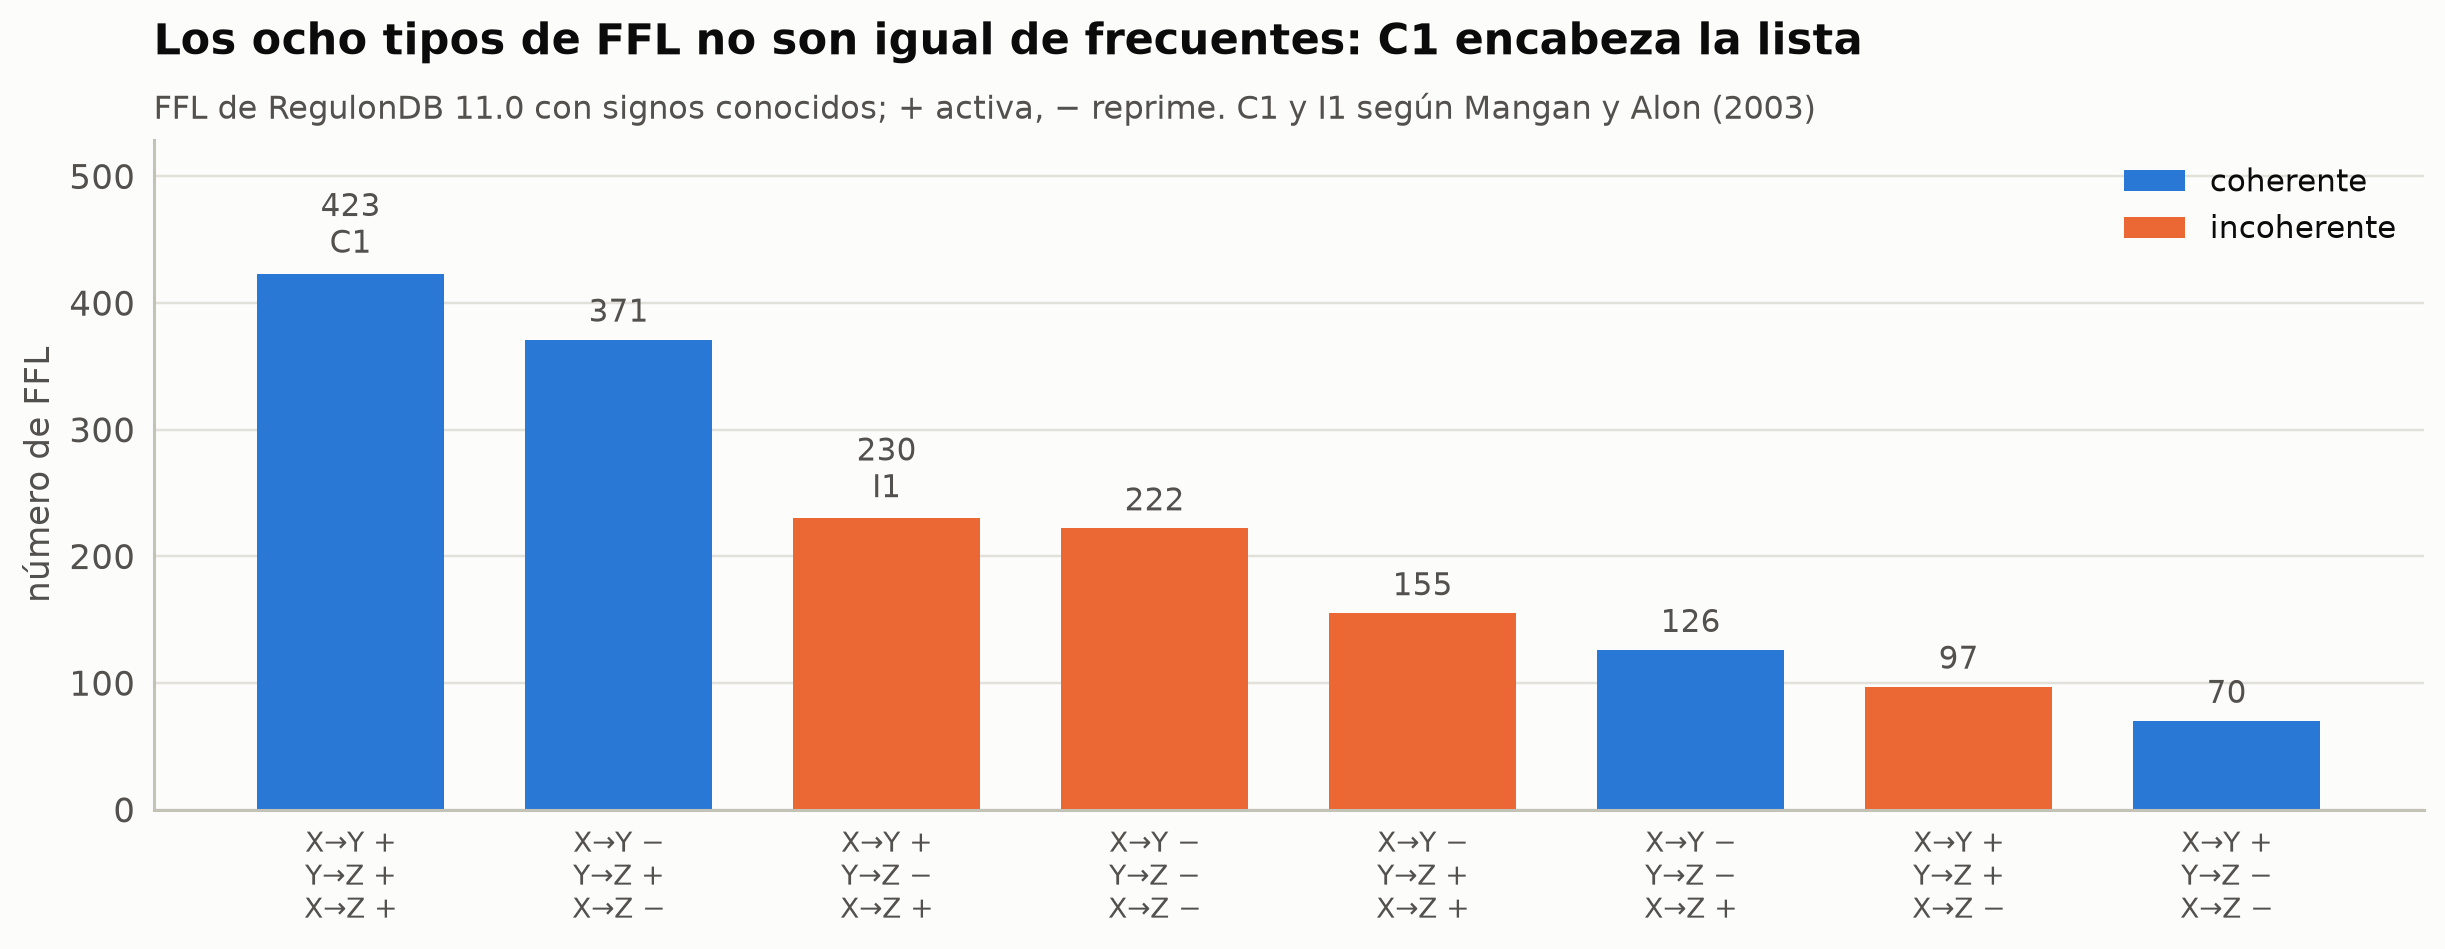

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.2))
order = counts.tipo.tolist()
colors = [ec.BLUE if c == "coherente" else ec.ORANGE for c in counts.clase]
ax.bar(range(len(order)), counts.n, color=colors, width=0.7)
names = {"+++": "C1", "+-+": "I1"}
for i, (tp, n_) in enumerate(zip(counts.tipo, counts.n)):
    lab = f"{n_}" + (f"\n{names[tp]}" if tp in names else "")
    ax.text(i, n_ + counts.n.max() * 0.02, lab, ha="center", va="bottom", fontsize=10, color=ec.INK_2)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"X→Y {t[0]}\nY→Z {t[1]}\nX→Z {t[2]}".replace("-", "−") for t in order], fontsize=9)
ax.set_ylim(0, counts.n.max() * 1.25); ax.set_ylabel("número de FFL")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ec.BLUE), plt.Rectangle((0, 0), 1, 1, color=ec.ORANGE)],
          labels=["coherente", "incoherente"], loc="upper right", frameon=False)
ec.title(ax, "Los ocho tipos de FFL no son igual de frecuentes: C1 encabeza la lista",
         "FFL de RegulonDB 11.0 con signos conocidos; + activa, − reprime. C1 y I1 según Mangan y Alon (2003)")
plt.show()

> 🔎 **Qué observamos.** Los ocho tipos no son igual de frecuentes. El coherente tipo 1 (C1) encabeza la lista (423),
> pero el segundo puesto no es para I1, como en las bases de datos que analizaron Mangan y Alon, sino para otro
> coherente (X reprime a Y y a Z, Y activa a Z: 371). El incoherente tipo 1 (I1, 230) es el incoherente más común,
> pero apenas supera al que tiene las tres aristas represoras (222). Los recuentos exactos dependen de la versión de la
> base de datos y de cómo se tratan las aristas duales. Un ejemplo de manual
> es el FFL de la arabinosa: CRP (la señal «no hay glucosa») activa a *araC* y a los genes *araBAD*, y AraC (la señal
> «hay arabinosa») también los activa. RegulonDB contiene ocho FFL CRP → AraC → *ara*: cuatro con las tres aristas
> activadoras y tres (los de *araB*, *araA* y *araD*) en los que la arista AraC → *ara* es dual, porque sin arabinosa
> AraC los reprime. En la siguiente sección vemos por qué ese diseño tiene sentido.

> ✅ **Compruebe su comprensión.** ¿Por qué la aleatorización debe conservar los grados? *(Porque la red tiene unos
> pocos reguladores globales, como CRP, con cientos de dianas: en una red aleatoria sin esa restricción casi no habría
> FFL, y cualquier red con concentradores «ganaría» contra ella. Conservar los grados aísla el efecto del
> cableado.)*

## 6. El *feed-forward loop* coherente: un filtro de persistencia

En un FFL, un regulador $X$ controla a otro regulador $Y$, y ambos controlan conjuntamente a un gen diana $Z$. Veamos
el tipo más común, el **coherente tipo 1 con compuerta AND**, el del ejemplo de la arabinosa. Con una señal $S_x$ que
activa a $X$ (la tomamos como un escalón, $X^*\in\{0,1\}$):

$$
\frac{dY}{dt}=\beta_y\,f(X^*,K_{xy})-\alpha_y Y,\qquad
\frac{dZ}{dt}=\beta_z\,f(X^*,K_{xz})\,f(Y,K_{yz})-\alpha_z Z,
$$

| Símbolo | Significado |
|---|---|
| $X^*$ | forma activa de $X$ (tras recibir su señal); aquí 0 o 1 |
| $f(u,K)$ | función de Hill activadora normalizada, $f(u,K)=u^n/(K^n+u^n)$ |
| $K_{xy},\ K_{xz},\ K_{yz}$ | umbrales de activación de cada arista |
| $\beta_y,\ \beta_z$ | producción máxima de $Y$ y de $Z$ (aquí 1) |
| $\alpha_y,\ \alpha_z$ | tasas de eliminación (aquí 1: el tiempo se mide en unidades de $1/\alpha$) |

**En palabras.** El producto $f(X^*)\,f(Y)$ es una **compuerta AND**: $Z$ solo se produce si $X^*$ **y** $Y$ están
presentes. Cuando la señal aparece, $X^*$ se activa de inmediato, pero $Y$ tiene que **acumularse** hasta superar
$K_{yz}$; solo entonces empieza a producirse $Z$. Si la señal desaparece antes, $Z$ nunca se enciende. Al apagarse la
señal, en cambio, basta con que $X^*$ desaparezca para que la compuerta se cierre: **no hay retardo**. El circuito ignora
los pulsos breves y responde a los persistentes. Para *E. coli* tiene todo el sentido: no conviene fabricar las
enzimas de la arabinosa ante una bajada pasajera de glucosa, pero sí dejar de fabricarlas en cuanto vuelve.

Usamos los parámetros del libro: $n=4$, $K_{xz}=K_{yz}=0{,}5$, un umbral bajo para $X\to Y$ ($K_{xy}=0{,}1$), un pulso
corto de duración $0{,}5$ y uno largo de duración 4, ambos a partir de $t=1$.

> 🤔 **Antes de ejecutar, prediga.** Con regulación simple, $Y$ tarda $\ln2\approx0{,}69$ en llegar a la mitad. ¿Qué
> fracción de su máximo alcanzará $Z$ durante el pulso de duración $0{,}5$?

In [15]:
def ffl(tt, s_on, s_off, Ky=0.5, Kz=0.5, Kxz=0.5, h=4):
    """FFL coherente tipo 1 con compuerta AND (código del libro). Devuelve Y(t), Z(t)."""
    def f(_t, y):
        Y, Z = y
        X = 1.0 if s_on <= _t < s_off else 0.0
        fy = (X / 0.1) ** h / (1 + (X / 0.1) ** h)                   # X -> Y (umbral K_xy = 0,1)
        gz = ((X / Kxz) ** h / (1 + (X / Kxz) ** h)) * ((Y / Kz) ** h / (1 + (Y / Kz) ** h))   # AND
        return [fy - Y, gz - Z]
    s = solve_ivp(f, (tt[0], tt[-1]), [0, 0], t_eval=tt, max_step=0.01, rtol=1e-8)
    return s.y

tt = np.linspace(0, 8, 401)
Yc, Zc = ffl(tt, 1.0, 1.5)        # pulso corto (0,5)
Yl, Zl = ffl(tt, 1.0, 5.0)        # pulso largo (4)
Zs = np.where(tt < 1, 0, np.where(tt < 5, 1 - np.exp(-(tt - 1)), (1 - np.exp(-4)) * np.exp(-(tt - 5))))  # sin FFL
print(f"pulso corto: máx Z = {Zc.max():.4f} (un {Zc.max():.0%} del máximo posible, 1)")
print(f"pulso largo: máx Z = {Zl.max():.3f}")
t_on = tt[np.argmax(Zl >= 0.5 * Zl.max())] - 1
t_off = tt[np.argmax((tt > 5) & (Zl <= 0.5 * Zl.max()))] - 5
print(f"encendido: Y cruza K_yz en {tt[np.argmax(Yl >= 0.5)] - 1:.2f}; Z llega a la mitad en {t_on:.2f} "
      f"(regulación simple: {math.log(2):.2f})")
print(f"apagado: Z cae a la mitad en {t_off:.2f} (sin retardo; ln2 = {math.log(2):.2f})")

pulso corto: máx Z = 0.0318 (un 3% del máximo posible, 1)
pulso largo: máx Z = 0.837
encendido: Y cruza K_yz en 0.70; Z llega a la mitad en 1.46 (regulación simple: 0.69)
apagado: Z cae a la mitad en 0.70 (sin retardo; ln2 = 0.69)


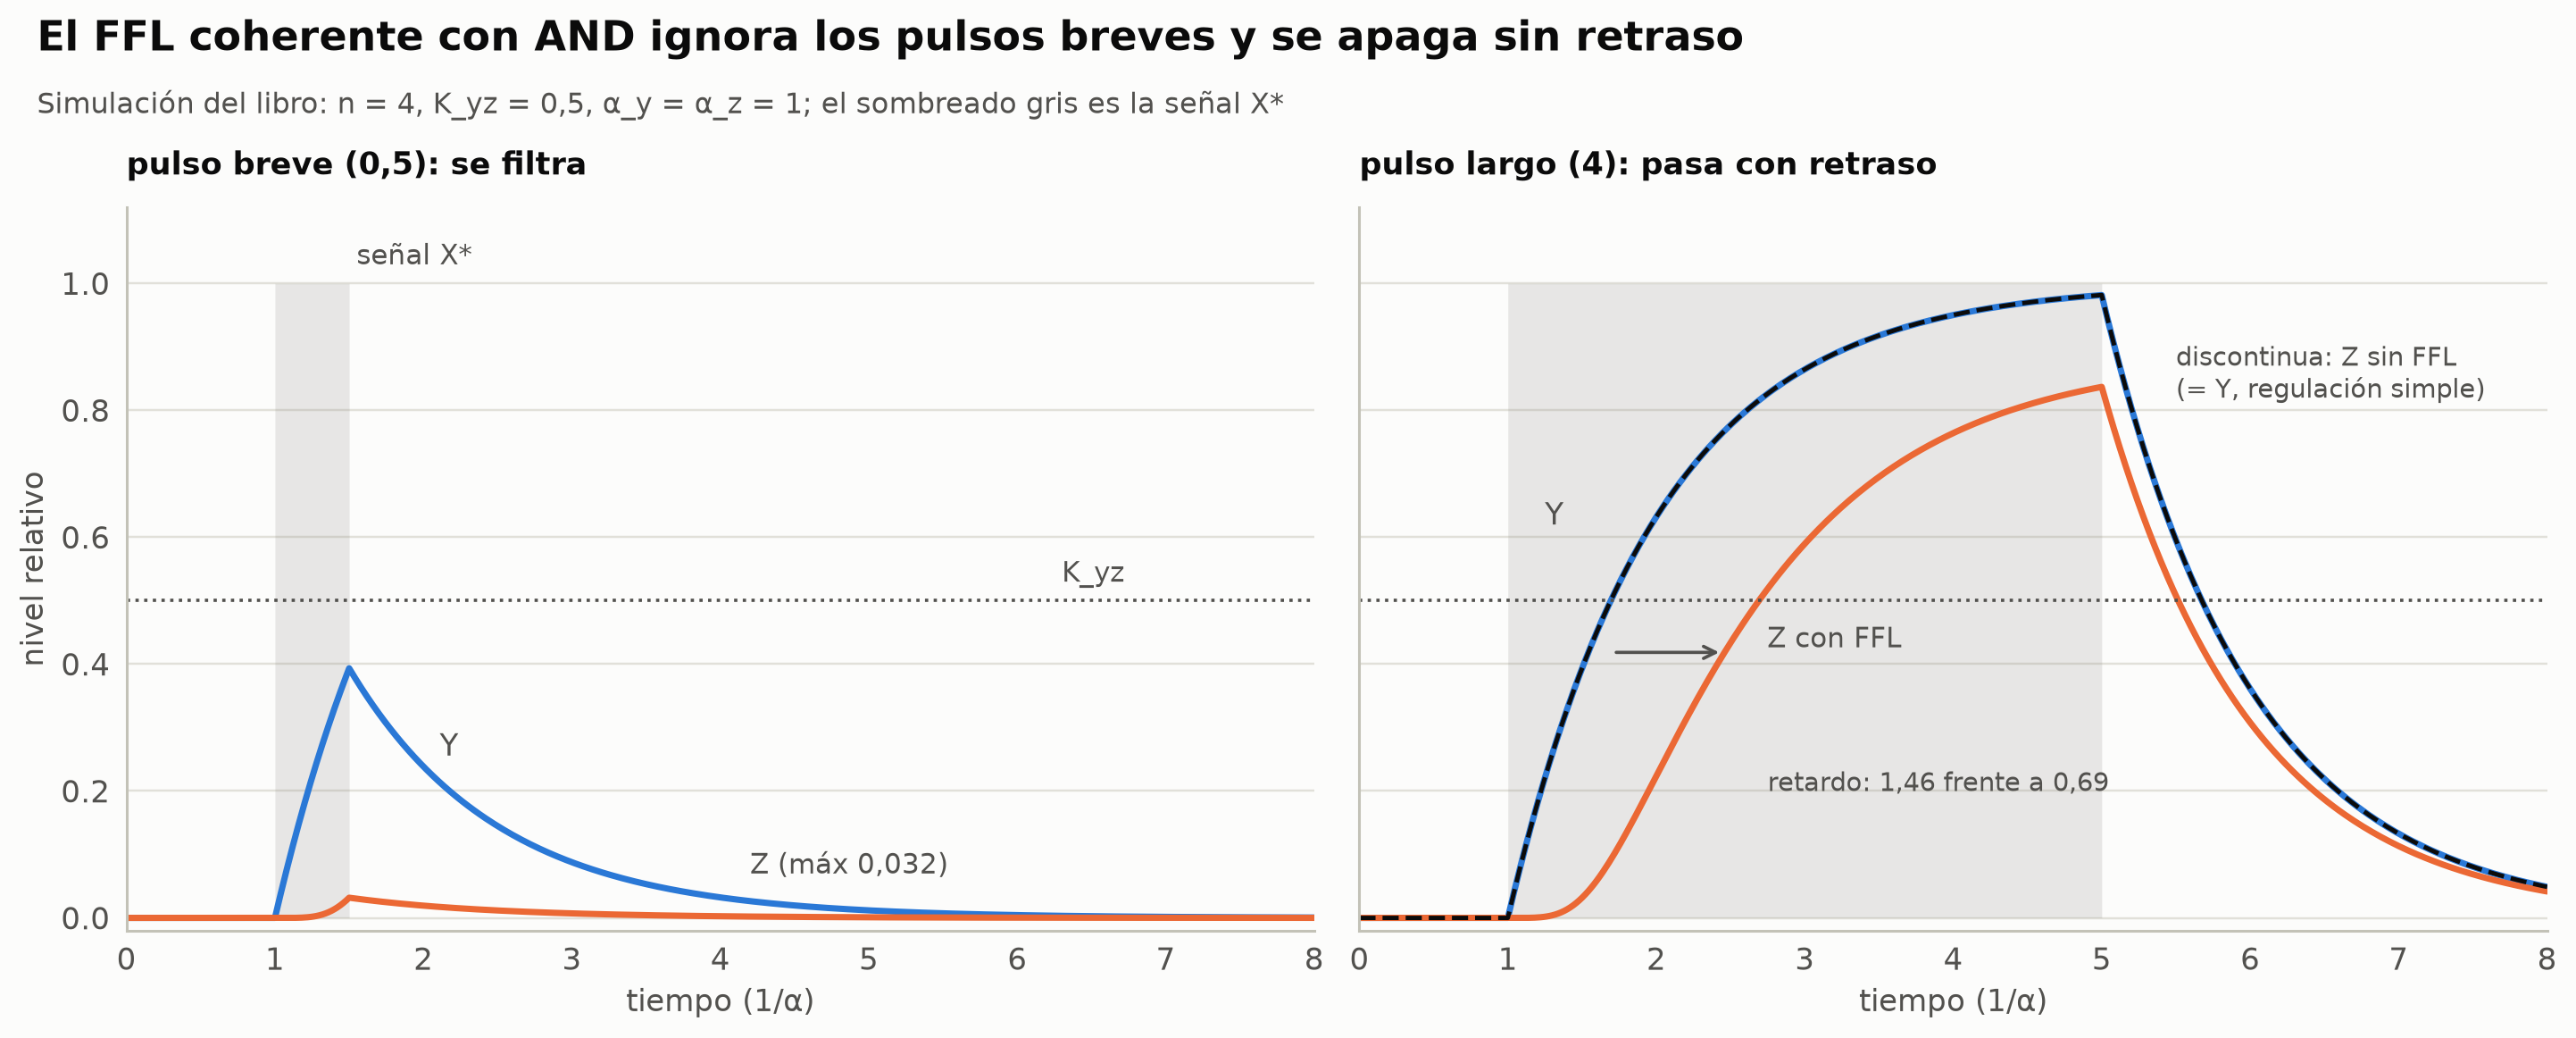

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (Y_, Z_, on, off, ttl) in zip(axes, ((Yc, Zc, 1, 1.5, "pulso breve (0,5): se filtra"),
                                             (Yl, Zl, 1, 5, "pulso largo (4): pasa con retraso"))):
    ax.fill_between(tt, 0, np.where((tt >= on) & (tt < off), 1, 0), step="post", color=ec.MUTED, alpha=0.18, lw=0)
    ax.plot(tt, Y_, color=ec.BLUE, lw=2.3)
    ax.plot(tt, Z_, color=ec.ORANGE, lw=2.3)
    ax.axhline(0.5, ls=":", color=ec.INK_2, lw=1.2)
    ax.set_xlim(0, 8); ax.set_ylim(-0.02, 1.12); ax.set_xlabel("tiempo (1/α)")
    ax.set_title(ttl, loc="left", fontsize=11.5)
axes[0].set_ylabel("nivel relativo")
axes[0].text(1.55, 1.03, "señal X*", fontsize=10, color=ec.INK_2)
axes[0].annotate("Y", (2.0, Yc[np.searchsorted(tt, 2.0)]), xytext=(6, 4), textcoords="offset points", color=ec.INK_2)
axes[0].text(4.2, 0.07, f"Z (máx {Zc.max():.3f})".replace(".", ","), color=ec.INK_2, fontsize=10)
axes[0].text(6.3, 0.53, "K_yz", fontsize=10, color=ec.INK_2)
axes[1].plot(tt, Zs, ls="--", color=ec.INK, lw=1.6)
axes[1].text(1.25, 0.62, "Y", color=ec.INK_2)
axes[1].annotate("Z con FFL", (2.6, Zl[np.searchsorted(tt, 2.6)]), xytext=(8, -10), textcoords="offset points",
                 color=ec.INK_2, fontsize=10)
axes[1].text(5.5, 0.82, "discontinua: Z sin FFL\n(= Y, regulación simple)", fontsize=9.5, color=ec.INK_2)
axes[1].annotate("", xy=(1 + t_on, 0.5 * Zl.max()), xytext=(1 + math.log(2), 0.5 * Zl.max()),
                 arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
axes[1].text(2.75, 0.2, f"retardo: {t_on:.2f} frente a {math.log(2):.2f}".replace(".", ","), fontsize=9.5, color=ec.INK_2)
ec.fig_title(fig, "El FFL coherente con AND ignora los pulsos breves y se apaga sin retraso",
             "Simulación del libro: n = 4, K_yz = 0,5, α_y = α_z = 1; el sombreado gris es la señal X*")
plt.show()

> 🔎 **Qué observamos.** Ante el pulso breve, $Y$ no llega al umbral $K_{yz}$ y $Z$ apenas alcanza un **3 %** de su
> máximo: el pulso se filtra. Ante el pulso largo, $Z$ se enciende con **retraso** (tarda 1,46 en llegar a la mitad de
> su máximo, frente a 0,69 con regulación simple) pero se **apaga sin retraso** (0,70) cuando la señal desaparece: un
> **retardo sensible al signo**.

### 🎛️ ¿Qué duración mínima deja pasar el filtro?

Mueva el deslizador para cambiar la duración del pulso. El recuadro de cada curva muestra el valor en cada instante y
si $Y$ ya superó el umbral $K_{yz}$ (la compuerta AND está «abierta» solo cuando **ambas** entradas lo están).

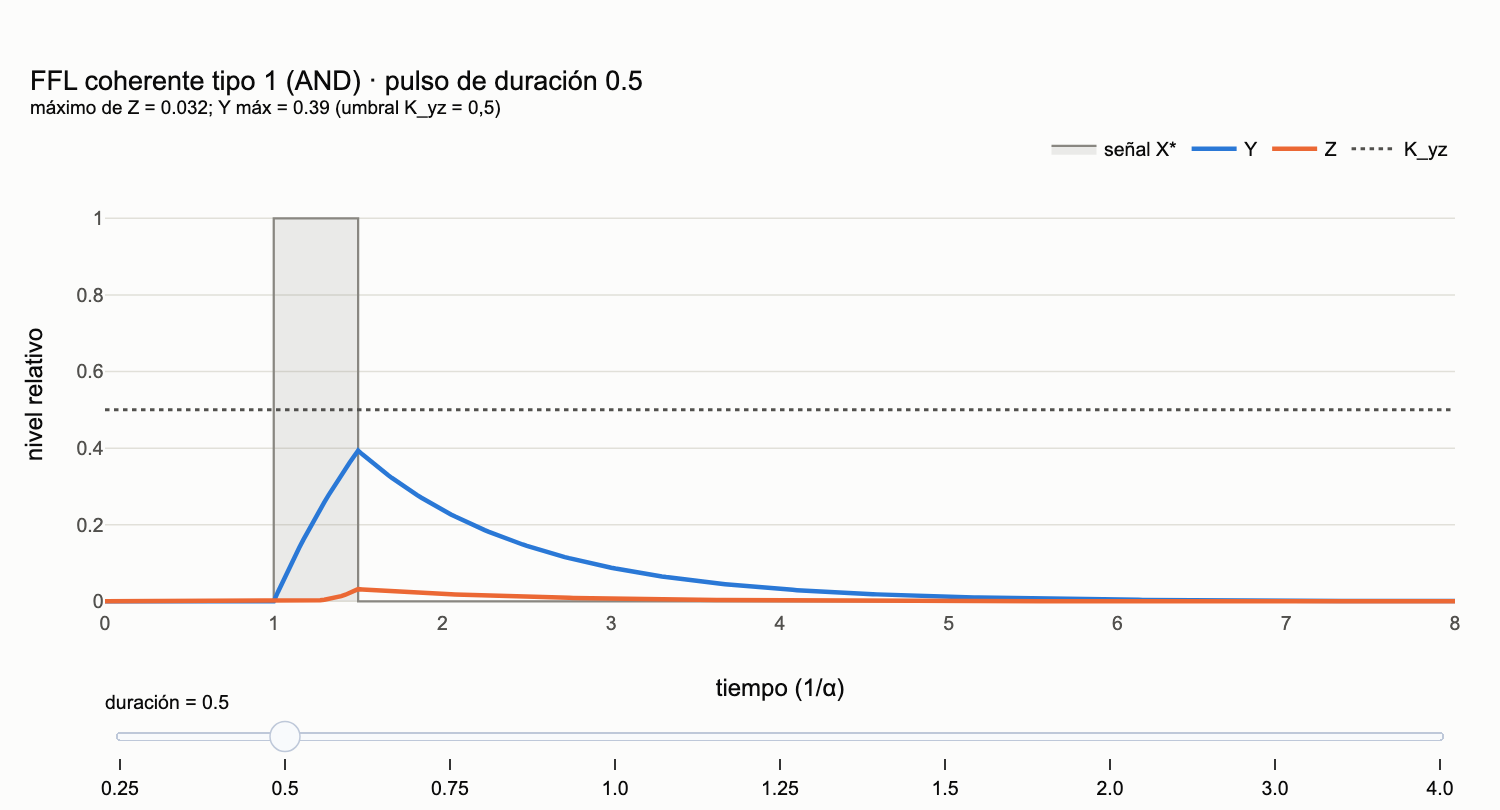

In [17]:
durs = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0]
tt2 = np.linspace(0, 8, 321)
fig = go.Figure()
for d in durs:
    Y_, Z_ = ffl(tt2, 1.0, 1.0 + d)
    Xs_ = np.where((tt2 >= 1) & (tt2 < 1 + d), 1.0, 0.0)
    gate = np.where((Xs_ > 0) & (Y_ > 0.5), "abierta (X* y Y > K_yz)", np.where(Xs_ > 0, "cerrada: falta Y", "cerrada: sin señal"))
    vis = d == 0.5
    fig.add_trace(go.Scatter(x=tt2, y=Xs_, mode="lines", line=dict(shape="hv", color=ec.MUTED, width=1.5),
                             fill="tozeroy", fillcolor="rgba(137,135,129,0.15)", name="señal X*", visible=vis,
                             hovertemplate="t = %{x:.2f}<br>X* = %{y:.0f}<extra>señal</extra>"))
    fig.add_trace(go.Scatter(x=tt2, y=Y_, mode="lines", line=dict(color=ec.BLUE, width=3), name="Y", visible=vis,
                             customdata=gate, hovertemplate="t = %{x:.2f}<br>Y = %{y:.3f}<br>compuerta AND: "
                                                            "%{customdata}<extra>Y</extra>"))
    fig.add_trace(go.Scatter(x=tt2, y=Z_, mode="lines", line=dict(color=ec.ORANGE, width=3), name="Z", visible=vis,
                             hovertemplate="t = %{x:.2f}<br>Z = %{y:.3f}<br>máx Z en este pulso = " + f"{Z_.max():.3f}"
                                           + "<extra>Z</extra>"))
fig.add_trace(go.Scatter(x=[0, 8], y=[0.5, 0.5], mode="lines", line=dict(dash="dot", color=ec.INK_2), name="K_yz",
                         hoverinfo="skip"))
steps = []
for k, d in enumerate(durs):
    Y_, Z_ = ffl(tt2, 1.0, 1.0 + d)
    vis = [False] * (3 * len(durs)) + [True]
    vis[3 * k:3 * k + 3] = [True] * 3
    steps.append(dict(method="update", label=str(d), args=[{"visible": vis},
        {"title.text": f"FFL coherente tipo 1 (AND) · pulso de duración {d}<br><sup>máximo de Z = {Z_.max():.3f}; "
                       f"Y máx = {Y_.max():.2f} (umbral K_yz = 0,5)</sup>"}]))
Y_, Z_ = ffl(tt2, 1.0, 1.5)
fig.update_layout(sliders=[dict(active=durs.index(0.5), steps=steps, currentvalue=dict(prefix="duración = "),
                                pad=dict(t=50))],
                  title=f"FFL coherente tipo 1 (AND) · pulso de duración 0.5<br><sup>máximo de Z = {Z_.max():.3f}; "
                        f"Y máx = {Y_.max():.2f} (umbral K_yz = 0,5)</sup>",
                  xaxis_title="tiempo (1/α)", yaxis=dict(title="nivel relativo", range=[-0.02, 1.1]), height=540,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  margin=dict(t=120, l=70, r=30, b=40))
fig.show()

> ✅ **Compruebe su comprensión.** Con los parámetros del libro, ¿por encima de qué duración de pulso empieza $Z$ a
> encenderse de verdad? *(Hace falta que $Y$ supere $K_{yz}=0{,}5$, lo que con $\alpha_y=1$ exige una duración de al
> menos $\ln2\approx0{,}7$; a partir de ahí el máximo de $Z$ crece rápido. El ejercicio 3 lo cuantifica.)*

## 7. El interruptor biestable: nulclinas y estabilidad

### Una memoria hecha con dos represores

Gardner, Cantor y Collins (2000) construyeron en *E. coli* un circuito con **dos promotores reprimibles dispuestos en
inhibición mutua**: el producto de cada gen reprime al otro (en su diseño, LacI y un represor sensible a la
temperatura). El resultado fue un **interruptor genético**: una red **biestable** que se puede conmutar entre sus dos
estados con un pulso transitorio de inductor químico (IPTG) o de temperatura, y que **recuerda** su estado cuando el
pulso termina. Es como un interruptor de la luz de pared: basta un empujón para cambiarlo y se queda donde lo dejamos.

Un modelo adimensional del circuito es

$$
\frac{du}{dt}=\frac{\alpha_1}{1+v^{\beta}}-u,\qquad
\frac{dv}{dt}=\frac{\alpha_2}{1+u^{\gamma}}-v,
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $u,\ v$ | concentraciones de los dos represores, en unidades de sus constantes de represión |
| $\alpha_1,\ \alpha_2$ | tasas de síntesis efectivas (fuerza de cada promotor) |
| $\beta,\ \gamma$ | **cooperatividad** de la represión de cada promotor (¡aquí $\beta$ es un exponente de Hill!) |
| $t$ | tiempo en unidades de $1/\alpha$ (la tasa de eliminación, igual para ambos) |

### Nulclinas y puntos fijos

Un sistema de dos variables se entiende mejor en su **plano de fases**: cada punto $(u,v)$ es un estado de la célula,
y las ecuaciones asignan a cada uno una velocidad, una flecha que dice hacia dónde se mueve. La **nulclina** de $u$ es
la curva donde $du/dt=0$, es decir, $u=\alpha_1/(1+v^\beta)$; la de $v$ es $v=\alpha_2/(1+u^\gamma)$. Donde se cortan,
ambas derivadas se anulan: son los **puntos fijos** (estados en los que la célula se quedaría para siempre). Para
decidir si un punto fijo es estable, **linealizamos**.

**Estabilidad lineal en dos dimensiones.** Sea $(u^*,v^*)$ un punto fijo de $\dot{\mathbf{x}}=\mathbf{F}(\mathbf{x})$
y $J$ su matriz jacobiana, $J_{ij}=\partial F_i/\partial x_j$ evaluada en él. Las pequeñas perturbaciones evolucionan
como $\delta\mathbf{x}(t)=\sum_k c_k\,\mathbf{e}_k\,e^{\lambda_k t}$. El punto fijo es estable si todos los autovalores
tienen parte real negativa; en dos dimensiones esto equivale a

$$
\operatorname{tr}J<0\quad\text{y}\quad\det J>0,\qquad
\lambda_{1,2}=\frac{\operatorname{tr}J\pm\sqrt{(\operatorname{tr}J)^2-4\det J}}{2}.
$$

Si $\det J<0$, los autovalores son reales y de signo opuesto: el punto fijo es una **silla** (atrae en una dirección y
repele en otra, como un puerto de montaña).

| Símbolo | Significado |
|---|---|
| $J$ | jacobiano: cómo responde cada tasa de cambio a pequeñas variaciones de cada variable |
| $\lambda_k,\ \mathbf{e}_k$ | autovalores y autovectores de $J$; $\operatorname{Re}\lambda_k$ es la tasa de crecimiento o decaimiento de cada modo |
| $\operatorname{tr}J,\ \det J$ | traza ($\lambda_1+\lambda_2$) y determinante ($\lambda_1\lambda_2$) |

Para el interruptor, derivando,

$$
J=\begin{pmatrix}-1 & -\dfrac{\alpha_1\beta v^{\beta-1}}{(1+v^\beta)^2}\\[10pt] -\dfrac{\alpha_2\gamma u^{\gamma-1}}{(1+u^\gamma)^2} & -1\end{pmatrix}
\equiv\begin{pmatrix}-1 & -a\\ -b & -1\end{pmatrix},
\qquad \lambda=-1\pm\sqrt{ab}.
$$

La traza siempre vale $-2$; la estabilidad depende solo de si $ab<1$ (estable) o $ab>1$ (silla). **En palabras:** un
punto fijo es inestable cuando la represión mutua es tan sensible que una pequeña ventaja de un represor se amplifica
en el otro más de lo que la eliminación puede corregir.

### Ejemplo del libro: «Biestabilidad con $\alpha_1=\alpha_2=10$ y $\beta=\gamma=2$»

Sustituyendo $v=10/(1+u^2)$ en la nulclina de $u$ queda una sola ecuación, $u=10/\big(1+(10/(1+u^2))^2\big)$, que
resolvemos numéricamente buscando cambios de signo en una rejilla fina.

In [18]:
def toggle_rhs(a1=10.0, a2=10.0, b=2.0, g=2.0):
    return lambda _t, y: [a1 / (1 + y[1] ** b) - y[0], a2 / (1 + y[0] ** g) - y[1]]

def toggle_jac(u, v, a1=10.0, a2=10.0, b=2.0, g=2.0):
    return np.array([[-1, -a1 * b * v ** (b - 1) / (1 + v ** b) ** 2],
                     [-a2 * g * u ** (g - 1) / (1 + u ** g) ** 2, -1]])

def toggle_fixed_points(a1=10.0, a2=10.0, b=2.0, g=2.0, npts=200001):
    """Puntos fijos (u*, v*), autovalores y tipo, buscando raíces de u - a1/(1+v(u)^b) con v(u) = a2/(1+u^g)."""
    F = lambda u: u - a1 / (1 + (a2 / (1 + u ** g)) ** b)
    grid = np.linspace(1e-4, a1 + 1, npts)
    vals = F(grid)
    out = []
    for i in np.where(vals[:-1] * vals[1:] < 0)[0]:
        u = brentq(F, grid[i], grid[i + 1]); v = a2 / (1 + u ** g)
        ev = np.sort(np.linalg.eigvals(toggle_jac(u, v, a1, a2, b, g)).real)[::-1]
        out.append(dict(u=u, v=v, lam1=ev[0], lam2=ev[1], tipo="estable" if ev.max() < 0 else "silla"))
    return out

fps = toggle_fixed_points()
tab = pd.DataFrame([{"punto fijo (u*, v*)": f"({p['u']:.3f}; {p['v']:.3f})",
                     "a": round(-toggle_jac(p['u'], p['v'])[0, 1], 3), "b": round(-toggle_jac(p['u'], p['v'])[1, 0], 3),
                     "λ1, λ2": f"{p['lam1']:+.1f}; {p['lam2']:+.1f}", "tipo": p["tipo"]} for p in fps])
tab

,"punto fijo (u*, v*)",a,b,"λ1, λ2",tipo
0,(0.101; 9.899),0.02,1.98,-0.8; -1.2,estable
1,(2.000; 2.000),1.60,1.60,+0.6; -2.6,silla
2,(9.899; 0.101),1.98,0.02,-0.8; -1.2,estable


Es exactamente la tabla del libro: dos estados estables, $(0{,}101;\,9{,}899)$ («V encendido») y $(9{,}899;\,0{,}101)$
(«U encendido»), con autovalores $-0{,}8$ y $-1{,}2$, y una **silla** en $(2;\,2)$ con $\lambda=+0{,}6$ y $-2{,}6$
(compruébelo a mano: en $(2,2)$, $a=b=10\cdot2\cdot2/(1+4)^2=1{,}6$ y $\lambda=-1\pm1{,}6$). La silla está en la
diagonal y su autovector estable, a lo largo de ella, forma la **separatriz**: toda trayectoria que empieza por encima
termina en «V encendido», y toda la que empieza por debajo, en «U encendido». Lo comprobamos con el código del libro
(integrando hasta $t=30$):

In [19]:
# interruptor.py (libro)
a1 = a2 = 10.0
n = 2

def toggle(t, y):
    u, v = y
    return [a1 / (1 + v**n) - u, a2 / (1 + u**n) - v]

for y0 in [(0.3, 2.0), (2.0, 0.3), (4.0, 3.9)]:
    s = solve_ivp(toggle, (0, 30), y0, rtol=1e-8)
    print(y0, "->", s.y[:, -1].round(2))

(0.3, 2.0) -> [0.1 9.9]
(2.0, 0.3) -> [9.9 0.1]
(4.0, 3.9) -> [9.9 0.1]


El estado inicial $(4{,}0;\,3{,}9)$ está muy cerca de la diagonal, pero **por debajo**: termina en «U encendido»,
aunque tarda (en la figura siguiente, integrada solo hasta $t=12$ como en el libro, todavía va por $(9{,}46;\,0{,}14)$).

desde (0.3, 2.0) -> (0.10, 9.90) en t = 12
desde (2.0, 0.3) -> (9.90, 0.10) en t = 12
desde (9.0, 10.5) -> (0.11, 9.82) en t = 12
desde (10.5, 9.0) -> (9.82, 0.11) en t = 12
desde (6.0, 10.8) -> (0.10, 9.89) en t = 12
desde (10.8, 5.0) -> (9.89, 0.10) en t = 12
desde (0.2, 0.25) -> (0.11, 9.85) en t = 12
desde (4.0, 3.9) -> (9.46, 0.14) en t = 12


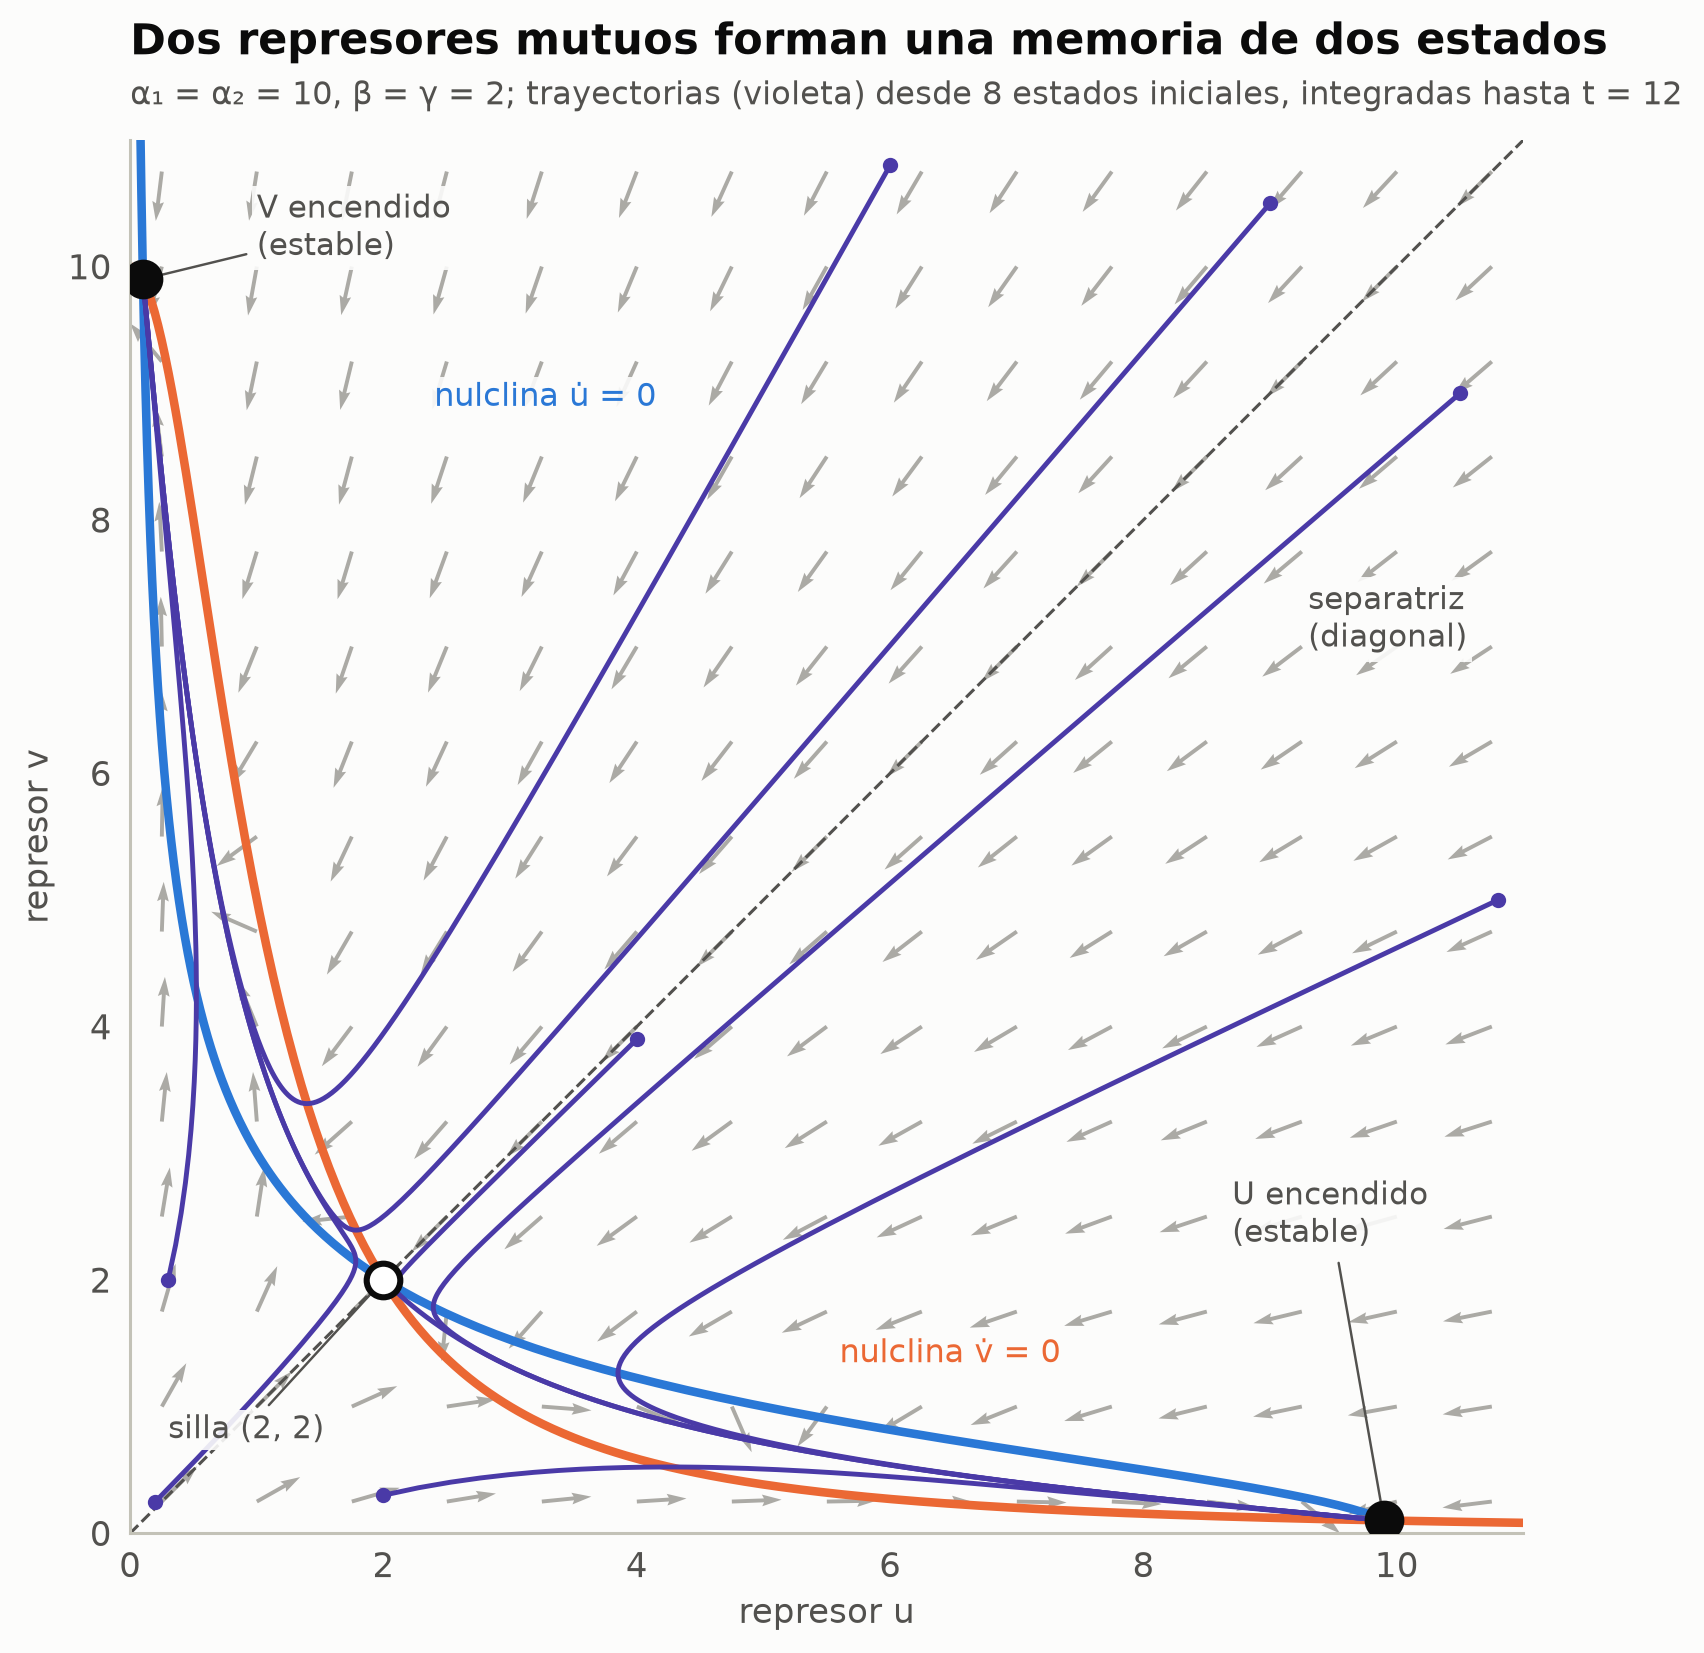

In [20]:
rhs10 = toggle_rhs()
inits = [(0.3, 2.0), (2.0, 0.3), (9.0, 10.5), (10.5, 9.0), (6.0, 10.8), (10.8, 5.0), (0.2, 0.25), (4.0, 3.9)]
trajs = [solve_ivp(rhs10, (0, 12), y0, t_eval=np.linspace(0, 12, 300), rtol=1e-8).y for y0 in inits]
for y0, tr in zip(inits, trajs):
    print(f"desde {y0} -> ({tr[0, -1]:.2f}, {tr[1, -1]:.2f}) en t = 12")

fig, ax = plt.subplots(figsize=(8.2, 7.4))
Ug, Vg = np.meshgrid(np.linspace(0.25, 10.75, 15), np.linspace(0.25, 10.75, 15))
dU, dV = 10 / (1 + Vg**2) - Ug, 10 / (1 + Ug**2) - Vg
nrm = np.hypot(dU, dV)
ax.quiver(Ug, Vg, dU / nrm, dV / nrm, color=ec.MUTED, alpha=0.7, scale=28, width=0.0028)
vv = np.linspace(0, 11, 400)
ax.plot(10 / (1 + vv**2), vv, color=ec.BLUE, lw=2.8)
ax.plot(vv, 10 / (1 + vv**2), color=ec.ORANGE, lw=2.8)
ax.plot([0, 11], [0, 11], ls="--", color=ec.INK_2, lw=1)
for tr in trajs:
    ax.plot(tr[0], tr[1], color=ec.VIOLET, lw=1.6)
    ax.plot(tr[0, 0], tr[1, 0], "o", color=ec.VIOLET, ms=4)
for p in fps:
    ax.plot(p["u"], p["v"], "o", ms=11, mfc=ec.INK if p["tipo"] == "estable" else "white", mec=ec.INK, mew=2, zorder=5)
ax.annotate("V encendido\n(estable)", (0.101, 9.899), xytext=(1.0, 10.6), fontsize=10, color=ec.INK_2, va="top",
            bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5), arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.annotate("U encendido\n(estable)", (9.899, 0.101), xytext=(8.7, 2.3), fontsize=10, color=ec.INK_2,
            bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5), arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.annotate("silla (2, 2)", (2, 2), xytext=(0.3, 0.75), fontsize=10, color=ec.INK_2, bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5),
            arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.text(2.4, 8.9, "nulclina u̇ = 0", color=ec.BLUE, fontsize=10.5, bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5))
ax.text(5.6, 1.35, "nulclina v̇ = 0", color=ec.ORANGE, fontsize=10.5, bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5))
ax.text(9.3, 7.0, "separatriz\n(diagonal)", color=ec.INK_2, fontsize=10, ha="left", bbox=dict(fc=ec.SURFACE, ec="none", alpha=0.9, pad=1.5))
ax.set_xlim(0, 11); ax.set_ylim(0, 11); ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("represor u"); ax.set_ylabel("represor v")
ec.title(ax, "Dos represores mutuos forman una memoria de dos estados",
         "α₁ = α₂ = 10, β = γ = 2; trayectorias (violeta) desde 8 estados iniciales, integradas hasta t = 12")
plt.show()

> 🔎 **Qué observamos.** Las nulclinas azul y naranja se cortan tres veces. Las flechas grises empujan hacia los dos
> puntos negros; cada trayectoria violeta termina en el estable que está **de su lado de la diagonal**. Las que empiezan
> cerca de la diagonal (arriba a la derecha, o cerca del origen) primero se deslizan hacia la silla por su dirección
> estable y luego se desvían bruscamente a lo largo de su dirección inestable.

### 🎬 El flujo, en movimiento

Soltamos 80 células con estados iniciales al azar y las dejamos evolucionar. El color indica el estado final al que
llegará cada una.

![Ochenta estados iniciales al azar fluyen por el plano de fases del interruptor (α = 10, β = γ = 2) y se reparten entre los dos atractores según el lado de la separatriz en que empiezan](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.2_toggle_flujo.gif)

*Ochenta estados iniciales al azar fluyen por el plano de fases del interruptor (α = 10, β = γ = 2) y se reparten entre los dos atractores según el lado de la separatriz en que empiezan*

In [21]:
rng_a = np.random.default_rng(162)
P0 = rng_a.uniform(0, 11, size=(80, 2))
t_anim = np.concatenate([[0], np.geomspace(0.02, 12, 49)])
paths = np.array([solve_ivp(rhs10, (0, 12), p0, t_eval=t_anim, rtol=1e-7).y for p0 in P0])  # (80, 2, 50)
final_u = paths[:, 0, -1] > paths[:, 1, -1]
colors_pts = np.where(final_u, ec.ORANGE, ec.BLUE)

fig = plt.figure(figsize=(7.2, 7.6))
fig.set_layout_engine("none")
ax = fig.add_axes([0.11, 0.08, 0.85, 0.76])
ax.plot(10 / (1 + vv**2), vv, color=ec.BLUE, lw=2, alpha=0.6)
ax.plot(vv, 10 / (1 + vv**2), color=ec.ORANGE, lw=2, alpha=0.6)
ax.plot([0, 11], [0, 11], ls="--", color=ec.INK_2, lw=1)
for p in fps:
    ax.plot(p["u"], p["v"], "o", ms=11, mfc=ec.INK if p["tipo"] == "estable" else "white", mec=ec.INK, mew=2, zorder=5)
tails = [ax.plot([], [], color=c, lw=0.9, alpha=0.5)[0] for c in colors_pts]
dots = ax.scatter(P0[:, 0], P0[:, 1], s=26, c=colors_pts, edgecolor="white", linewidth=0.5, zorder=4)
ax.set_xlim(0, 11); ax.set_ylim(0, 11); ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("represor u"); ax.set_ylabel("represor v")
fig.text(0.02, 0.975, "Cada célula cae en uno de dos atractores", fontsize=14, fontweight="bold", va="top")
fig.text(0.02, 0.935, "Naranja: acabará en «U encendido»; azul: en «V encendido»", fontsize=10.5, color=ec.INK_2, va="top")
clock = ax.text(10.8, 10.6, "", ha="right", va="top", fontsize=11, color=ec.INK_2)

def update(f):
    for k, ln in enumerate(tails):
        ln.set_data(paths[k, 0, :f + 1], paths[k, 1, :f + 1])
    dots.set_offsets(paths[:, :, f])
    clock.set_text(f"t = {t_anim[f]:.2f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(t_anim), interval=120, name="16.2_toggle_flujo")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Cooperatividad y fuerza del promotor: cuándo hay memoria

Sin cooperatividad ($\beta=\gamma=1$) las nulclinas se cortan en un único punto, $u^*=v^*=2{,}70$, que es estable: **no
hay memoria**. Y en el caso simétrico ($\alpha_1=\alpha_2=\alpha$, $\beta=\gamma=2$) el punto diagonal cumple
$u(1+u^2)=\alpha$ y tiene $a=b=2\alpha u/(1+u^2)^2=2u^2/(1+u^2)$. La condición de silla $a>1$ equivale a $u>1$, es decir,
$\alpha>1\cdot(1+1)=2$. Con promotores más débiles que ese umbral, el interruptor no funciona.

β = γ = 1: [(2.7, 2.7, 'estable')]
α =  1.5: 1 puntos fijos
α =  1.9: 1 puntos fijos
α =  2.0: 1 puntos fijos
α =  2.1: 3 puntos fijos
α =  3.0: 3 puntos fijos
α = 10.0: 3 puntos fijos


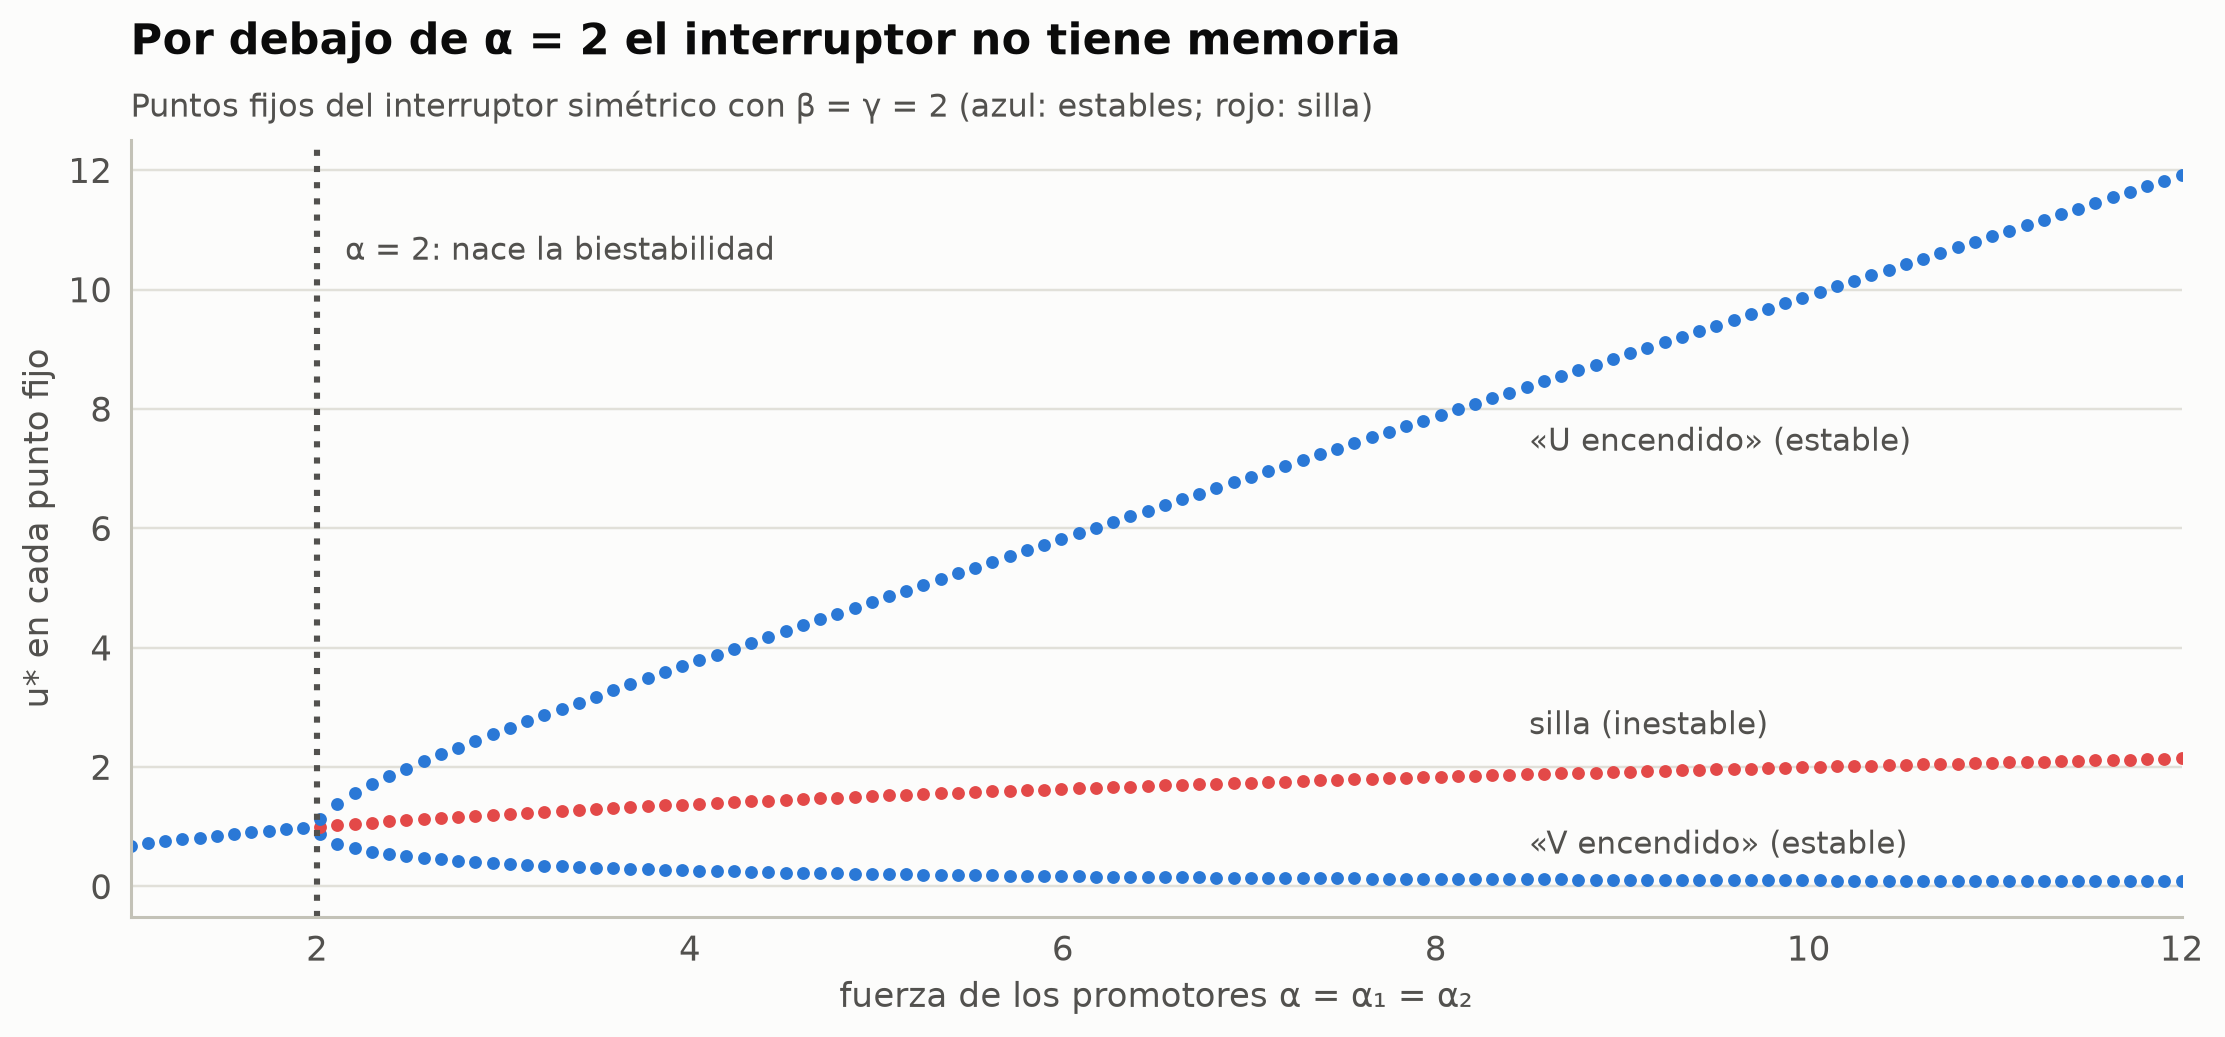

In [22]:
fp1 = toggle_fixed_points(b=1.0, g=1.0)
print("β = γ = 1:", [(round(p["u"], 2), round(p["v"], 2), p["tipo"]) for p in fp1])
for a in (1.5, 1.9, 2.0, 2.1, 3.0, 10.0):
    print(f"α = {a:4}: {len(toggle_fixed_points(a, a, npts=40001))} puntos fijos")

# Diagrama de bifurcación: u* frente a α (caso simétrico, β = γ = 2)
alphas = np.linspace(1.0, 12, 120)
fig, ax = plt.subplots(figsize=(10, 4.6))
for a in alphas:
    for p in toggle_fixed_points(a, a, npts=20001):
        ax.plot(a, p["u"], "o", ms=3.2, color=ec.BLUE if p["tipo"] == "estable" else ec.RED)
ax.axvline(2, ls=":", color=ec.INK_2)
ax.text(2.15, 10.5, "α = 2: nace la biestabilidad", fontsize=10, color=ec.INK_2)
ax.text(8.5, 7.3, "«U encendido» (estable)", fontsize=10, color=ec.INK_2)
ax.text(8.5, 2.55, "silla (inestable)", fontsize=10, color=ec.INK_2)
ax.text(8.5, 0.55, "«V encendido» (estable)", fontsize=10, color=ec.INK_2)
ax.set_xlabel("fuerza de los promotores α = α₁ = α₂"); ax.set_ylabel("u* en cada punto fijo"); ax.set_xlim(1, 12)
ec.title(ax, "Por debajo de α = 2 el interruptor no tiene memoria",
         "Puntos fijos del interruptor simétrico con β = γ = 2 (azul: estables; rojo: silla)")
plt.show()

> 🔎 **Qué observamos.** Para $\alpha<2$ hay un solo estado (la célula no puede «recordar» nada). En $\alpha=2$ el punto
> diagonal se desdobla en una silla y dos estados estables, que se separan cada vez más al crecer $\alpha$: es una
> **bifurcación de horquilla**. El ejercicio 4 generaliza el umbral a $\beta=\gamma=3$.

### Conmutar con un pulso, y recordar

Simulemos el experimento de Gardner et al. La célula empieza en «V encendido». Entre $t=10$ y $t=15$ añadimos un
inductor que **inactiva al represor $v$** (en el modelo: la represión de $v$ sobre $u$ desaparece, $du/dt=\alpha_1-u$).
Después lo retiramos. Entre $t=35$ y $t=40$ aplicamos el pulso contrario, que inactiva a $u$.

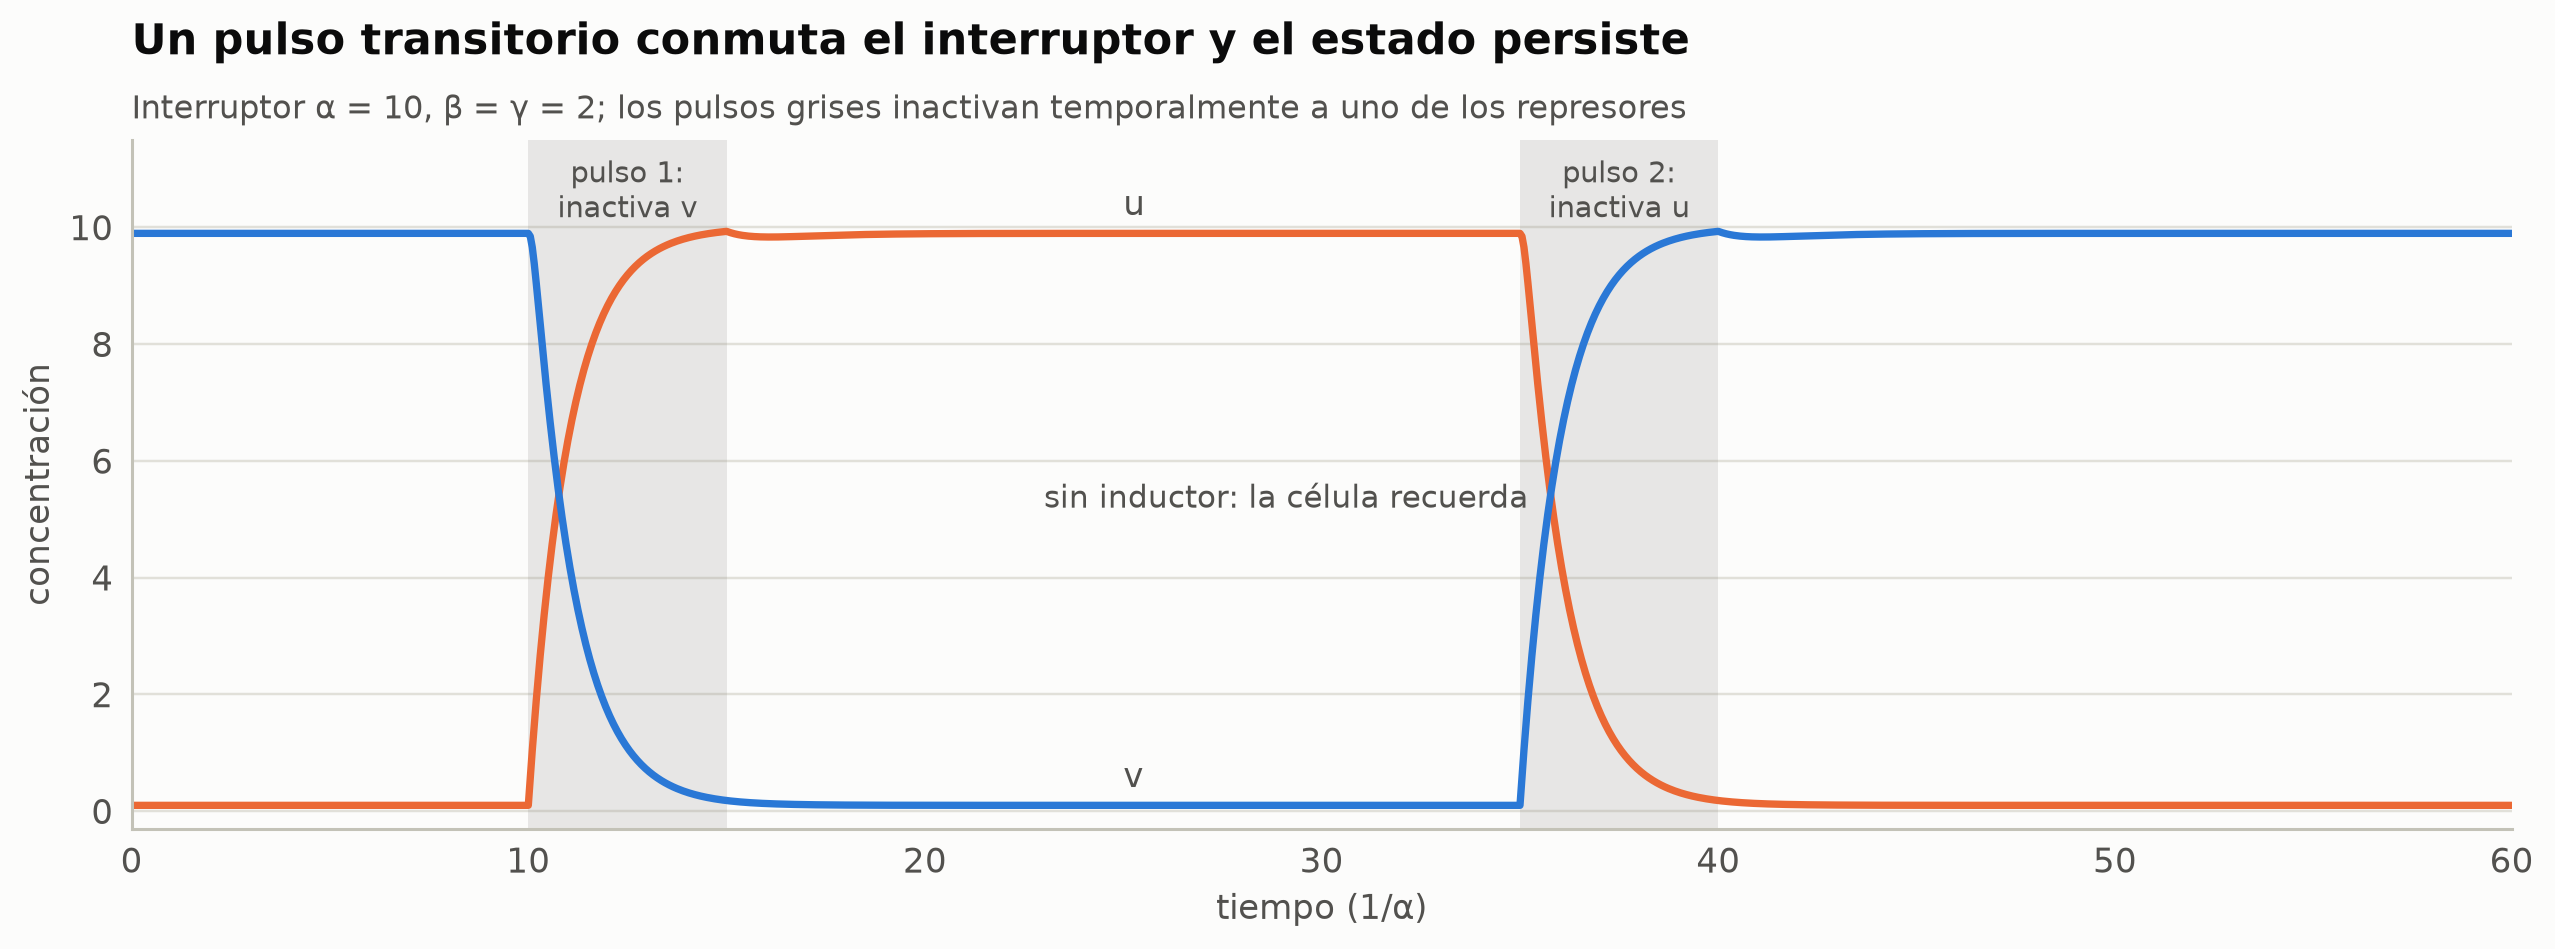

In [23]:
def toggle_pulses(_t, y, a=10.0):
    u, v = y
    rep_v = 0.0 if 10 <= _t < 15 else v       # inductor 1 inactiva a v
    rep_u = 0.0 if 35 <= _t < 40 else u       # inductor 2 inactiva a u
    return [a / (1 + rep_v**2) - u, a / (1 + rep_u**2) - v]

tp = np.linspace(0, 60, 1201)
sp_ = solve_ivp(toggle_pulses, (0, 60), [0.101, 9.899], t_eval=tp, max_step=0.05, rtol=1e-8)
fig, ax = plt.subplots(figsize=(11.5, 4.2))
for (t1, t2, lab) in ((10, 15, "pulso 1:\ninactiva v"), (35, 40, "pulso 2:\ninactiva u")):
    ax.axvspan(t1, t2, color=ec.MUTED, alpha=0.18, lw=0)
    ax.text((t1 + t2) / 2, 11.2, lab, ha="center", va="top", fontsize=9.5, color=ec.INK_2)
ax.plot(tp, sp_.y[0], color=ec.ORANGE, lw=2.4)
ax.plot(tp, sp_.y[1], color=ec.BLUE, lw=2.4)
ax.annotate("u", (25, sp_.y[0][500]), xytext=(0, 6), textcoords="offset points", color=ec.INK_2, fontsize=11)
ax.annotate("v", (25, sp_.y[1][500]), xytext=(0, 6), textcoords="offset points", color=ec.INK_2, fontsize=11)
ax.text(23, 5.2, "sin inductor: la célula recuerda", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 60); ax.set_ylim(-0.3, 11.5); ax.set_xlabel("tiempo (1/α)"); ax.set_ylabel("concentración")
ec.title(ax, "Un pulso transitorio conmuta el interruptor y el estado persiste",
         "Interruptor α = 10, β = γ = 2; los pulsos grises inactivan temporalmente a uno de los represores")
plt.show()

> 🔎 **Qué observamos.** Durante el pulso 1, $u$ se dispara y reprime a $v$; al retirar el inductor el sistema queda al
> otro lado de la separatriz y **se queda** en «U encendido» durante veinte unidades de tiempo sin ninguna señal. El
> pulso 2 lo devuelve. Así funcionaba el interruptor sintético de Gardner et al., y así funcionan, con más piezas, las
> decisiones celulares irreversibles como la diferenciación.

### 🎛️ Plano de fases interactivo: aparezca y desaparezca la memoria

Mueva el deslizador para cambiar la fuerza de los promotores $\alpha=\alpha_1=\alpha_2$ (con $\beta=\gamma=2$). Al pasar
el ratón por un punto fijo verá sus coordenadas, los autovalores del jacobiano y su tipo; sobre una trayectoria, su
estado final.

> 🤔 **Antes de mover el deslizador, prediga.** ¿Qué le pasa a la silla cuando $\alpha$ baja de 2? ¿Y a las
> trayectorias que empiezan a ambos lados de la diagonal?

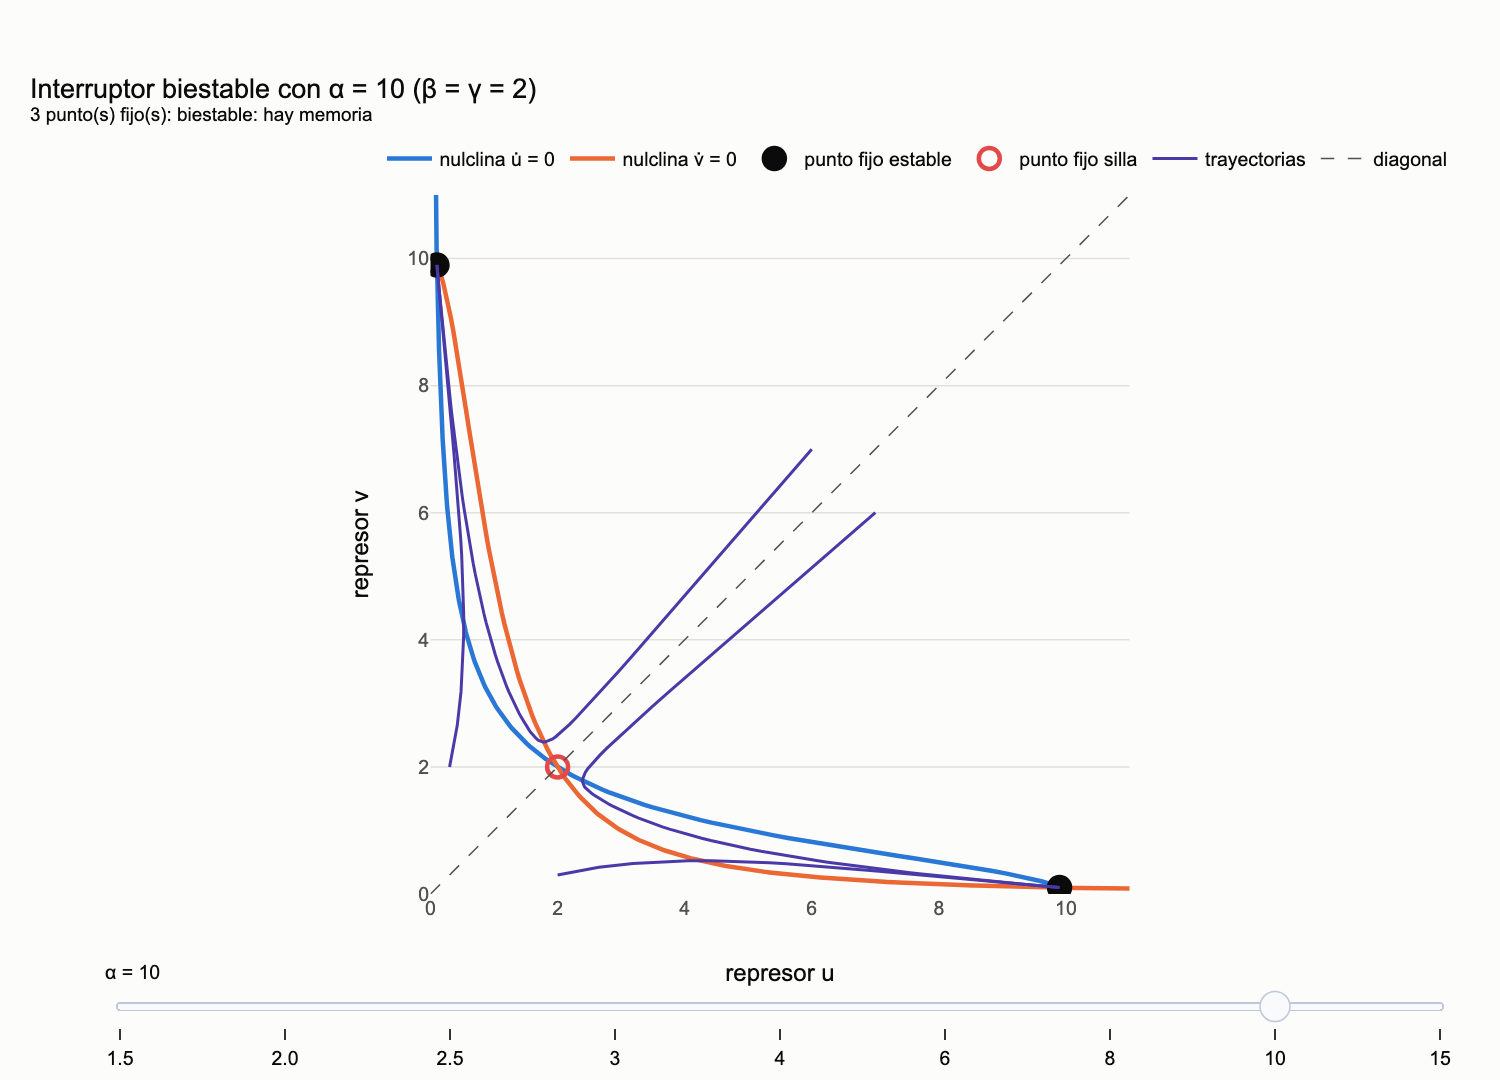

In [24]:
alist = [1.5, 2.0, 2.5, 3, 4, 6, 8, 10, 15]
starts = [(0.3, 2.0), (2.0, 0.3), (6.0, 7.0), (7.0, 6.0)]
vvp = np.linspace(0, 16, 400)
fig = go.Figure()
NT = 8                                 # trazas por paso (siempre el mismo número)
for a in alist:
    vis = a == 10
    fig.add_trace(go.Scatter(x=a / (1 + vvp**2), y=vvp, mode="lines", line=dict(color=ec.BLUE, width=3),
                             name="nulclina u̇ = 0", visible=vis, legendgroup="nu", showlegend=True,
                             hovertemplate="nulclina u̇=0: u = α/(1+v²)<br>u = %{x:.2f}, v = %{y:.2f}<extra></extra>"))
    fig.add_trace(go.Scatter(x=vvp, y=a / (1 + vvp**2), mode="lines", line=dict(color=ec.ORANGE, width=3),
                             name="nulclina v̇ = 0", visible=vis, legendgroup="nv", showlegend=True,
                             hovertemplate="nulclina v̇=0: v = α/(1+u²)<br>u = %{x:.2f}, v = %{y:.2f}<extra></extra>"))
    fpa = toggle_fixed_points(a, a, npts=40001)
    for kind, sym, fill in (("estable", "circle", ec.INK), ("silla", "circle-open", ec.RED)):
        sel = [p for p in fpa if p["tipo"] == kind]
        fig.add_trace(go.Scatter(
            x=[p["u"] for p in sel] or [None], y=[p["v"] for p in sel] or [None], mode="markers",
            marker=dict(symbol=sym, size=14, color=fill, line=dict(width=3, color=fill)), name=f"punto fijo {kind}",
            visible=vis, legendgroup=kind, showlegend=True,
            customdata=[[p["lam1"], p["lam2"]] for p in sel] or [[None, None]],
            hovertemplate=("<b>punto fijo " + kind + "</b><br>(u*, v*) = (%{x:.3f}, %{y:.3f})<br>λ₁ = %{customdata[0]:.2f},"
                           " λ₂ = %{customdata[1]:.2f}<br>λ = −1 ± √(ab)<extra></extra>")))
    rhs_a = toggle_rhs(a, a)
    for k, y0 in enumerate(starts):
        tr = solve_ivp(rhs_a, (0, 25), y0, t_eval=np.linspace(0, 25, 250), rtol=1e-7).y
        fig.add_trace(go.Scatter(x=tr[0], y=tr[1], mode="lines", line=dict(color=ec.VIOLET, width=2),
                                 name="trayectorias", visible=vis, legendgroup="tr", showlegend=(k == 0),
                                 hovertemplate=(f"trayectoria desde {y0}<br>estado actual u = %{{x:.2f}}, v = %{{y:.2f}}"
                                                f"<br>estado final ≈ ({tr[0, -1]:.2f}, {tr[1, -1]:.2f})<extra></extra>")))
fig.add_trace(go.Scatter(x=[0, 16], y=[0, 16], mode="lines", line=dict(dash="dash", color=ec.INK_2, width=1),
                         name="diagonal", hoverinfo="skip"))
steps = []
for i, a in enumerate(alist):
    vis = [False] * (NT * len(alist)) + [True]
    vis[NT * i:NT * (i + 1)] = [True] * NT
    nfp = len(toggle_fixed_points(a, a, npts=40001))
    steps.append(dict(method="update", label=str(a), args=[{"visible": vis},
        {"title.text": f"Interruptor biestable con α = {a} (β = γ = 2)<br><sup>{nfp} punto(s) fijo(s): "
                       f"{'biestable: hay memoria' if nfp == 3 else 'monoestable: no hay memoria'}</sup>"}]))
fig.update_layout(sliders=[dict(active=alist.index(10), steps=steps, currentvalue=dict(prefix="α = "), pad=dict(t=40))],
                  title="Interruptor biestable con α = 10 (β = γ = 2)<br><sup>3 punto(s) fijo(s): biestable: hay memoria</sup>",
                  xaxis=dict(title="represor u", range=[0, 11], constrain="domain"),
                  yaxis=dict(title="represor v", range=[0, 11], scaleanchor="x", scaleratio=1, constrain="domain"),
                  height=720, width=820, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  margin=dict(t=130, l=70, r=30, b=40))
fig.show()

> ✅ **Compruebe su comprensión.** Con $\alpha=1{,}5$ solo queda un punto fijo, en la diagonal, y las cuatro trayectorias
> van a él: la célula **olvida** de qué lado empezó. ¿Por qué los autovalores de los puntos estables se acercan a
> $-1$ cuando $\alpha$ crece? *(Porque lejos de la diagonal un represor está saturado y el otro casi ausente: $a$ o
> $b$ tienden a 0, $ab\to0$ y $\lambda\to-1$, la pura eliminación.)*

## 8. El *repressilator*: oscilaciones a partir de retroalimentación negativa

En el mismo número de *Nature* en que apareció el interruptor, Elowitz y Leibler (2000) presentaron un **oscilador
sintético**, el *repressilator*: tres represores (LacI, TetR y cI del fago $\lambda$) dispuestos en un **ciclo** en el que
cada uno reprime al siguiente. El circuito encendía y apagaba periódicamente una proteína fluorescente verde en
células individuales, con periodos de horas, más largos que el ciclo de división, de modo que el estado del oscilador
se transmitía de una generación a la siguiente; las oscilaciones eran **ruidosas**, posiblemente por fluctuaciones
estocásticas de sus componentes (volveremos a ello en la sección 9).

El modelo adimensional usual distingue el ARNm $m_i$ y la proteína $p_i$ de cada gen:

$$
\frac{dm_i}{dt}=-m_i+\frac{\alpha}{1+p_{j}^{\,n}}+\alpha_0,\qquad
\frac{dp_i}{dt}=-\beta\,(p_i-m_i),\qquad (i,j)\in\{(1,3),(2,1),(3,2)\}.
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $m_i,\ p_i$ | ARNm y proteína del gen $i$ (adimensionales); 1 = LacI, 2 = TetR, 3 = cI |
| $\alpha,\ \alpha_0$ | transcripción máxima y basal («fuga» del promotor reprimido) |
| $\beta$ | **cociente** entre la tasa de eliminación de la proteína y la del ARNm (¡otro significado de $\beta$!) |
| $n$ | coeficiente de Hill de la represión |
| $t$ | tiempo en unidades del tiempo de vida del ARNm |

**¿Por qué oscila?** Un ciclo de tres represiones es, en conjunto, una retroalimentación **negativa** (tres signos
negativos dan uno negativo) **con retraso**, porque la señal tarda en recorrer seis etapas (tres transcripciones y tres
traducciones). Piense en una ducha con un grifo lento: usted nota el agua fría, abre el caliente, pero el cambio tarda
en llegar; cuando llega, se quema, cierra, y el ciclo se repite. Si la retroalimentación es lo bastante fuerte y lenta,
el sistema «se pasa de largo» una y otra vez en lugar de asentarse.

Usamos los parámetros ilustrativos del libro: $\alpha=216$, $\alpha_0=0{,}216$, $\beta=5$, $n=2$, con estado inicial
$m=(1,0,0)$, $p=(2,1,3)$.

In [25]:
ra, ra0, rb, rn = 216.0, 0.216, 5.0, 2.0

def repressilator(_t, y, a=ra, a0=ra0, b=rb, n=rn):
    m1, m2, m3, p1, p2, p3 = y
    return [-m1 + a / (1 + p3 ** n) + a0,
            -m2 + a / (1 + p1 ** n) + a0,
            -m3 + a / (1 + p2 ** n) + a0,
            -b * (p1 - m1), -b * (p2 - m2), -b * (p3 - m3)]

tr = np.linspace(0, 60, 1201)
s_r = solve_ivp(repressilator, (0, 60), [1, 0, 0, 2, 1, 3], t_eval=tr, rtol=1e-9, atol=1e-9)
P1, P2, P3 = s_r.y[3], s_r.y[4], s_r.y[5]
pk, _ = find_peaks(P1)
pk = pk[tr[pk] > 20]
period = np.diff(tr[pk]).mean()
print(f"periodo = {period:.2f} vidas del ARNm; amplitud de p1 (t > 20): {P1[tr > 20].min():.2f} – {P1[tr > 20].max():.1f}")

periodo = 8.68 vidas del ARNm; amplitud de p1 (t > 20): 1.25 – 59.2


### Análisis de estabilidad: la condición de oscilación

Por simetría existe un punto fijo con $m_i=p_i=p^*$, donde $p^*=\alpha/(1+p^{*n})+\alpha_0$. Llamemos
$X=-f'(p^*)=\alpha n p^{*\,n-1}/(1+p^{*n})^2>0$ a la **sensibilidad** de la represión en ese punto. Linealizando,
$(\lambda+1)\,\delta m_i=-X\,\delta p_j$ y $(\lambda+\beta)\,\delta p_i=\beta\,\delta m_i$; combinándolas y recorriendo el
ciclo de tres genes,

$$
\left[\frac{(\lambda+1)(\lambda+\beta)}{\beta}\right]^3=-X^3
\;\Longrightarrow\;
\frac{(\lambda+1)(\lambda+\beta)}{\beta}\in\left\{-X,\;X e^{i\pi/3},\;X e^{-i\pi/3}\right\}.
$$

La raíz real $-X$ solo da autovalores con parte real negativa. Las complejas pueden cruzar el eje imaginario:
sustituyendo $\lambda=i\omega$ y separando parte real e imaginaria se obtiene el criterio.

**Condición de oscilación del *repressilator*.** El punto fijo simétrico es inestable, y el sistema oscila, si y solo si

$$
\frac{(\beta+1)^2}{\beta}<\frac{3X^2}{4-2X}\qquad\text{o bien}\qquad X\ge2.
$$

| Símbolo | Significado |
|---|---|
| $p^*$ | nivel de proteína (y de ARNm) en el punto fijo simétrico |
| $X$ | pendiente, cambiada de signo, de la función de represión en el punto fijo |
| $(\beta+1)^2/\beta$ | término que vale como mínimo 4, cuando $\beta=1$: oscilar es más fácil si ARNm y proteína viven lo mismo |

Es la misma condición que publicaron Elowitz y Leibler, que definen $X$ con el signo de la pendiente (negativo) y
escriben por eso $4+2X$. Comprobémosla con los números del libro y contra los autovalores del jacobiano completo de
$6\times6$.

In [26]:
def rep_fixed_point(a=ra, a0=ra0, n=rn):
    p = brentq(lambda q: q - a / (1 + q ** n) - a0, 0, a + a0 + 1)
    X = a * n * p ** (n - 1) / (1 + p ** n) ** 2
    return p, X

def rep_jacobian(X, b):
    J = np.zeros((6, 6))
    for i in range(3):
        J[i, i], J[i, 3 + (i - 1) % 3], J[3 + i, 3 + i], J[3 + i, i] = -1, -X, -b, b
    return J

def oscillates(X, b):
    return X >= 2 or (b + 1) ** 2 / b < 3 * X ** 2 / (4 - 2 * X)

pst, Xr = rep_fixed_point()
lhs, rhs = (rb + 1) ** 2 / rb, 3 * Xr ** 2 / (4 - 2 * Xr)
ev = np.linalg.eigvals(rep_jacobian(Xr, rb))
print(f"p* = {pst:.3f};  X = {Xr:.3f};  (β+1)²/β = {lhs:.3f}  <  3X²/(4−2X) = {rhs:.3f}  →  oscila")
print(f"par dominante de autovalores: {ev[np.argmax(ev.real)]:.3f}  (parte real positiva: inestable)")
print(f"periodo lineal 2π/ω = {2 * np.pi / abs(ev[np.argmax(ev.real)].imag):.2f} frente al periodo simulado {period:.2f}")
mis = sum(oscillates(Xv, bv) != (np.linalg.eigvals(rep_jacobian(Xv, bv)).real.max() > 0)
          for Xv in np.linspace(0.1, 5, 40) for bv in np.logspace(-2, 2, 40))
print(f"criterio frente a autovalores: {mis} discrepancias en 1600 combinaciones de (X, β)")
p1_, X1 = rep_fixed_point(n=1.0)
print(f"n = 1: X = {X1:.3f}; 3X²/(4−2X) = {3 * X1 ** 2 / (4 - 2 * X1):.3f}  frente a  {lhs:.2f}  →  no oscila")

# Frontera de estabilidad en el plano (β, α) para n = 2 y α0 = 0
def alpha_min(b):
    L = (b + 1) ** 2 / b
    def g(la):
        a = 10 ** la
        p = brentq(lambda q: q - a / (1 + q * q), 0, a + 1)
        Xa = a * 2 * p / (1 + p * p) ** 2
        return (3 * Xa ** 2 / (4 - 2 * Xa) if Xa < 2 else 1e9) - L
    return 10 ** brentq(g, -1, 8)
betas_fr = 10 ** np.linspace(-1, 3, 81)
alpha_fr = np.array([alpha_min(b) for b in betas_fr])
print(f"frontera: α mínimo (en β = 1) = {alpha_fr.min():.2f}")

p* = 6.019;  X = 1.876;  (β+1)²/β = 7.200  <  3X²/(4−2X) = 42.738  →  oscila
par dominante de autovalores: 0.208+1.266j  (parte real positiva: inestable)
periodo lineal 2π/ω = 4.96 frente al periodo simulado 8.68
criterio frente a autovalores: 0 discrepancias en 1600 combinaciones de (X, β)
n = 1: X = 0.921; 3X²/(4−2X) = 1.178  frente a  7.20  →  no oscila
frontera: α mínimo (en β = 1) = 4.24


> 🔎 **Qué observamos.** Con los parámetros del libro, $p^*=6{,}019$ y $X=1{,}876$: el lado derecho (42,7) supera con
> creces al izquierdo (7,2), y el jacobiano tiene un par $0{,}208\pm1{,}266i$ con parte real positiva. El periodo lineal
> $2\pi/\omega\approx5$ es más corto que el simulado (8,7): el análisis lineal solo describe el **nacimiento** de la
> oscilación cerca del punto fijo; la oscilación plenamente desarrollada, con proteínas que van de 1 a 60, es fuertemente
> no lineal (el ejercicio 5 pide explicar la discrepancia). Dos consecuencias: **sin cooperatividad ($n=1$) no hay
> oscilación posible** (el lado derecho no llega a $3/2$ y el izquierdo vale al menos 4), y con $n=2$ hace falta
> $\alpha>4{,}24$ incluso en el caso óptimo $\beta=1$.

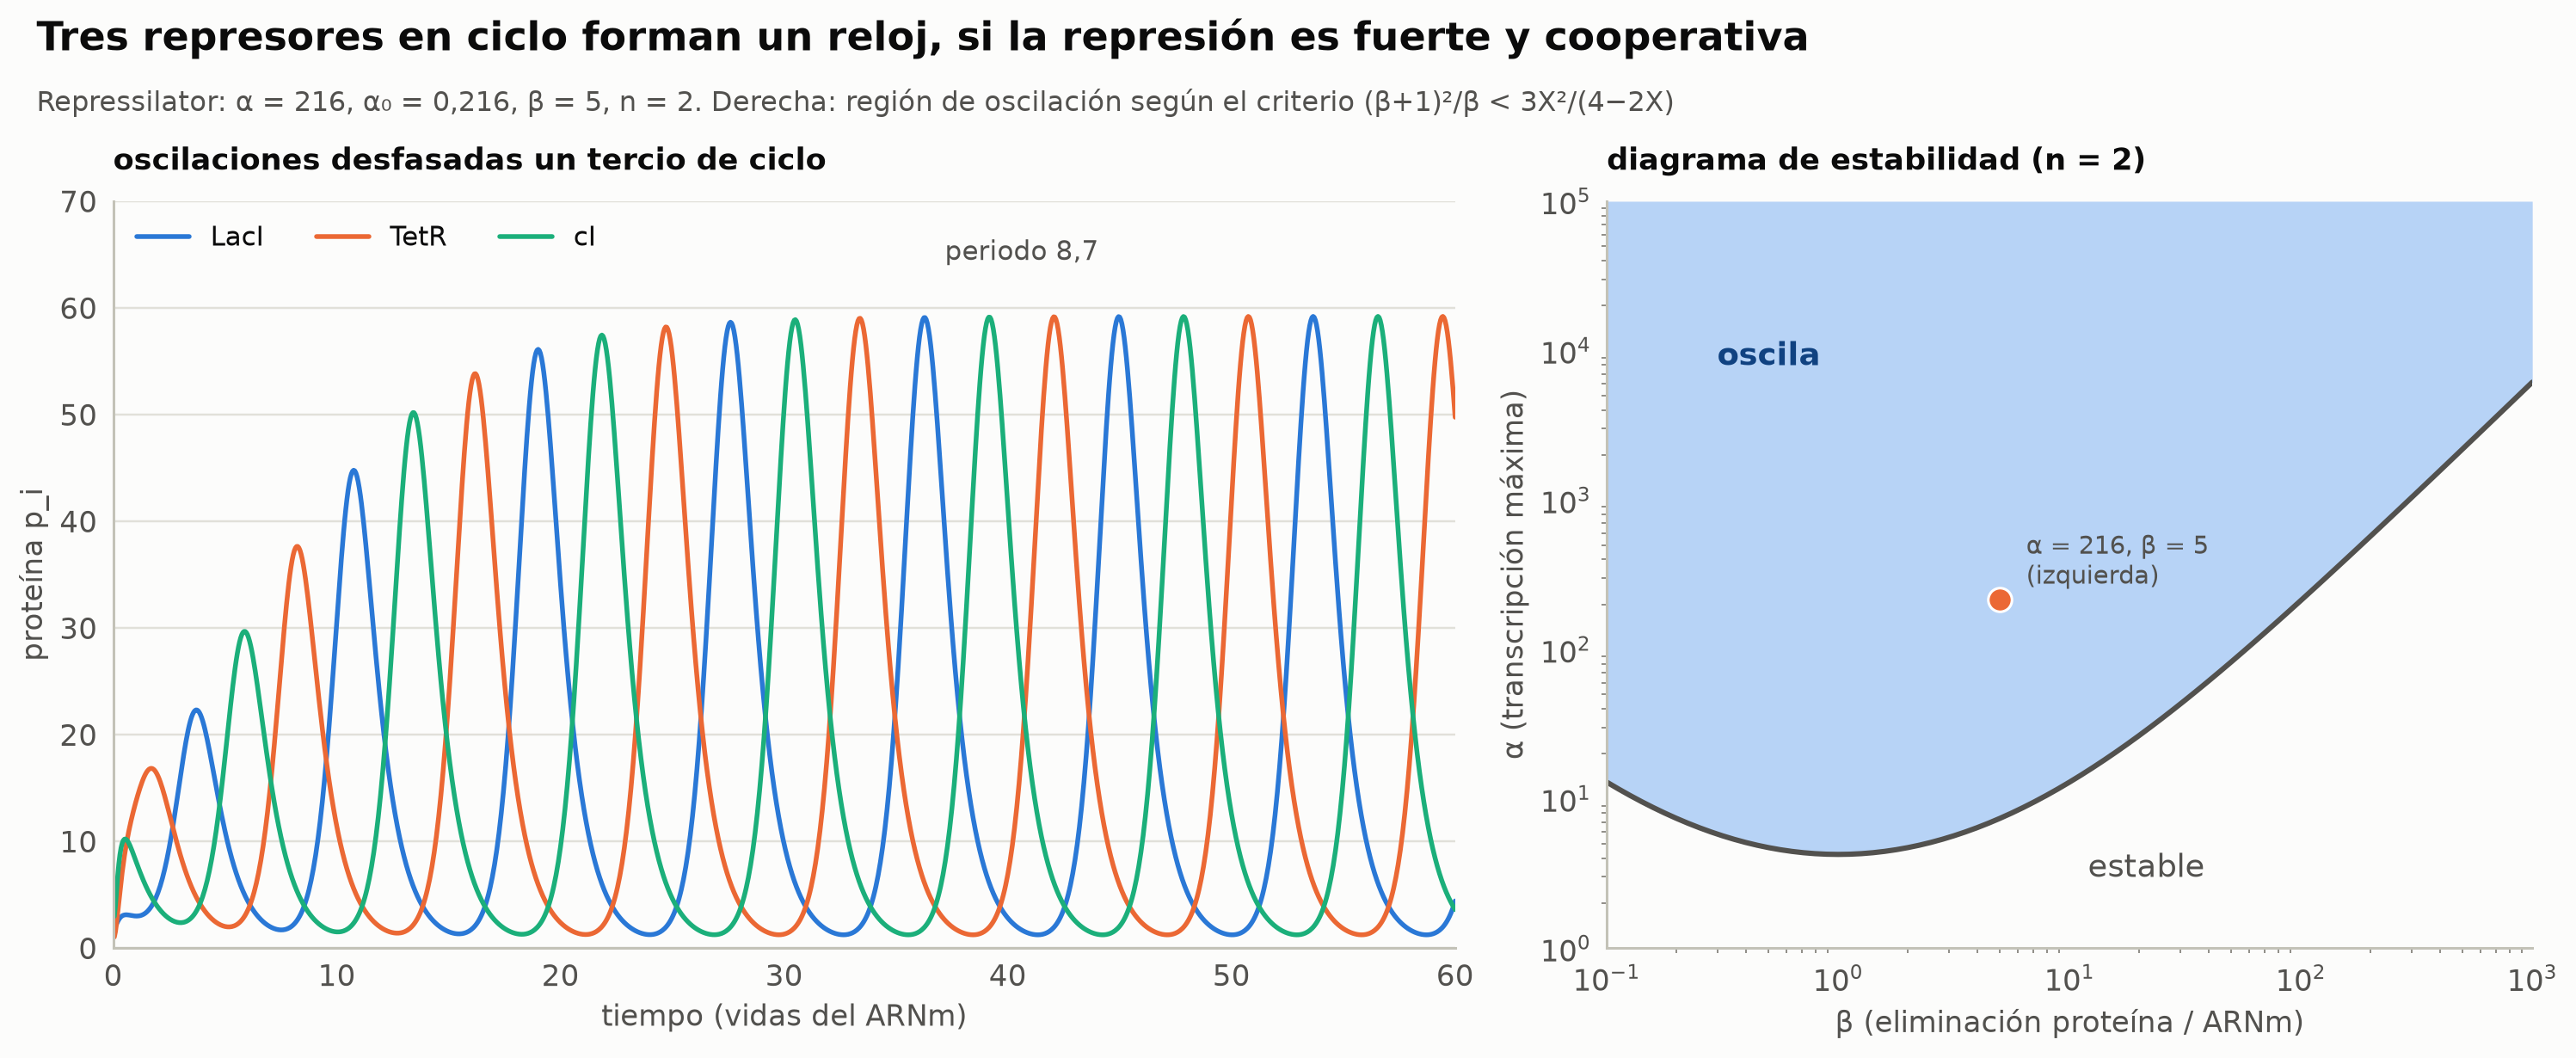

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw=dict(width_ratios=[1.45, 1]))
ax = axes[0]
for P, c, name in ((P1, ec.BLUE, "LacI"), (P2, ec.ORANGE, "TetR"), (P3, ec.AQUA, "cI")):
    ax.plot(tr, P, color=c, lw=1.8, label=name)
ax.legend(loc="upper left", ncol=3, frameon=False)
t_a, t_b = tr[pk[1]], tr[pk[2]]
ax.annotate("", xy=(t_b, 63), xytext=(t_a, 63), arrowprops=dict(arrowstyle="<->", color=ec.INK_2))
ax.text((t_a + t_b) / 2, 64.5, f"periodo {period:.1f}".replace(".", ","), ha="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 60); ax.set_ylim(0, 70); ax.set_xlabel("tiempo (vidas del ARNm)"); ax.set_ylabel("proteína p_i")
ax.set_title("oscilaciones desfasadas un tercio de ciclo", loc="left", fontsize=11.5)
ax = axes[1]
ax.fill_between(betas_fr, alpha_fr, 1e5, color=ec.SEQ_BLUE[1], lw=0)
ax.plot(betas_fr, alpha_fr, color=ec.INK_2, lw=2)
ax.plot(5, 216, "o", color=ec.ORANGE, ms=9, mec="white")
ax.annotate("α = 216, β = 5\n(izquierda)", (5, 216), xytext=(10, 6), textcoords="offset points", fontsize=9.5, color=ec.INK_2)
ax.text(0.3, 8000, "oscila", fontsize=12, color=ec.SEQ_BLUE[-2], fontweight="bold")
ax.text(12, 3, "estable", fontsize=12, color=ec.INK_2)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.1, 1000); ax.set_ylim(1, 1e5); ax.grid(False)
ax.set_xlabel("β (eliminación proteína / ARNm)"); ax.set_ylabel("α (transcripción máxima)")
ax.set_title("diagrama de estabilidad (n = 2)", loc="left", fontsize=11.5)
ec.fig_title(fig, "Tres represores en ciclo forman un reloj, si la represión es fuerte y cooperativa",
             "Repressilator: α = 216, α₀ = 0,216, β = 5, n = 2. Derecha: región de oscilación según el criterio (β+1)²/β < 3X²/(4−2X)")
plt.show()

> 🔎 **Qué observamos.** Tras un breve transitorio, las tres proteínas oscilan con un periodo de 8,7 unidades,
> desfasadas un tercio de ciclo: cuando LacI cae, TetR se libera, lo que reprime a cI, lo que a su vez libera a LacI. A
> la derecha, la región azul (oscilación) tiene forma de embudo: su punto más bajo está en $\beta=1$, y al alejarse de
> él hace falta cada vez más transcripción.

### 🎬 El reloj en marcha

A la izquierda, el ciclo de represores: el tamaño y la intensidad de cada nodo muestran la cantidad de proteína. A la
derecha, las series temporales a medida que avanza el tiempo.

![El repressilator en marcha: cada proteína sube cuando la que la reprime está baja, y el pico recorre el ciclo LacI → TetR → cI → LacI con un periodo de unas 8,7 vidas de ARNm](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.2_repressilator.gif)

*El repressilator en marcha: cada proteína sube cuando la que la reprime está baja, y el pico recorre el ciclo LacI → TetR → cI → LacI con un periodo de unas 8,7 vidas de ARNm*

In [28]:
from matplotlib.patches import FancyArrowPatch, Circle
fr_idx = np.linspace(np.searchsorted(tr, 15), np.searchsorted(tr, 42), 54).astype(int)
names3 = ["LacI", "TetR", "cI"]; cols3 = [ec.BLUE, ec.ORANGE, ec.AQUA]
ang = np.deg2rad([90, -30, 210]); pos3 = np.column_stack([np.cos(ang), np.sin(ang)])
Pall = np.vstack([P1, P2, P3]); pmax = Pall.max()

fig = plt.figure(figsize=(12, 4.8))
fig.set_layout_engine("none")
axg = fig.add_axes([0.02, 0.06, 0.3, 0.74]); axt = fig.add_axes([0.4, 0.14, 0.57, 0.66])
axg.set_xlim(-1.7, 1.7); axg.set_ylim(-1.55, 1.6); axg.set_aspect("equal"); axg.axis("off")
for i in range(3):     # i reprime a i+1
    a_, b_ = pos3[i], pos3[(i + 1) % 3]
    d = (b_ - a_) / np.linalg.norm(b_ - a_)
    axg.add_patch(FancyArrowPatch(a_ + 0.42 * d, b_ - 0.42 * d, arrowstyle="-[", mutation_scale=14, lw=2,
                                  color=ec.RED, connectionstyle="arc3,rad=-0.25"))
circles, labels = [], []
for i in range(3):
    c = Circle(pos3[i], 0.3, color=cols3[i]); axg.add_patch(c); circles.append(c)
    labels.append(axg.text(*pos3[i], names3[i], ha="center", va="center", fontsize=10, color="white", fontweight="bold"))
lines3 = [axt.plot([], [], color=c, lw=2)[0] for c in cols3]
dots3 = [axt.plot([], [], "o", color=c, ms=7)[0] for c in cols3]
axt.set_xlim(tr[fr_idx[0]], tr[fr_idx[-1]]); axt.set_ylim(0, 65)
axt.set_xlabel("tiempo (vidas del ARNm)"); axt.set_ylabel("proteína p_i")
axt.legend([Line2D([], [], color=c, lw=2) for c in cols3], names3, loc="upper right", ncol=3, frameon=False)
fig.text(0.02, 0.97, "El pico de represor recorre el ciclo", fontsize=14, fontweight="bold", va="top")
fig.text(0.02, 0.905, "Cada proteína reprime a la siguiente (barras rojas); α = 216, β = 5, n = 2", fontsize=10.5,
         color=ec.INK_2, va="top")

def update(f):
    k = fr_idx[f]
    for i in range(3):
        level = Pall[i, k] / pmax
        circles[i].set_radius(0.16 + 0.26 * level)
        circles[i].set_alpha(0.25 + 0.75 * level)
        lines3[i].set_data(tr[fr_idx[0]:k + 1], Pall[i, fr_idx[0]:k + 1])
        dots3[i].set_data([tr[k]], [Pall[i, k]])
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(fr_idx), interval=110, name="16.2_repressilator")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### 🎛️ Explore el diagrama de estabilidad

Cada celda del mapa es una combinación $(\beta,\alpha)$ con $n=2$ y $\alpha_0=0$. El color es la parte real del autovalor
dominante del jacobiano de $6\times6$ (rojo: inestable, oscila; azul: estable). Al pasar el ratón verá $p^*$, $X$ y los
dos lados del criterio.

> 🤔 **Antes de explorar, prediga.** Si la proteína se degradara 100 veces más rápido que el ARNm ($\beta=100$), ¿bastaría
> $\alpha=100$ para oscilar?

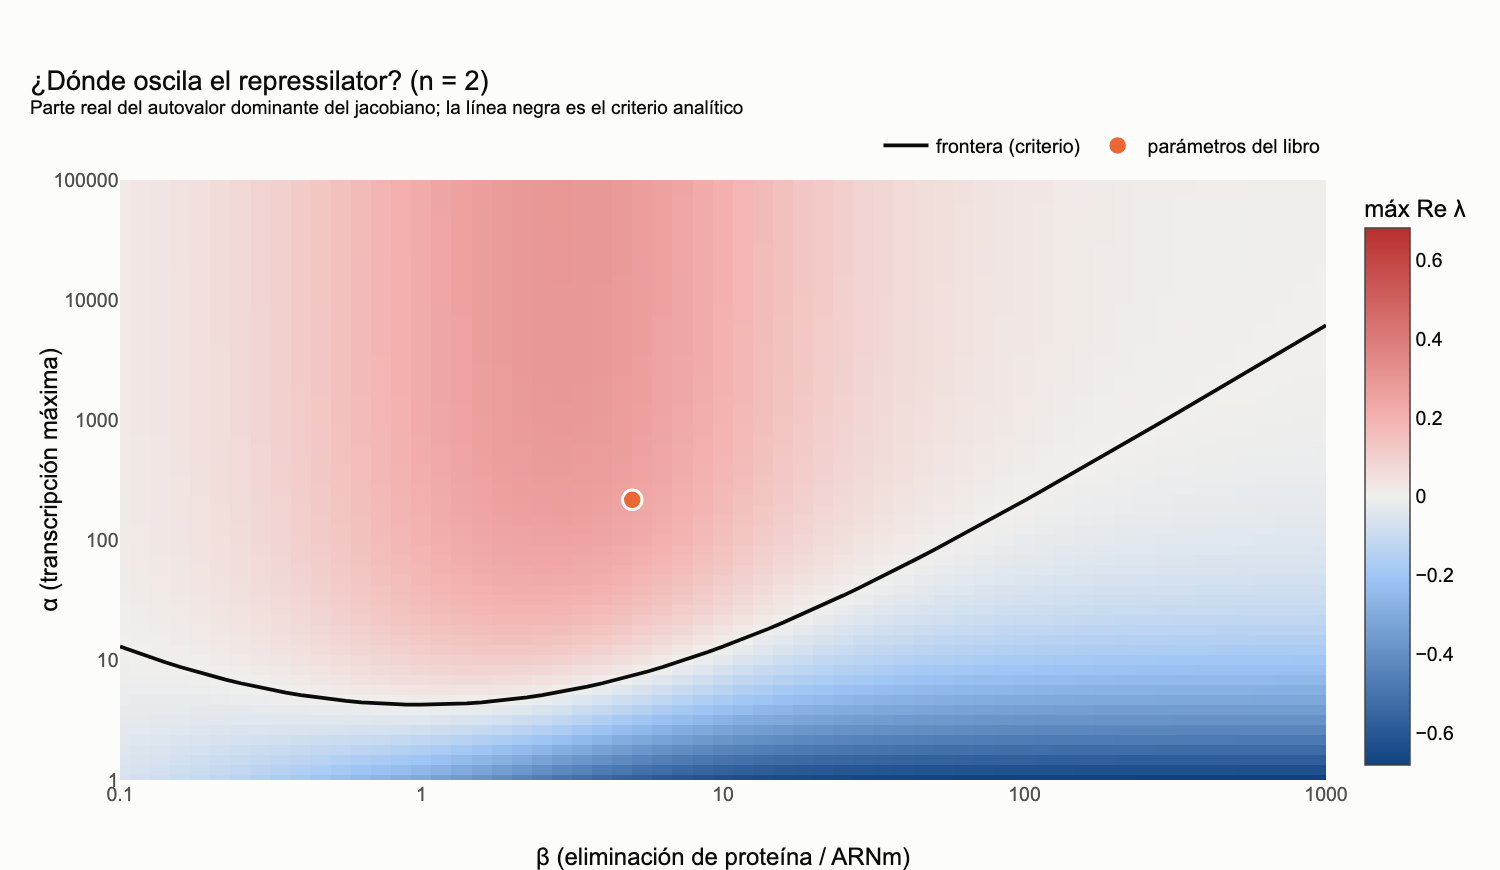

In [29]:
lb = np.linspace(-1, 3, 61); la = np.linspace(0, 5, 61)
Z = np.zeros((len(la), len(lb))); H = np.empty((len(la), len(lb)), dtype=object)
for i, la_ in enumerate(la):
    a = 10 ** la_
    p = brentq(lambda q: q - a / (1 + q * q), 0, a + 1)
    Xa = a * 2 * p / (1 + p * p) ** 2
    for j, lb_ in enumerate(lb):
        b = 10 ** lb_
        Z[i, j] = np.linalg.eigvals(rep_jacobian(Xa, b)).real.max()
        rhs_ = 3 * Xa ** 2 / (4 - 2 * Xa) if Xa < 2 else float("inf")
        H[i, j] = (f"α = {a:.3g}, β = {b:.3g}<br>p* = {p:.3g}, X = {Xa:.3f}<br>(β+1)²/β = {(b + 1) ** 2 / b:.2f} vs "
                   f"3X²/(4−2X) = {rhs_:.2f}<br>máx Re λ = {Z[i, j]:+.3f} → {'OSCILA' if Z[i, j] > 0 else 'estable'}")
zmax = np.abs(Z).max()
fig = go.Figure(go.Heatmap(x=lb, y=la, z=Z, text=H, hovertemplate="%{text}<extra></extra>", zmid=0,
                           colorscale=[[0, "#104281"], [0.35, "#9ec5f4"], [0.5, "#f0efec"], [0.65, "#f3b0ae"], [1, "#b8302f"]],
                           colorbar=dict(title="máx Re λ")))
fig.add_trace(go.Scatter(x=np.log10(betas_fr), y=np.log10(alpha_fr), mode="lines", line=dict(color=ec.INK, width=2.5),
                         name="frontera (criterio)", hovertemplate="frontera: β = %{customdata[0]:.3g}, α mín = "
                         "%{customdata[1]:.3g}<extra></extra>", customdata=np.column_stack([betas_fr, alpha_fr])))
fig.add_trace(go.Scatter(x=[np.log10(5)], y=[np.log10(216)], mode="markers", marker=dict(size=13, color=ec.ORANGE,
                         line=dict(color="white", width=2)), name="parámetros del libro",
                         hovertemplate="α = 216, β = 5 (libro)<br>autovalores 0,208 ± 1,266i<extra></extra>"))
tick = lambda vals: dict(tickvals=vals, ticktext=[f"{10 ** v:g}" for v in vals])
fig.update_layout(title="¿Dónde oscila el repressilator? (n = 2)<br><sup>Parte real del autovalor dominante del jacobiano; "
                        "la línea negra es el criterio analítico</sup>",
                  xaxis=dict(title="β (eliminación de proteína / ARNm)", range=[-1, 3], **tick([-1, 0, 1, 2, 3])),
                  yaxis=dict(title="α (transcripción máxima)", range=[0, 5], **tick([0, 1, 2, 3, 4, 5])),
                  height=580, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  margin=dict(t=120, l=80, r=30, b=60))
fig.show()

> ✅ **Compruebe su comprensión.** Respuesta a la predicción: no. Con $\beta=100$ el lado izquierdo vale
> $101^2/100\approx102$ y hace falta $\alpha$ del orden de varios miles; en el mapa, la frontera sube al alejarse de
> $\beta=1$. En el experimento de Elowitz y Leibler, por eso, se usaron represores con **etiquetas de degradación**
> que acortan la vida de la proteína y la acercan a la del ARNm.

## 9. Ruido: cuando las moléculas son pocas

Las ecuaciones diferenciales describen **concentraciones** continuas y deterministas. Pero en una bacteria muchos
factores de transcripción están presentes en decenas de copias, y sus ARNm en unas pocas. A esas escalas cada evento de
síntesis o degradación es un suceso **aleatorio**, y dos células genéticamente idénticas en el mismo ambiente difieren.
Elowitz, Levine, Siggia y Swain (2002) construyeron cepas de *E. coli* con dos reporteros fluorescentes idénticos (cian
y amarillo) controlados por el mismo promotor. Así separaron el ruido **intrínseco** (propio de la expresión de cada
gen, que hace diferir a los dos reporteros dentro de una misma célula) del **extrínseco** (fluctuaciones de otros
componentes celulares, que los mueve juntos). Ambos contribuían sustancialmente.

### La ecuación maestra

El modelo más sencillo es un proceso de **nacimiento y muerte**: la proteína se produce a tasa $k$ y cada molécula se
degrada a tasa $\gamma$. La probabilidad $P_x(t)$ de tener exactamente $x$ moléculas cumple

$$
\frac{dP_x}{dt}=k\,P_{x-1}+\gamma\,(x+1)\,P_{x+1}-(k+\gamma x)\,P_x .
$$

| Símbolo | Significado (en esta sección) |
|---|---|
| $P_x(t)$ | probabilidad de que haya exactamente $x$ moléculas en el tiempo $t$ |
| $k$ | tasa de producción (moléculas por unidad de tiempo) |
| $\gamma$ | tasa de degradación **por molécula** (¡aquí $\gamma$ no es un exponente!) |
| $\mu=k/\gamma$ | número medio de moléculas en el estado estacionario |

**En palabras:** se llega a $x$ desde $x-1$ (una síntesis) o desde $x+1$ (una degradación), y se sale de $x$ por
cualquiera de las dos. En el estado estacionario, el flujo de $x-1$ a $x$ equilibra el de $x$ a $x-1$:
$kP_{x-1}=\gamma x P_x$, de donde $P_x=(\mu/x)P_{x-1}$ y, por inducción, $P_x=e^{-\mu}\mu^x/x!$. **Es una distribución de
Poisson**: su media coincide con la solución de la ODE, y su coeficiente de variación es

$$
\mathrm{CV}=\frac{\sigma}{\mu}=\frac{1}{\sqrt{\mu}} .
$$

**Ejemplo a mano.** Con 10 moléculas de media, $\mathrm{CV}=1/\sqrt{10}=0{,}316$: fluctuaciones típicas del 32 %. Con
10 000 moléculas, $1/100$: un 1 %. El ruido importa en los genes poco expresados.

### El algoritmo de Gillespie

Para redes más complejas la ecuación maestra no se puede resolver, pero sí se pueden generar **trayectorias exactas**.
Gillespie (1977) observó que, si el sistema está en un estado con **propensiones** $a_1,\dots,a_R$ (la probabilidad por
unidad de tiempo de que ocurra cada reacción), el tiempo hasta la siguiente reacción es exponencial con tasa
$a_0=\sum_r a_r$, y la reacción que ocurre es la $r$-ésima con probabilidad $a_r/a_0$:

$$
\tau=\frac{1}{a_0}\ln\frac{1}{u_1},\qquad
r=\min\Big\{r':\ \sum_{s\le r'}a_s> u_2\,a_0\Big\},\qquad u_1,u_2\sim\mathcal{U}(0,1).
$$

| Símbolo | Significado |
|---|---|
| $a_r$ | propensión de la reacción $r$ en el estado actual (aquí $k$ para la síntesis y $\gamma x$ para la degradación) |
| $a_0$ | suma de las propensiones |
| $\tau$ | tiempo de espera hasta la próxima reacción |
| $u_1,u_2$ | números aleatorios uniformes independientes |

Dos preguntas en cada paso: **¿cuándo?** (una exponencial) y **¿cuál?** (una ruleta con sectores proporcionales a las
propensiones). Es el código del libro:

In [30]:
def gillespie_nm(k, g, x0, T, rng):
    """Nacimiento (tasa k) y muerte (tasa g*x) de una proteína (código del libro)."""
    t, x = 0.0, x0
    ts, xs = [t], [x]
    while t < T:
        a1, a2 = k, g * x                  # propensiones
        a0 = a1 + a2
        t += rng.exponential(1 / a0)       # ¿cuándo?
        x += 1 if rng.random() * a0 < a1 else -1   # ¿cuál?
        ts.append(t)
        xs.append(x)
    return np.array(ts), np.array(xs)

k_b, g_b = 1.0, 0.1                        # media 10 moléculas
short = [gillespie_nm(k_b, g_b, 0, 100, np.random.default_rng(50 + j)) for j in range(3)]
ts, xs = gillespie_nm(k_b, g_b, 10, 20000, np.random.default_rng(7))
dt = np.diff(ts); xsx = xs[:-1]; sel = ts[:-1] > 50           # promedio ponderado por el tiempo de permanencia
hist = np.bincount(xsx[sel], weights=dt[sel], minlength=31)[:31] / dt[sel].sum()
mu = k_b / g_b
pois = np.array([math.exp(-mu) * mu ** x / math.factorial(x) for x in range(31)])
mean_t = np.sum(xsx[sel] * dt[sel]) / dt[sel].sum()
var_t = np.sum((xsx[sel] - mean_t) ** 2 * dt[sel]) / dt[sel].sum()
print(f"reacciones simuladas en T = 20000: {len(ts) - 1}")
print(f"media = {mean_t:.2f}   varianza = {var_t:.2f}   Fano = {var_t / mean_t:.3f}   CV = {math.sqrt(var_t) / mean_t:.3f}"
      f"   (teoría: 10, 10, 1, {1 / math.sqrt(10):.3f})")

reacciones simuladas en T = 20000: 39960
media = 10.05   varianza = 10.19   Fano = 1.014   CV = 0.318   (teoría: 10, 10, 1, 0.316)


> 🤔 **Antes de ver la figura, prediga.** ¿Seguirá alguna de las tres células exactamente la curva de la ODE? ¿Qué
> fracción del tiempo cree que una célula pasa con menos de 5 moléculas?

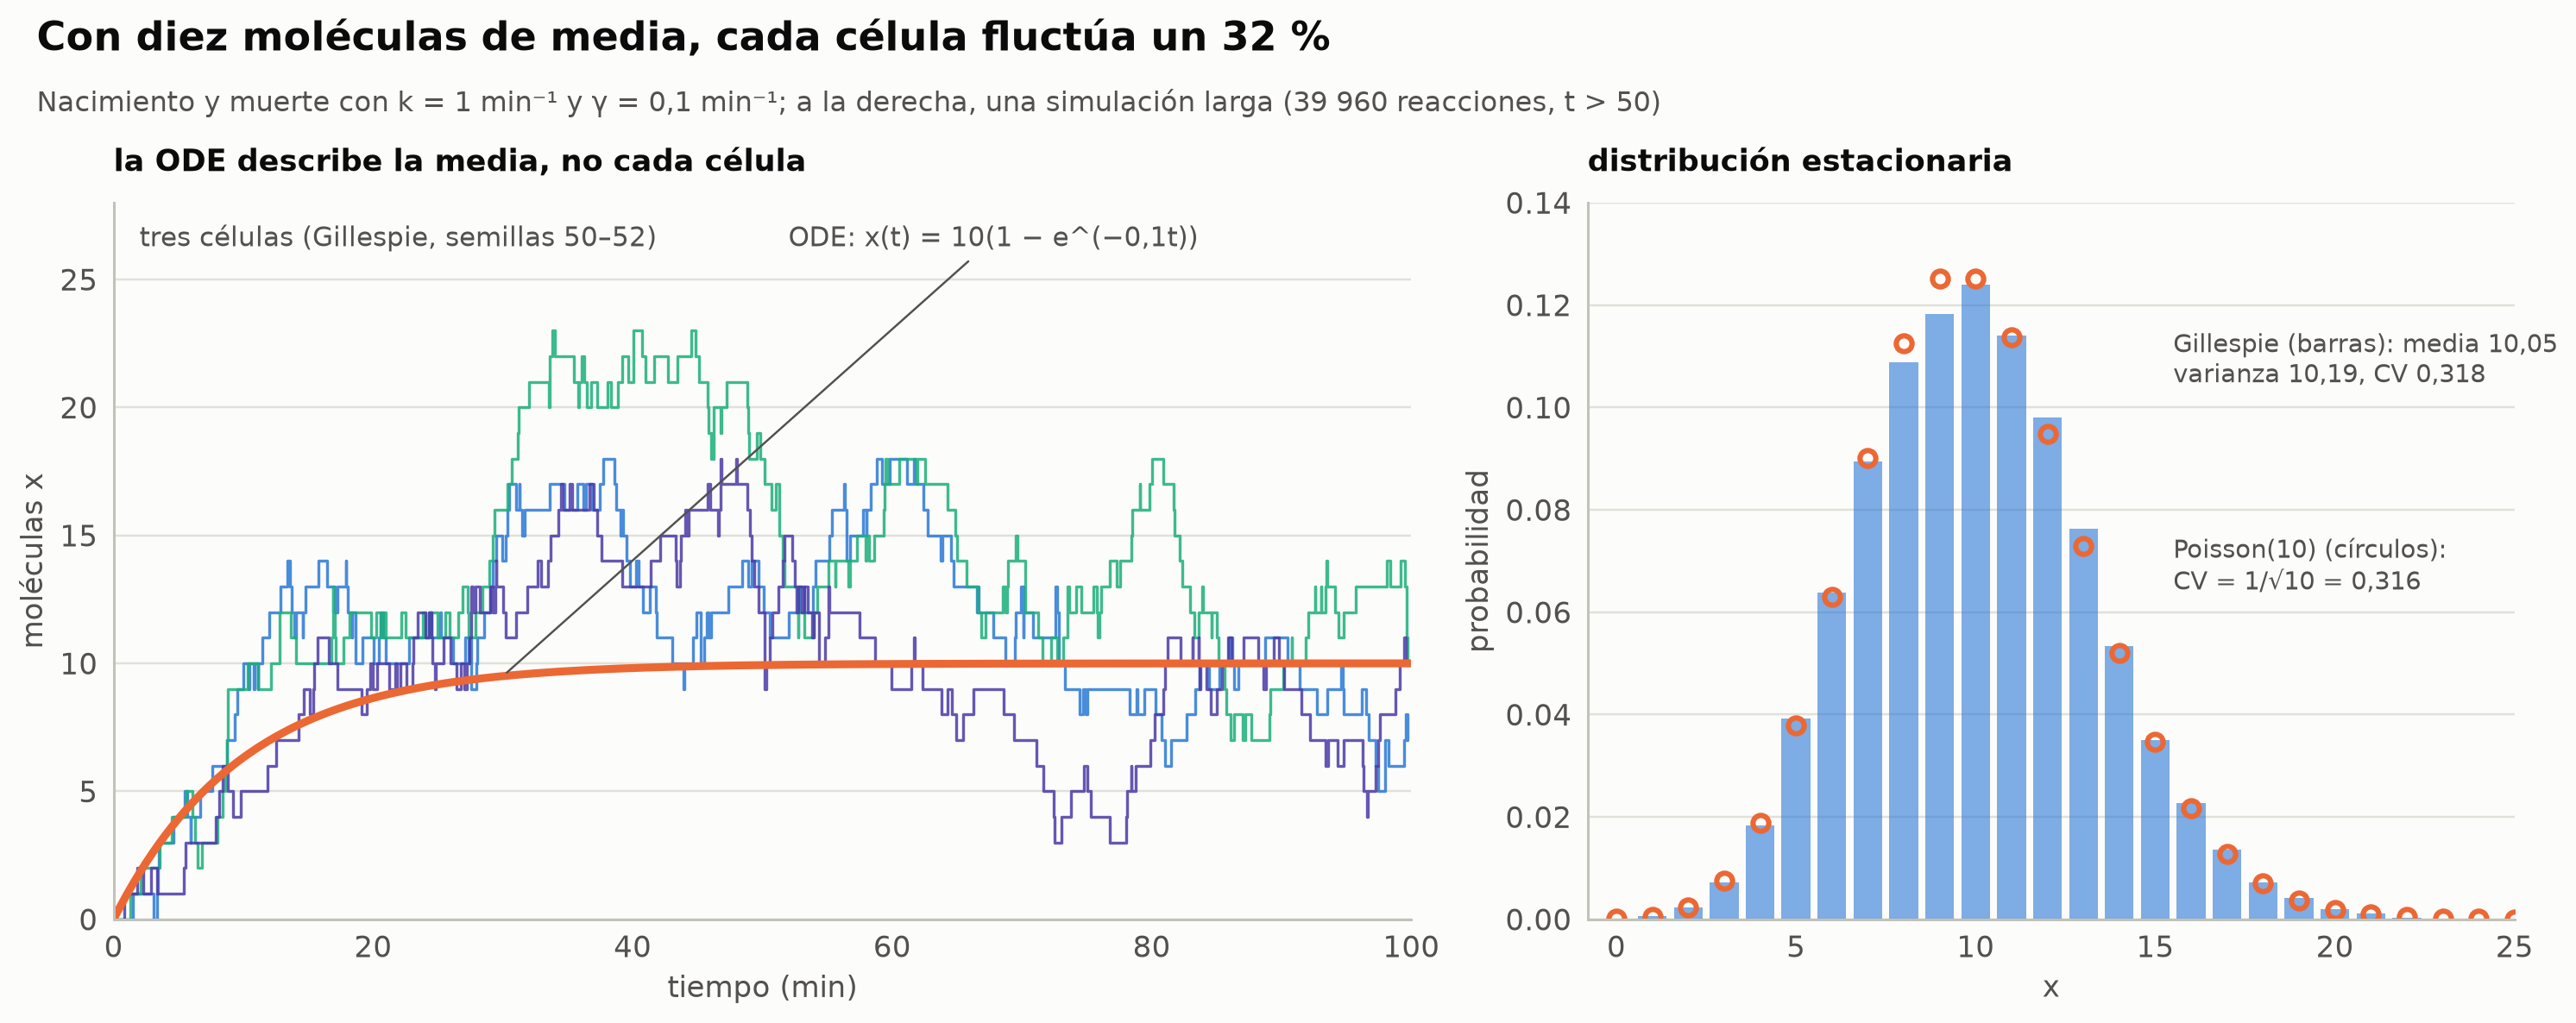

fracción del tiempo con menos de 5 moléculas: 0.029 (Poisson: 0.029)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw=dict(width_ratios=[1.4, 1]))
ax = axes[0]
for (ts_, xs_), c in zip(short, (ec.BLUE, ec.AQUA, ec.VIOLET)):
    keep = ts_ <= 100
    ax.step(ts_[keep], xs_[keep], where="post", color=c, lw=1.1, alpha=0.85)
tode = np.linspace(0, 100, 201)
ax.plot(tode, mu * (1 - np.exp(-g_b * tode)), color=ec.ORANGE, lw=3)
ax.annotate("ODE: x(t) = 10(1 − e^(−0,1t))", (30, 10 * (1 - np.exp(-3))), xytext=(52, 26.3), fontsize=10,
            color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.text(2, 26.3, "tres células (Gillespie, semillas 50–52)", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 100); ax.set_ylim(0, 28); ax.set_xlabel("tiempo (min)"); ax.set_ylabel("moléculas x")
ax.set_title("la ODE describe la media, no cada célula", loc="left", fontsize=11.5)
ax = axes[1]
ax.bar(range(31), hist, color=ec.BLUE, alpha=0.6, width=0.8)
ax.plot(range(31), pois, "o", mfc="none", mec=ec.ORANGE, mew=2, ms=6)
ax.text(15.5, 0.115, f"Gillespie (barras): media {mean_t:.2f}\nvarianza {var_t:.2f}, CV {math.sqrt(var_t) / mean_t:.3f}"
        .replace(".", ","), fontsize=9.5, color=ec.INK_2, va="top")
ax.text(15.5, 0.075, "Poisson(10) (círculos):\nCV = 1/√10 = 0,316", fontsize=9.5, color=ec.INK_2, va="top")
ax.set_xlim(-0.8, 25); ax.set_ylim(0, 0.14); ax.set_xlabel("x"); ax.set_ylabel("probabilidad")
ax.set_title("distribución estacionaria", loc="left", fontsize=11.5)
ec.fig_title(fig, "Con diez moléculas de media, cada célula fluctúa un 32 %",
             "Nacimiento y muerte con k = 1 min⁻¹ y γ = 0,1 min⁻¹; a la derecha, una simulación larga (39 960 reacciones, t > 50)")
plt.show()
print(f"fracción del tiempo con menos de 5 moléculas: {hist[:5].sum():.3f} (Poisson: {pois[:5].sum():.3f})")

> 🔎 **Qué observamos.** Ninguna célula sigue la curva naranja: cada una da saltos de una molécula y oscila de forma
> irregular alrededor de 10. La distribución a largo plazo coincide con la de Poisson: media 10,05, varianza 10,19 y
> $\mathrm{CV}=0{,}318$ frente al $0{,}316$ teórico. Una célula pasa alrededor del 3 % de su tiempo con menos de 5
> moléculas, la mitad de la media: si ese gen fuese un represor, en esos momentos el gen diana podría escaparse.

### 🎬 Cuarenta células, un mismo gen

Simulamos 40 células idénticas que empiezan sin proteína. A la derecha, el histograma de sus valores **en el instante
actual** frente a la distribución de Poisson de la ecuación maestra resuelta en ese mismo instante (para $x(0)=0$,
$P_x(t)$ es Poisson con media $10(1-e^{-0{,}1t})$).

![Cuarenta células simuladas con el algoritmo de Gillespie (k = 1, γ = 0,1): la media sigue a la ODE, pero la dispersión entre células converge a una distribución de Poisson de media 10](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-16-sistemas-redes/16.2_gillespie_celulas.gif)

*Cuarenta células simuladas con el algoritmo de Gillespie (k = 1, γ = 0,1): la media sigue a la ODE, pero la dispersión entre células converge a una distribución de Poisson de media 10*

In [32]:
cells = [gillespie_nm(k_b, g_b, 0, 60, np.random.default_rng(1000 + c)) for c in range(40)]
t_fr = np.linspace(0, 60, 51)
state = np.array([[xs_[np.searchsorted(ts_, t_, side="right") - 1] for (ts_, xs_) in cells] for t_ in t_fr])
fig = plt.figure(figsize=(12, 4.8))
fig.set_layout_engine("none")
axl = fig.add_axes([0.07, 0.13, 0.55, 0.66]); axr = fig.add_axes([0.7, 0.13, 0.27, 0.66])
tl = [axl.plot([], [], color=ec.BLUE, lw=0.7, alpha=0.35, drawstyle="steps-post")[0] for _ in cells]
axl.plot(t_fr, mu * (1 - np.exp(-g_b * t_fr)), color=ec.ORANGE, lw=2.5)
axl.text(40, 22.5, "naranja: ODE · negra: media de 40 células", color=ec.INK_2, fontsize=10, ha="center")
mean_line, = axl.plot([], [], color=ec.INK, lw=1.6, ls="--")
axl.set_xlim(0, 60); axl.set_ylim(0, 24.5); axl.set_xlabel("tiempo (min)"); axl.set_ylabel("moléculas x")
bars = axr.barh(range(25), np.zeros(25), color=ec.BLUE, alpha=0.6, height=0.8)
pois_line, = axr.plot([], [], color=ec.ORANGE, lw=2)
axr.set_ylim(0, 24); axr.set_xlim(0, 0.5); axr.set_xlabel("fracción de células"); axr.set_yticklabels([])
fig.text(0.02, 0.97, "Mismo gen, misma célula, distinto destino molecular", fontsize=14, fontweight="bold", va="top")
fig.text(0.02, 0.905, "40 trayectorias de Gillespie (azul), su media (negra discontinua) y la ODE (naranja)",
         fontsize=10.5, color=ec.INK_2, va="top")
ttl = axr.set_title("", loc="left", fontsize=10.5)

def update(f):
    t_ = t_fr[f]
    for (ts_, xs_), ln in zip(cells, tl):
        m = ts_ <= t_
        ln.set_data(np.append(ts_[m], t_), np.append(xs_[m], xs_[m][-1]))
    mean_line.set_data(t_fr[:f + 1], state[:f + 1].mean(1))
    h = np.bincount(state[f], minlength=25)[:25] / 40
    for b, v in zip(bars, h):
        b.set_width(v)
    m_t = mu * (1 - np.exp(-g_b * t_))
    xx = np.arange(25)
    pois_line.set_data([math.exp(-m_t) * m_t ** x / math.factorial(x) for x in xx], xx)
    ttl.set_text(f"t = {t_:.0f} min · media {state[f].mean():.1f}".replace(".", ","))
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(t_fr), interval=130, name="16.2_gillespie_celulas")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Ruido que decide: el interruptor estocástico

El ruido no es solo una molestia. En un sistema biestable como el interruptor de la sección 7, las fluctuaciones pueden
empujar a una célula **a través de la separatriz** y conmutar su estado sin ninguna señal externa. Así, una población
clonal puede dividirse en dos subpoblaciones con fenotipos distintos, una estrategia de **apuesta diversificada** ante
ambientes impredecibles. La ODE, que solo ve la media, predice que cada célula se queda para siempre donde empezó.

Para simularlo usamos Gillespie con cuatro reacciones (síntesis y degradación de $u$ y de $v$) y un **tamaño del
sistema** $\Omega$ que convierte concentraciones en números de moléculas: las propensiones de síntesis son
$\Omega\alpha/(1+(v/\Omega)^2)$ y $\Omega\alpha/(1+(u/\Omega)^2)$, y las de degradación, $u$ y $v$. Con $\alpha=10$, el
estado encendido tiene unas $10\,\Omega$ moléculas.

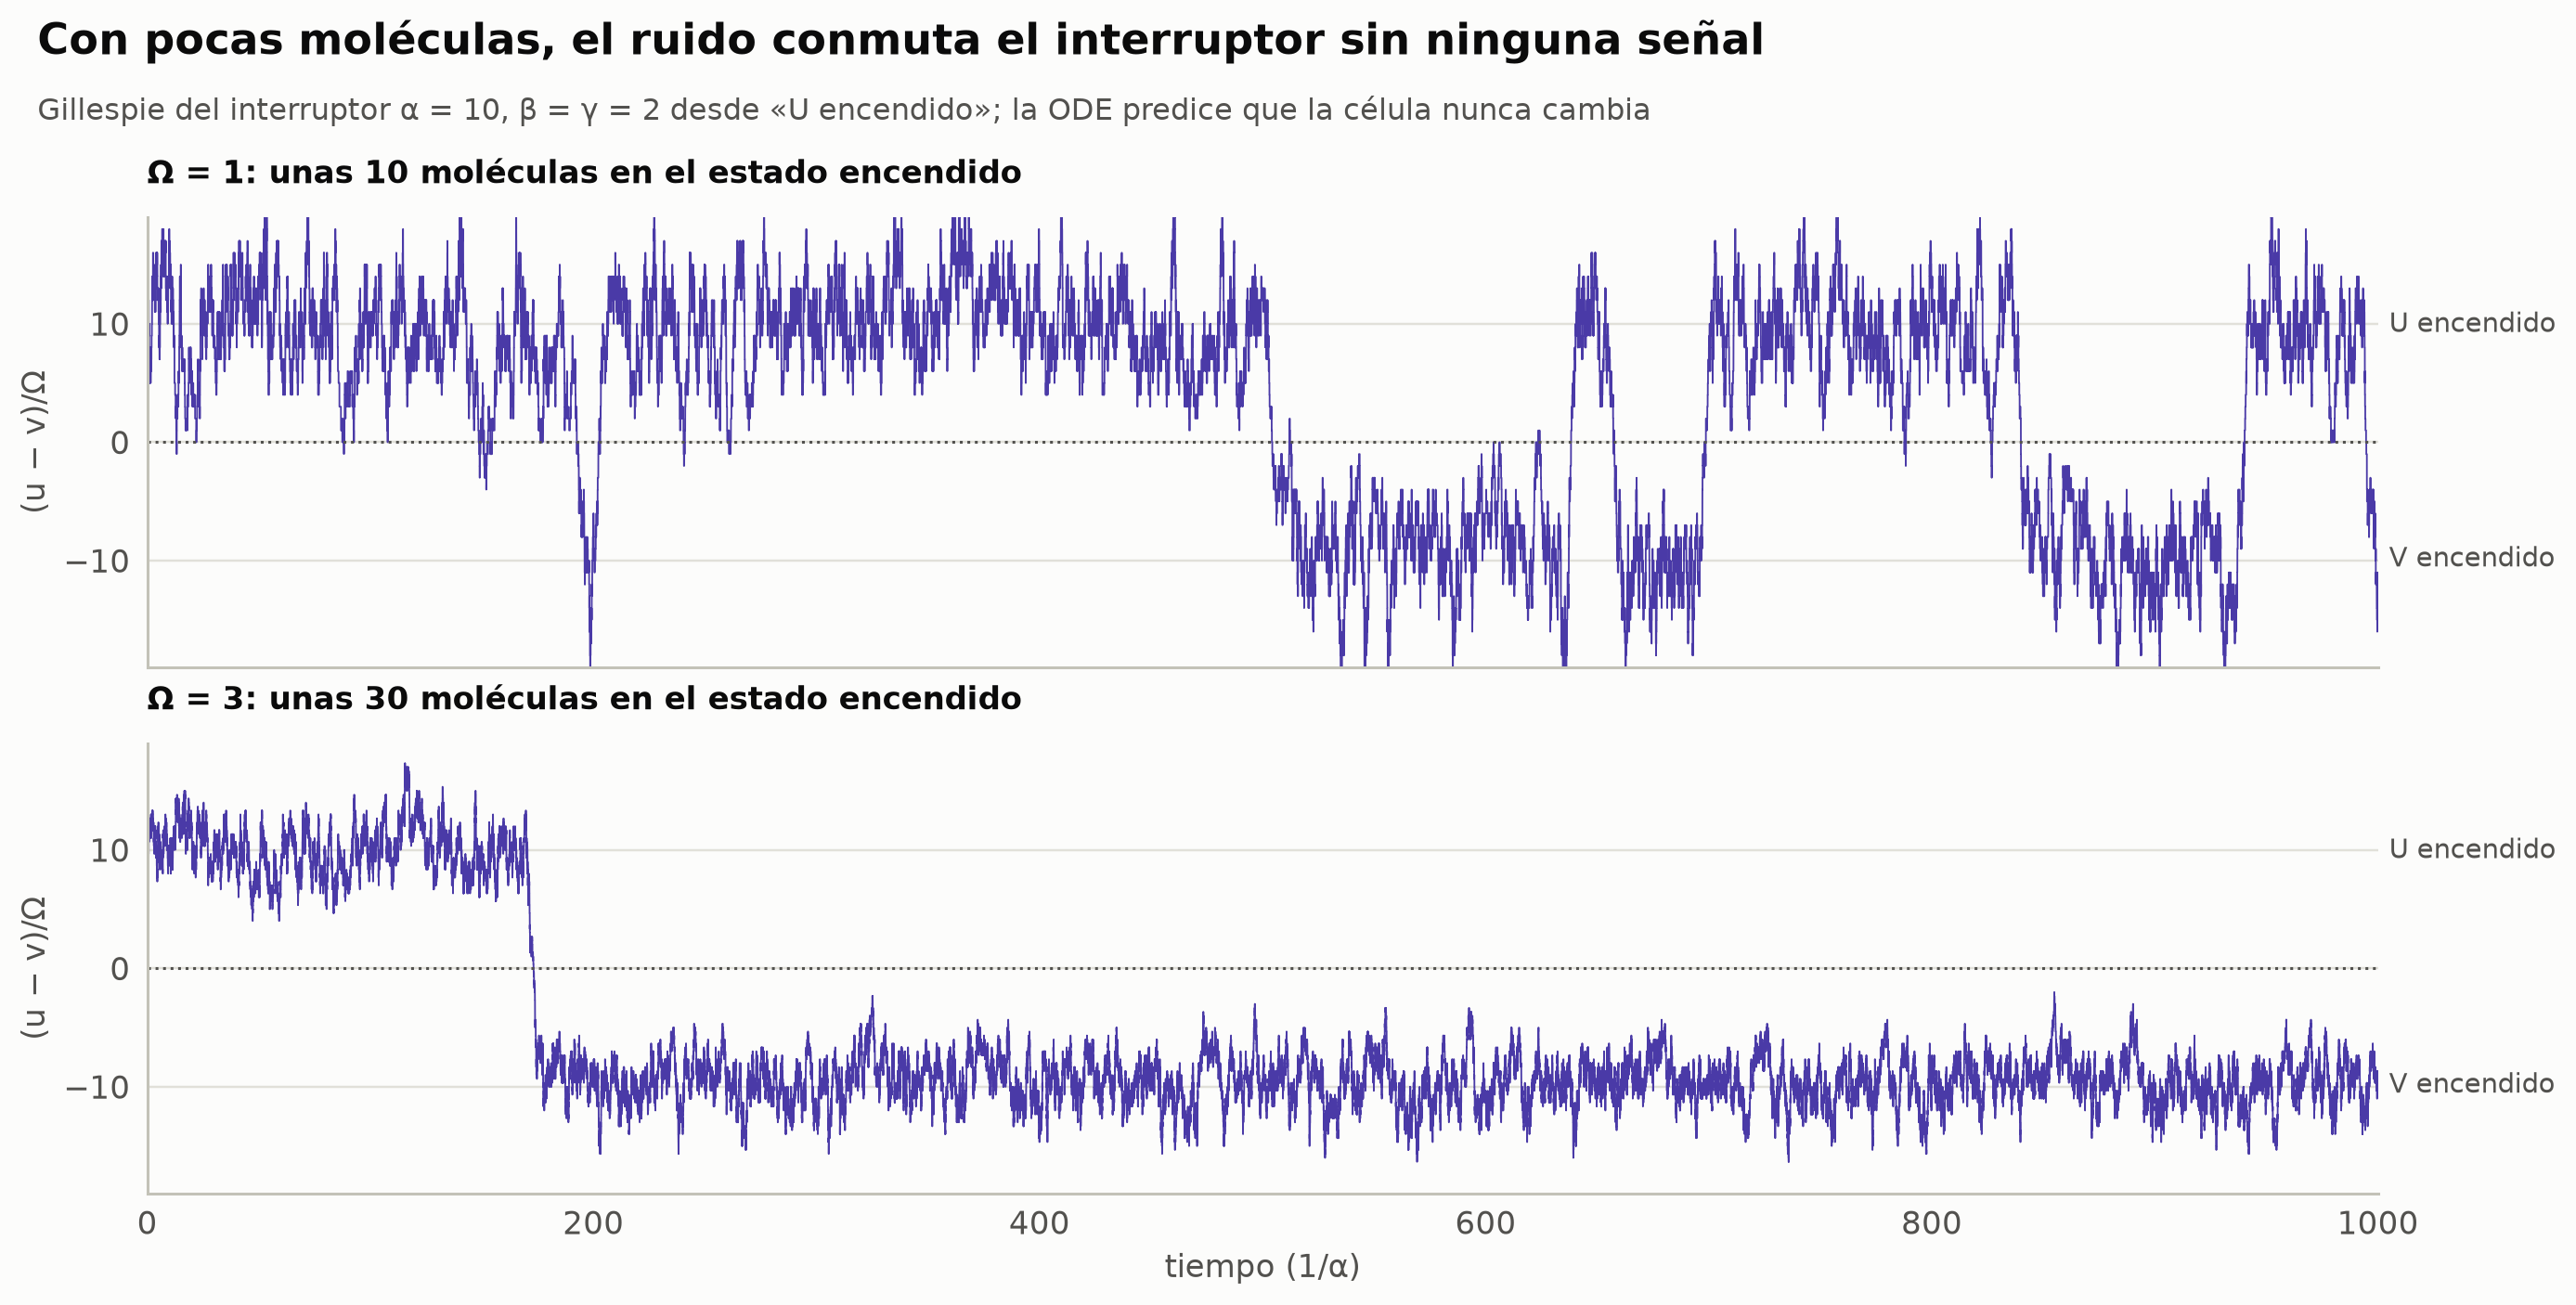

In [33]:
def ssa_toggle(Om, T, rng, a=10.0):
    """Gillespie para el interruptor (4 reacciones); empieza en «U encendido»."""
    u, v, t = int(round(10 * Om)), 0, 0.0
    ts, us, vs = [0.0], [u], [v]
    while t < T:
        a1 = Om * a / (1 + (v / Om) ** 2); a2 = u; a3 = Om * a / (1 + (u / Om) ** 2); a4 = v
        a0 = a1 + a2 + a3 + a4
        t += rng.exponential(1 / a0)
        r = rng.random() * a0
        if r < a1: u += 1
        elif r < a1 + a2: u -= 1
        elif r < a1 + a2 + a3: v += 1
        else: v -= 1
        ts.append(t); us.append(u); vs.append(v)
    return np.array(ts), np.array(us), np.array(vs)

fig, axes = plt.subplots(2, 1, figsize=(12.5, 5.6), sharex=True)
for ax, Om in zip(axes, (1, 3)):
    ts_, us_, vs_ = ssa_toggle(Om, 1000, np.random.default_rng(1))
    ax.step(ts_, (us_ - vs_) / Om, where="post", color=ec.VIOLET, lw=0.6)
    ax.axhline(0, color=ec.INK_2, ls=":", lw=1)
    ax.set_ylim(-19, 19); ax.set_ylabel("(u − v)/Ω")
    ax.text(1005, 9.9, "U encendido", fontsize=9.5, color=ec.INK_2, va="center")
    ax.text(1005, -9.9, "V encendido", fontsize=9.5, color=ec.INK_2, va="center")
    ax.set_title(f"Ω = {Om}: unas {10 * Om} moléculas en el estado encendido", loc="left", fontsize=11)
axes[1].set_xlabel("tiempo (1/α)"); axes[1].set_xlim(0, 1000)
ec.fig_title(fig, "Con pocas moléculas, el ruido conmuta el interruptor sin ninguna señal",
             "Gillespie del interruptor α = 10, β = γ = 2 desde «U encendido»; la ODE predice que la célula nunca cambia")
plt.show()

> 🔎 **Qué observamos.** Con $\Omega=1$ (unas 10 moléculas) la célula salta entre sus dos estados una y otra vez; con
> $\Omega=3$ (unas 30), los saltos se vuelven rarísimos. El tiempo medio entre conmutaciones crece **exponencialmente**
> con el tamaño del sistema: por eso las memorias celulares fiables usan muchas moléculas o retroalimentaciones
> adicionales. El ejercicio 6 le pide medirlo.

> ✅ **Compruebe su comprensión.** ¿Por qué la ODE no puede producir nunca una conmutación espontánea? *(Porque una
> trayectoria determinista que empieza en un punto fijo estable se queda en él; y las que empiezan a un lado de la
> separatriz no pueden cruzarla. Solo una perturbación, externa o aleatoria, la saca de allí.)*

## 10. Inferir la red a partir de los datos

Hasta aquí supusimos conocido el circuito. En la práctica a menudo tenemos lo contrario: una **matriz de expresión**
(genes por muestras, como las de RNA-seq del Módulo 11) y la pregunta de **qué gen regula a cuál**. La idea más ingenua
es unir los genes muy correlacionados. Pero la correlación no distingue un efecto **directo** ($X\to Z$) de uno
**indirecto** ($X\to Y\to Z$) ni de una **causa común** ($W\to X$ y $W\to Z$). Veámoslo con una cadena de tres genes.

In [34]:
rng_c = np.random.default_rng(3)
Xc = rng_c.normal(size=500)
Yc_ = 0.9 * Xc + 0.4 * rng_c.normal(size=500)       # X -> Y
Zc_ = 0.9 * Yc_ + 0.4 * rng_c.normal(size=500)      # Y -> Z   (no hay arista X -> Z)
C3 = np.corrcoef([Xc, Yc_, Zc_])
print("correlaciones en la cadena X → Y → Z (sin arista X → Z):")
print(pd.DataFrame(C3, index=list("XYZ"), columns=list("XYZ")).round(2))

correlaciones en la cadena X → Y → Z (sin arista X → Z):
      X     Y     Z
X  1.00  0.91  0.84
Y  0.91  1.00  0.92
Z  0.84  0.92  1.00


> 🔎 **Qué observamos.** $X$ y $Z$ están correlacionados en $0{,}8$ sin que exista ninguna arista entre ellos: un
> método basado solo en correlaciones pondría ahí una arista falsa.

### GENIE3: una regresión por gen

Huynh-Thu, Irrthum, Wehenkel y Geurts (2010) propusieron **GENIE3**, que descompone el problema de inferir una red de
$p$ genes en $p$ problemas de **regresión**. Para cada gen diana $j$ se predice su expresión a partir de la de todos los
reguladores candidatos con un conjunto de árboles (*Random Forests* o *Extra-Trees*, Módulo 17), y la **importancia** de
cada regulador en esa predicción se toma como evidencia de una arista:

$$
x_j = f_j\big(\mathbf{x}_{-j}\big)+\varepsilon_j,\qquad
w_{ij}=\mathrm{Imp}_i\big(\hat f_j\big),
$$

| Símbolo | Significado |
|---|---|
| $x_j$ | expresión del gen diana $j$ en cada muestra |
| $\mathbf{x}_{-j}$ | expresión de los reguladores candidatos (excluido $j$) |
| $\hat f_j$ | conjunto de árboles ajustado para predecir $x_j$ |
| $w_{ij}$ | importancia del regulador $i$: reducción total de varianza en los nodos de los árboles que lo usan |
| $\varepsilon_j$ | ruido |

Las importancias de todas las dianas se ordenan en una **lista global** de aristas candidatas. El método no supone
ninguna forma particular de regulación, capta interacciones combinatorias y no lineales, produce redes **dirigidas**
(solo los factores de transcripción pueden ser reguladores) y escala bien; fue el mejor en el desafío DREAM4 *In
Silico Multifactorial*. Este es el código del libro (añadimos `random_state` y `n_jobs` para que sea reproducible y
rápido):

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import average_precision_score, roc_auc_score

def genie3(X, reguladores, n_arboles=300, seed=0):
    """X: muestras x genes (estandarizada). Devuelve W[i, j] = importancia del regulador i para la diana j."""
    n_genes = X.shape[1]
    W = np.zeros((n_genes, n_genes))
    for j in range(n_genes):
        entradas = [i for i in reguladores if i != j]
        rf = RandomForestRegressor(n_estimators=n_arboles, max_features="sqrt", random_state=seed, n_jobs=-1)
        rf.fit(X[:, entradas], X[:, j])
        W[entradas, j] = rf.feature_importances_
    return W

### Un experimento controlado (el del libro)

Para evaluar un método hace falta conocer la respuesta. Generamos una red aleatoria de **20 genes, 6 de ellos
factores de transcripción**; cada gen recibe 1 o 2 reguladores con signo y fuerza al azar. Luego simulamos **300
estados estacionarios** bajo perturbaciones aleatorias de la expresión basal (como 300 condiciones o mutantes
distintos) y añadimos ruido de medida. Es la simulación de `generar.py` del libro, con sus semillas.

¿Cómo se evalúa? Se recorre la lista ordenada de aristas y se calcula, para cada umbral, la **precisión** (fracción de
aristas predichas que son reales) y la **exhaustividad** (fracción de aristas reales recuperadas); el **área bajo la
curva de precisión-exhaustividad** (AUPR) resume el desempeño. Una lista al azar tiene precisión igual a la fracción de
candidatas que son reales.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuánto mejor que la correlación cree que será GENIE3 en esta red, donde las
> relaciones son no lineales (sigmoides) y hay efectos indirectos?

In [36]:
def red_sintetica(seed, ng=20, ntf=6, ns=300, ruido=0.05):
    """Red al azar (ntf reguladores) y ns estados estacionarios perturbados (libro, generar.py)."""
    r2 = np.random.default_rng(seed)
    TF = list(range(ntf))
    Wt = np.zeros((ng, ng))           # Wt[i, j] != 0 : i regula j
    for j in range(ng):
        regs = r2.choice([t_ for t_ in TF if t_ != j], size=r2.integers(1, 3), replace=False)
        for i in regs:
            Wt[i, j] = r2.choice([-1, 1]) * r2.uniform(1, 2)

    def estado(basal):
        x = np.ones(ng)
        for _ in range(400):           # iteración de punto fijo amortiguada
            xn = basal + 2 / (1 + np.exp(-(Wt.T @ x - 1.5)))
            x = 0.5 * x + 0.5 * xn
        return x

    Xe = np.array([estado(r2.lognormal(0, 0.6, ng)) for _ in range(ns)])
    Xe += r2.normal(0, ruido, Xe.shape)
    return TF, Wt, (Xe - Xe.mean(0)) / Xe.std(0)

def score_network(TF, Xs, ng=20):
    S_gen = genie3(Xs, TF)
    Cc = np.abs(np.corrcoef(Xs.T))
    mask = np.zeros((ng, ng), bool)
    for j in range(ng):
        mask[[i for i in TF if i != j], j] = True
    S_cor = np.where(mask, Cc, 0)
    return S_gen, S_cor, mask

t0 = time.time()
TF3, Wt3, Xs3 = red_sintetica(3)
S_gen, S_cor, mask = score_network(TF3, Xs3)
ytrue = (Wt3[mask] != 0).astype(int)
print(f"red 3: {int((Wt3 != 0).sum())} aristas verdaderas; {mask.sum()} candidatas; azar = {ytrue.mean():.3f}")
for name, S in (("GENIE3", S_gen), ("|correlación|", S_cor)):
    print(f"{name:14s} AUPR = {average_precision_score(ytrue, S[mask]):.3f}   AUROC = {roc_auc_score(ytrue, S[mask]):.3f}")
print(f"({time.time() - t0:.1f} s)")

red 3: 32 aristas verdaderas; 114 candidatas; azar = 0.281
GENIE3         AUPR = 0.599   AUROC = 0.694
|correlación|  AUPR = 0.571   AUROC = 0.655
(3.5 s)


Reproducimos las cifras del libro para GENIE3 (AUPR 0,599; AUROC 0,694). Para la correlación obtenemos $\approx0{,}57$
(el libro da 0,573; la diferencia en la tercera cifra decimal viene de versiones de las bibliotecas). Veamos las tres
matrices: la verdadera y las dos puntuaciones.

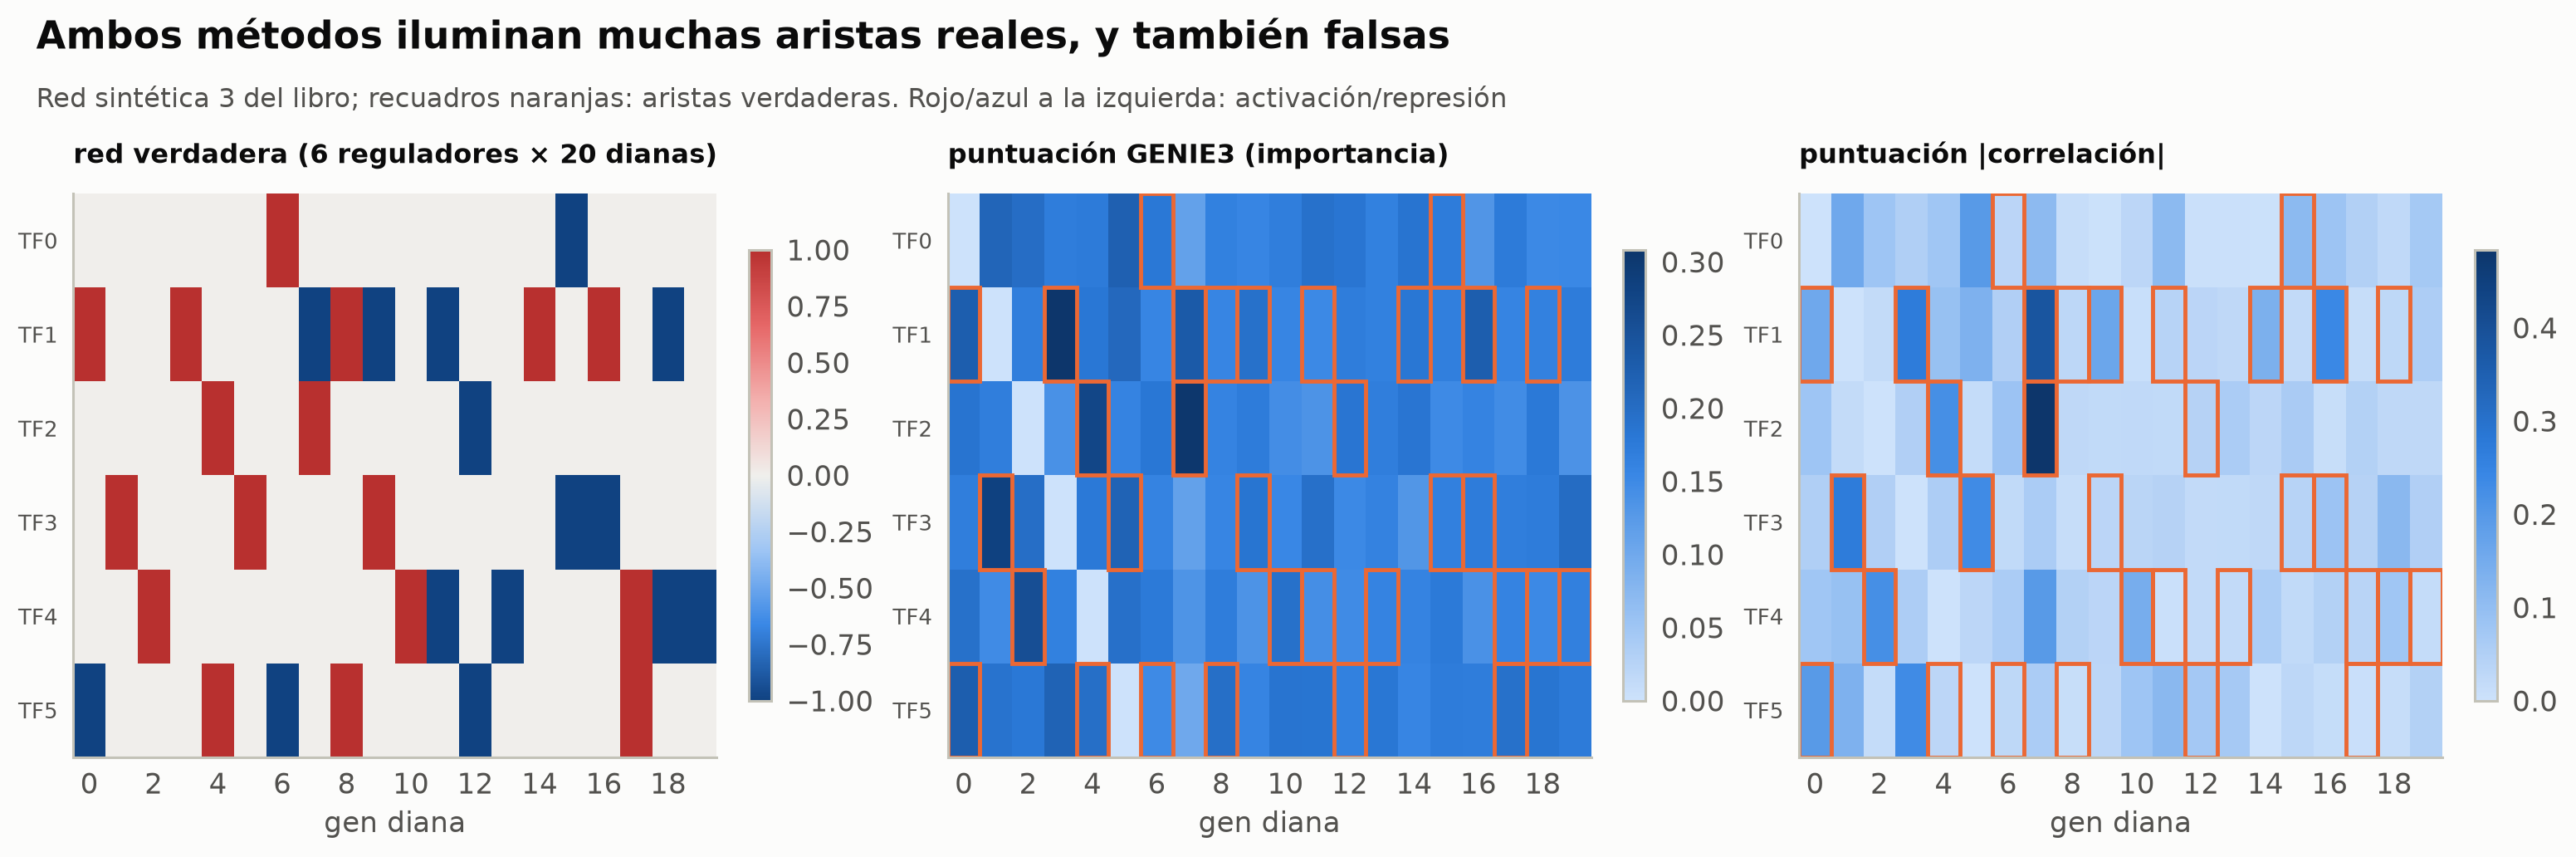

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
mats = ((np.sign(Wt3[:6]), "red verdadera (6 reguladores × 20 dianas)", ec.CMAP_DIV, -1, 1),
        (S_gen[:6], "puntuación GENIE3 (importancia)", ec.CMAP_SEQ, 0, None),
        (S_cor[:6], "puntuación |correlación|", ec.CMAP_SEQ, 0, None))
for ax, (M, ttl, cm, vmin, vmax) in zip(axes, mats):
    im = ax.imshow(M, cmap=cm, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(ttl, loc="left", fontsize=10.5)
    ax.set_yticks(range(6)); ax.set_yticklabels([f"TF{i}" for i in range(6)], fontsize=8.5)
    ax.set_xticks(range(0, 20, 2)); ax.set_xlabel("gen diana"); ax.grid(False)
    for i, j in zip(*np.nonzero(Wt3[:6])):
        if ax is not axes[0]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec=ec.ORANGE, lw=1.6))
    fig.colorbar(im, ax=ax, shrink=0.8)
ec.fig_title(fig, "Ambos métodos iluminan muchas aristas reales, y también falsas",
             "Red sintética 3 del libro; recuadros naranjas: aristas verdaderas. Rojo/azul a la izquierda: activación/represión")
plt.show()

### 🎛️ Curvas de precisión-exhaustividad interactivas

Cada punto es un corte de la lista ordenada. Al pasar el ratón verá el puesto $k$, la arista que entra en la lista en ese
puesto (¿real o falsa?), y la precisión y exhaustividad acumuladas.

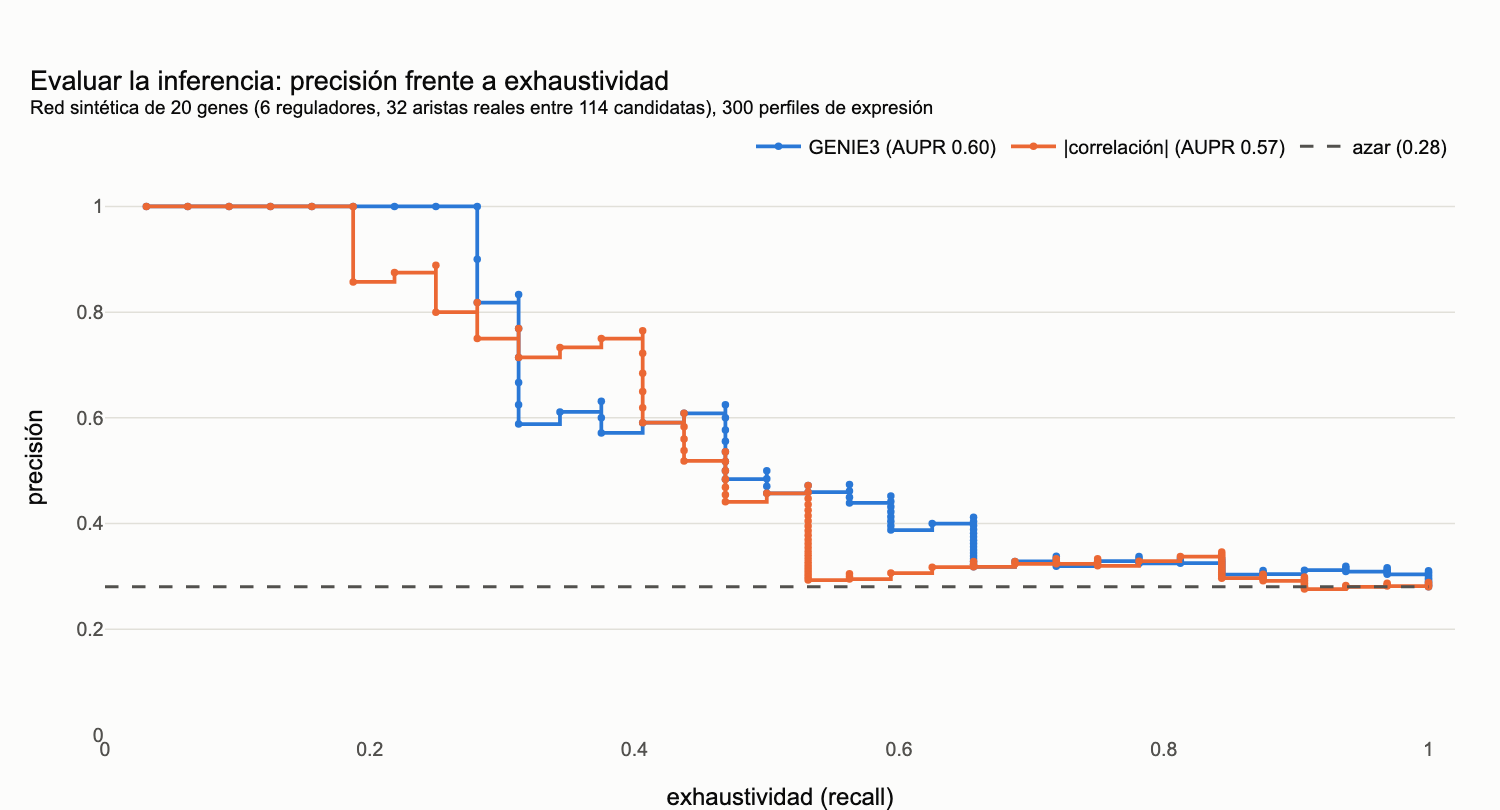

In [38]:
def pr_path(S, name):
    ii, jj = np.nonzero(mask)
    sc = S[ii, jj]; order = np.argsort(-sc, kind="stable")
    real = (Wt3[ii[order], jj[order]] != 0)
    tp = np.cumsum(real); k = np.arange(1, len(real) + 1)
    prec, rec = tp / k, tp / real.sum()
    txt = [f"puesto {kk}: TF{ii[o]} → gen {jj[o]} ({'real ✔' if r else 'falsa ✘'})<br>puntuación {sc[o]:.3f}"
           for kk, o, r in zip(k, order, real)]
    return prec, rec, txt

fig = go.Figure()
for S, name, c in ((S_gen, "GENIE3", ec.BLUE), (S_cor, "|correlación|", ec.ORANGE)):
    prec, rec, txt = pr_path(S, name)
    ap = average_precision_score(ytrue, S[mask])
    fig.add_trace(go.Scatter(x=rec, y=prec, mode="lines+markers", line=dict(color=c, width=2.5, shape="hv"),
                             marker=dict(size=5), name=f"{name} (AUPR {ap:.2f})", text=txt,
                             hovertemplate="%{text}<br>precisión = %{y:.2f}<br>exhaustividad = %{x:.2f}<extra>" + name + "</extra>"))
fig.add_trace(go.Scatter(x=[0, 1], y=[ytrue.mean()] * 2, mode="lines", line=dict(dash="dash", color=ec.INK_2),
                         name=f"azar ({ytrue.mean():.2f})", hovertemplate="lista al azar: precisión = %{y:.3f}<extra></extra>"))
fig.update_layout(title="Evaluar la inferencia: precisión frente a exhaustividad<br><sup>Red sintética de 20 genes "
                        "(6 reguladores, 32 aristas reales entre 114 candidatas), 300 perfiles de expresión</sup>",
                  xaxis=dict(title="exhaustividad (recall)", range=[0, 1.02]),
                  yaxis=dict(title="precisión", range=[0, 1.05]), height=540,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  margin=dict(t=120, l=70, r=30, b=50))
fig.show()

> 🔎 **Qué observamos.** Ambos métodos aciertan casi siempre en los primeros puestos, pero la precisión cae rápido: a
> mitad de exhaustividad, aproximadamente la mitad de las predicciones son falsas. Recorra con el ratón los primeros
> errores de la correlación: suelen ser aristas **indirectas** (un TF que regula al regulador del gen).

### ¿Y en promedio?

Una sola red puede engañar. El libro repite el experimento en cinco redes (semillas 3 a 7). Recalcularlas todas lleva
medio minuto; por defecto cargamos los resultados guardados (calculados con este mismo código) y puede recalcularlos
poniendo `RECOMPUTE_ALL = True`.

In [39]:
RECOMPUTE_ALL = False
if RECOMPUTE_ALL:
    res = {"seeds": [], "genie3": [], "cor": [], "azar": []}
    for seed in range(3, 8):
        TF_, Wt_, Xs_ = red_sintetica(seed)
        Sg, Sc, mk = score_network(TF_, Xs_)
        yt = (Wt_[mk] != 0).astype(int)
        res["seeds"].append(seed); res["azar"].append(float(yt.mean()))
        res["genie3"].append(float(average_precision_score(yt, Sg[mk])))
        res["cor"].append(float(average_precision_score(yt, Sc[mk])))
else:
    with open(course_file("162_genie3_aupr.json")) as fh:
        res = json.load(fh)
aupr = pd.DataFrame({"red (semilla)": res["seeds"], "GENIE3": res["genie3"], "|correlación|": res["cor"],
                     "azar": res["azar"]}).round(3)
print(aupr.to_string(index=False))
for c in ("GENIE3", "|correlación|", "azar"):
    print(f"{c:14s} AUPR medio = {aupr[c].mean():.3f} ± {aupr[c].std(ddof=0):.3f}")

 red (semilla)  GENIE3  |correlación|  azar
             3   0.599          0.571 0.281
             4   0.549          0.522 0.272
             5   0.439          0.476 0.272
             6   0.613          0.670 0.254
             7   0.514          0.426 0.246
GENIE3         AUPR medio = 0.543 ± 0.063
|correlación|  AUPR medio = 0.533 ± 0.084
azar           AUPR medio = 0.265 ± 0.013


> 🔎 **Qué observamos.** En promedio, GENIE3 obtiene AUPR $\approx0{,}54\pm0{,}06$ y la correlación $\approx0{,}53\pm0{,}09$,
> ambos el **doble** de lo esperable al azar ($0{,}27$). La ventaja de GENIE3 es pequeña y **no aparece en todas las
> redes** (en las semillas 5 y 6 gana la correlación). Un resultado tan modesto no es excepcional: en el proyecto DREAM5,
> Marbach et al. (2012) evaluaron a ciegas más de 30 métodos sobre datos de *E. coli*, *S. aureus*, *S. cerevisiae* y
> datos simulados, y **ningún método fue el mejor en todos**. En cambio, **integrar** las predicciones de muchos métodos
> (la «sabiduría de las multitudes») dio un desempeño alto y robusto, con el que construyeron redes de alta confianza de
> unas 1 700 interacciones para *E. coli* y *S. aureus*, con una precisión de alrededor del 50 %.

> ⚠️ **Lo que los datos de expresión no pueden decir.** Los datos observacionales de expresión, por sí solos, rara vez
> identifican la causalidad: dos genes corregulados por un tercero no medido parecen regularse entre sí, y un factor de
> transcripción cuyo ARNm apenas cambia (porque se regula por fosforilación, como muchos reguladores de dos
> componentes) es invisible. Las **perturbaciones** (*knockouts*, CRISPRi), las **series temporales** y los datos de
> **unión al ADN** (ChIP-seq, motivos del Módulo 4 y del Módulo 13) restringen enormemente el espacio de redes
> compatibles; RegulonDB, que usamos en la sección 5, se construye precisamente así. Una red inferida es un conjunto de
> **hipótesis ordenadas por plausibilidad**, no un mapa.

> 💡 **Idea clave.** La topología dice qué **puede** hacer un circuito; los parámetros (cooperatividad, fuerzas de
> promotor, vidas medias) deciden qué **hace**. Un mismo ciclo de represores es estable u oscila según $n$, $\alpha$ y
> $\beta$.

> ✅ **Compruebe su comprensión.** ¿Por qué el AUPR «al azar» es 0,28 y no 0,5 como el AUROC al azar? *(Porque la
> precisión de una lista aleatoria es la **prevalencia**: 32 aristas reales entre 114 candidatas. El AUPR depende de la
> prevalencia; por eso siempre hay que dar la línea base junto a él.)*

## 11. Ejercicios

**Ejercicio 1 (a mano).** Una proteína estable de *E. coli* tiene $t_{1/2}$ igual a un tiempo de generación. ¿Cuál
debería ser la vida media de degradación activa para que el tiempo de respuesta sea de un décimo de generación? ¿Cuánto
debe aumentar la síntesis para conservar el nivel estacionario? Calcule los números para $\tau=30$ min.

**Ejercicio 2 (autorregulación).** Demuestre $X_{\text{est}}\approx(\beta K^n/\alpha)^{1/(n+1)}$ y compruebe
numéricamente, integrando la ecuación de la autorregulación negativa, cuánto cambia $X_{\text{est}}$ al duplicar
$\beta$ con $n=1$, 2 y 4 (use $K=0{,}01$ y $\beta=10$, $\alpha=1$).

**Ejercicio 3 (FFL).** Simule el FFL con pulsos de duración creciente (de 0,1 a 5) y grafique el máximo de $Z$ en
función de la duración. Estime la duración mínima que el circuito deja pasar (por ejemplo, la que da un máximo de $Z$
igual a la mitad del de un pulso muy largo).

**Ejercicio 4 (interruptor).** Para el interruptor simétrico con $\beta=\gamma=3$, encuentre el valor crítico de
$\alpha$ a partir del cual aparecen tres puntos fijos, generalizando el razonamiento del ejemplo del libro, y
compruébelo con `toggle_fixed_points`.

**Ejercicio 5 (*repressilator*).** Calcule la frecuencia $\omega$ del par de autovalores dominante para los parámetros
del libro y compare $2\pi/\omega$ con el periodo simulado (8,68). ¿Por qué no coinciden? Pista: simule con $\alpha$ justo
por encima de la frontera.

**Ejercicio 6 (ruido que decide).** Con `ssa_toggle`, mida el tiempo medio de conmutación espontánea del interruptor
para $\Omega=0{,}5$, 1 y 1,5 y represéntelo en escala logarítmica. ¿Cómo crece con $\Omega$?

**Ejercicio 7 (datos reales).** En la red de RegulonDB, calcule el grado de salida de cada factor de transcripción y
liste los diez reguladores **globales** con más dianas. ¿Qué fracción de los FFL tiene a uno de ellos como $X$?

In [40]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
# t1/2 = ln2/α: para dividirlo por 10 hay que multiplicar α por 10.
# α_total = α_dil + α_deg = 10 α_dil  ->  α_deg = 9 α_dil  ->  vida media activa = ln2/α_deg = τ/9.
tau = 30
a_dil = math.log(2) / tau
a_deg = 9 * a_dil
print(f"vida media de degradación activa = τ/9 = {math.log(2) / a_deg:.2f} min")
print(f"t1/2 nuevo = {math.log(2) / (a_dil + a_deg):.1f} min (un décimo de {tau} min)")
print("para conservar Y_est = β/α hay que multiplicar la síntesis por 10")

vida media de degradación activa = τ/9 = 3.33 min
t1/2 nuevo = 3.0 min (un décimo de 30 min)
para conservar Y_est = β/α hay que multiplicar la síntesis por 10


In [41]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
# Con X >> K: β/(1+(X/K)^n) ≈ β (K/X)^n = α X  ->  X^(n+1) = β K^n / α.
K_, a_ = 0.01, 1.0
for n_ in (1, 2, 4):
    xs_ = []
    for b_ in (10.0, 20.0):
        sol = solve_ivp(lambda _t, x: [b_ / (1 + (x[0] / K_) ** n_) - a_ * x[0]], (0, 50), [0], rtol=1e-9, atol=1e-12,
                        method="LSODA")
        xs_.append(sol.y[0, -1])
    print(f"n = {n_}: X_est {xs_[0]:.4f} -> {xs_[1]:.4f}  (sube {xs_[1] / xs_[0] - 1:.1%}; "
          f"aproximación 2^(1/(n+1)) - 1 = {2 ** (1 / (n_ + 1)) - 1:.1%})")

n = 1: X_est 0.3113 -> 0.4422  (sube 42.1%; aproximación 2^(1/(n+1)) - 1 = 41.4%)
n = 2: X_est 0.0997 -> 0.1257  (sube 26.1%; aproximación 2^(1/(n+1)) - 1 = 26.0%)
n = 4: X_est 0.0398 -> 0.0457  (sube 14.9%; aproximación 2^(1/(n+1)) - 1 = 14.9%)


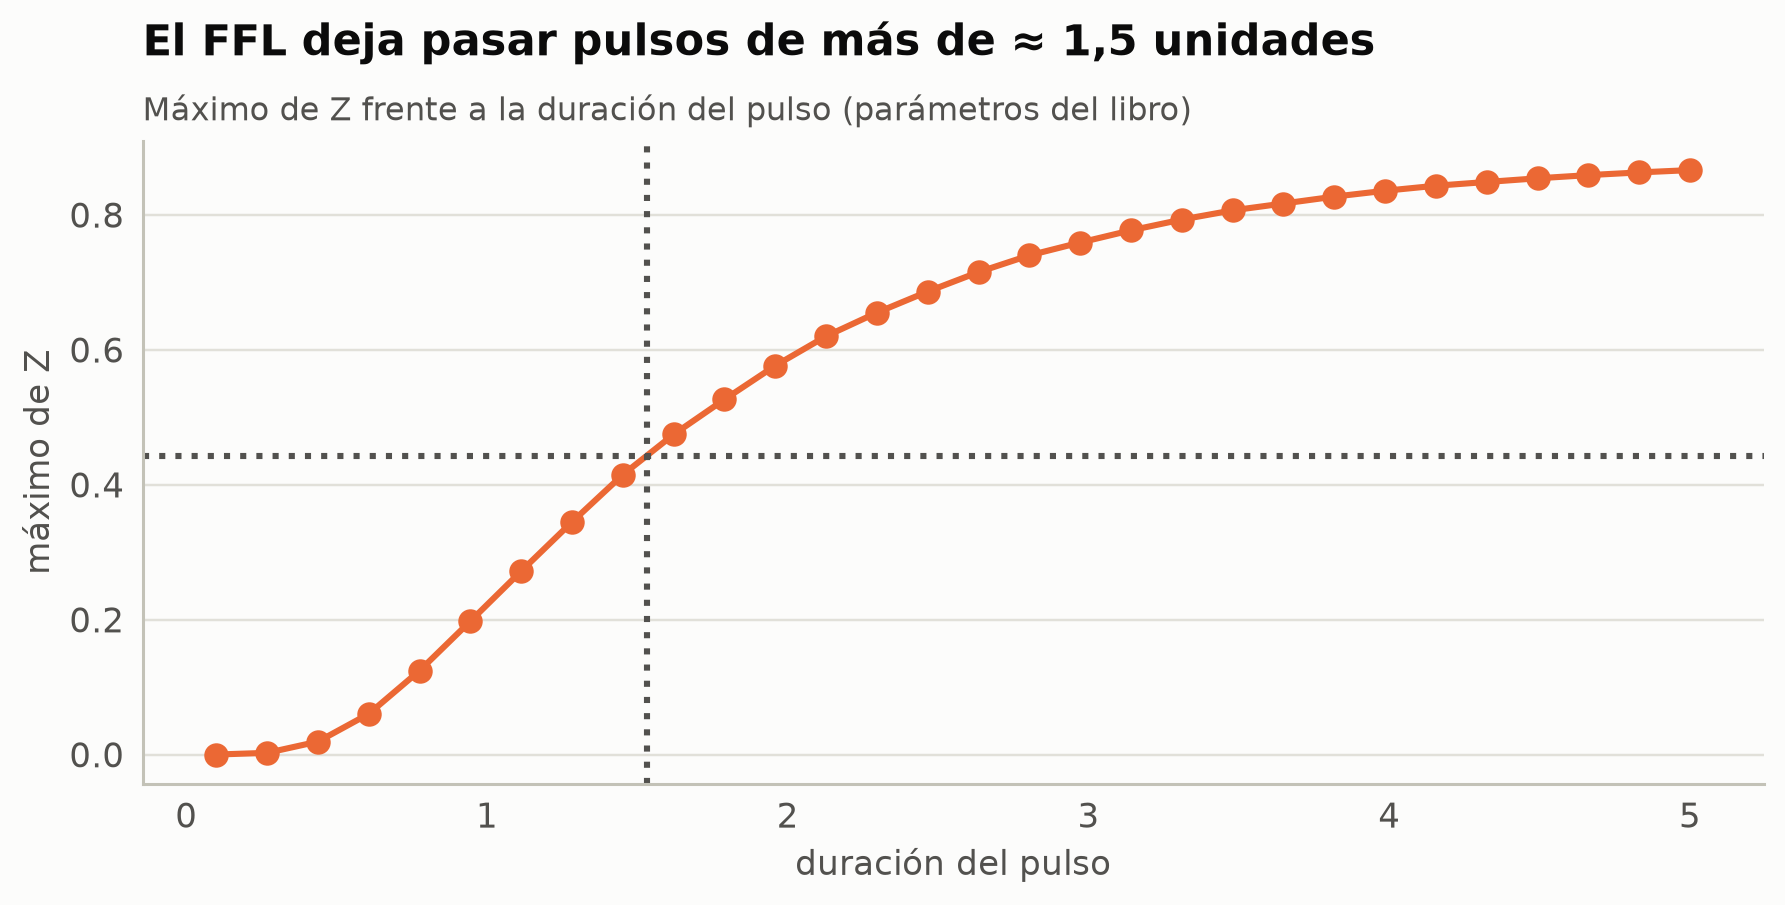

duración con la mitad del máximo: 1.53 (Y necesita ≈ ln2 = 0,69 solo para cruzar K_yz)


In [42]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
durs_e = np.linspace(0.1, 5, 30)
tt_e = np.linspace(0, 12, 481)
zmax = np.array([ffl(tt_e, 1.0, 1.0 + d)[1].max() for d in durs_e])
z_inf = ffl(tt_e, 1.0, 11.0)[1].max()
d_half = np.interp(0.5 * z_inf, zmax, durs_e)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(durs_e, zmax, "o-", color=ec.ORANGE)
ax.axhline(0.5 * z_inf, ls=":", color=ec.INK_2); ax.axvline(d_half, ls=":", color=ec.INK_2)
ax.set_xlabel("duración del pulso"); ax.set_ylabel("máximo de Z")
ec.title(ax, f"El FFL deja pasar pulsos de más de ≈ {d_half:.1f} unidades".replace(".", ","),
         "Máximo de Z frente a la duración del pulso (parámetros del libro)")
plt.show()
print(f"duración con la mitad del máximo: {d_half:.2f} (Y necesita ≈ ln2 = 0,69 solo para cruzar K_yz)")

In [43]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
# Diagonal: u(1+u^3) = α; a = b = 3αu^2/(1+u^3)^2 = 3u^3/(1+u^3).  Silla si a > 1  <=>  u^3 > 1/2.
u_c = 0.5 ** (1 / 3)
a_c = u_c * (1 + u_c ** 3)
print(f"u_c = 2^(-1/3) = {u_c:.4f};  α crítico = 1,5 · 2^(-1/3) = {a_c:.4f}")
for a in (a_c - 0.02, a_c + 0.02, 1.5, 3):
    print(f"α = {a:.3f}: {len(toggle_fixed_points(a, a, 3.0, 3.0, npts=100001))} puntos fijos")

u_c = 2^(-1/3) = 0.7937;  α crítico = 1,5 · 2^(-1/3) = 1.1906
α = 1.171: 1 puntos fijos
α = 1.211: 3 puntos fijos
α = 1.500: 3 puntos fijos
α = 3.000: 3 puntos fijos


In [44]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
lam = ev[np.argmax(ev.real)]
print(f"λ = {lam:.3f};  2π/ω = {2 * np.pi / lam.imag:.2f}  frente a periodo simulado {period:.2f}")
# Cerca de la frontera la oscilación es pequeña y casi lineal: su periodo se acerca a 2π/ω.
b_e = 5.0
a_front = alpha_min(b_e) * 1.05
p_e = brentq(lambda q: q - a_front / (1 + q * q), 0, a_front + 1)
X_e = a_front * 2 * p_e / (1 + p_e ** 2) ** 2
lam_e = max(np.linalg.eigvals(rep_jacobian(X_e, b_e)), key=lambda z: z.real)
s_e = solve_ivp(lambda t, y: repressilator(t, y, a=a_front, a0=0.0, b=b_e), (0, 600), [p_e + 0.1, p_e, p_e, p_e, p_e, p_e],
                t_eval=np.linspace(400, 600, 8001), rtol=1e-9, atol=1e-9)
pk_e, _ = find_peaks(s_e.y[3])
print(f"α = {a_front:.2f} (5 % sobre la frontera): 2π/ω = {2 * np.pi / abs(lam_e.imag):.2f}, "
      f"periodo simulado = {np.diff(s_e.t[pk_e]).mean():.2f}")
print("Lejos de la frontera, la oscilación es de gran amplitud y no lineal: las proteínas pasan largos ratos casi a cero"
      " o saturadas, y el ciclo se alarga respecto de la predicción lineal.")

λ = 0.208+1.266j;  2π/ω = 4.96  frente a periodo simulado 8.68


α = 7.76 (5 % sobre la frontera): 2π/ω = 5.69, periodo simulado = 5.76
Lejos de la frontera, la oscilación es de gran amplitud y no lineal: las proteínas pasan largos ratos casi a cero o saturadas, y el ciclo se alarga respecto de la predicción lineal.


In [45]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
def switching_times(Om, T, seed):
    ts_, us_, vs_ = ssa_toggle(Om, T, np.random.default_rng(seed))
    cur, t_last, dwell = None, 0.0, []
    for t_, u_, v_ in zip(ts_, us_, vs_):
        new = "U" if (u_ >= 5 * Om and v_ <= Om) else ("V" if (v_ >= 5 * Om and u_ <= Om) else None)
        if new and new != cur:
            if cur is not None:
                dwell.append(t_ - t_last)
            cur, t_last = new, t_
    return dwell

rows = []
for Om in (0.5, 1.0, 1.5):
    d = switching_times(Om, 3000, 11)
    rows.append((Om, len(d), np.mean(d) if d else np.nan))
    print(f"Ω = {Om}: {len(d)} conmutaciones en 3000 unidades; tiempo medio de permanencia ≈ {np.mean(d):.0f}")
print("El tiempo de permanencia crece aproximadamente de forma exponencial con Ω (una barrera que escala con el tamaño).")

Ω = 0.5: 128 conmutaciones en 3000 unidades; tiempo medio de permanencia ≈ 23


Ω = 1.0: 33 conmutaciones en 3000 unidades; tiempo medio de permanencia ≈ 88


Ω = 1.5: 11 conmutaciones en 3000 unidades; tiempo medio de permanencia ≈ 241


El tiempo de permanencia crece aproximadamente de forma exponencial con Ω (una barrera que escala con el tamaño).


In [46]:
#@title 🔑 Solución — Ejercicio 7 { display-mode: "form" }
# Con RECOMPUTE_REGULONDB = True se calcula en la sección 5 a partir de las aristas:
#   outdeg = edges[edges.src != edges.gene].groupby("tf").size().sort_values(ascending=False)
#   top_genes = {tf_gene[t] or t for t in outdeg.head(10).index};  ffl_df.X.isin(top_genes).mean()
top10 = pd.Series(R["top10_grado_salida"], name="dianas").rename_axis("tf")
print(top10.to_string())
print(f"\nFFL con un regulador global como X: {R['frac_ffl_global']:.0%} de {R['n_ffl']}")

tf
CRP     545
FNR     302
Fis     238
IHF     232
H-NS    199
ArcA    180
Fur     131
NarL    125
Lrp     105
NsrR     86

FFL con un regulador global como X: 72% de 2176


## 📌 Resumen

* Una red de regulación génica es **dirigida y con signo**. La respuesta de un promotor se modela con la **función de
  Hill**; la cooperatividad $n$ la vuelve abrupta: $X_{90}/X_{10}=81^{1/n}$ (81, 9 y 3 para $n=1,2,4$).
* En $\dot Y=\beta-\alpha Y$ el tiempo de respuesta es $t_{1/2}=\ln2/\alpha$, **independiente de la producción**. En *E. coli*
  con $\tau=30$ min: 30 min para una proteína estable, 20 min con vida media de 60 min y 4,3 min con vida media de 5 min
  (a costa de sintetizar 7 veces más).
* La **autorregulación negativa** acelera sin desperdiciar: con $K=0{,}3X_{\text{est}}$, $n=2$ y $\beta'=12{,}1\beta$,
  $t_{1/2}=0{,}0855/\alpha$ (8,1 veces más rápido); además amortigua el ruido: $X_{\text{est}}\propto\beta^{1/(n+1)}$.
  En RegulonDB 11.0 se autorregulan al menos el 59 % de los factores de *E. coli* (el 77 % de los que asociamos a
  su gen), la mayoría negativamente.
* Los **motivos de red** se detectan con $Z=(N_{\text{real}}-\langle N_{\text{azar}}\rangle)/\sigma_{\text{azar}}$ frente a
  redes que conservan los grados. En *E. coli* el FFL tiene $Z$ de más de diez desviaciones; los ciclos son rarísimos.
* El **FFL coherente tipo 1 con AND** filtra pulsos breves (máx $Z\approx0{,}03$ ante un pulso de 0,5) y es un retardo
  sensible al signo: enciende con retraso (1,46 frente a 0,69) y apaga sin él (0,70).
* La represión mutua cooperativa crea **biestabilidad**: con $\alpha_1=\alpha_2=10$ y $\beta=\gamma=2$ hay dos estados
  estables ($\lambda=-0{,}8,-1{,}2$) y una silla en $(2,2)$ ($\lambda=+0{,}6,-2{,}6$); hace falta $\alpha>2$ y cooperatividad.
* Un ciclo de tres represores **oscila** si $(\beta+1)^2/\beta<3X^2/(4-2X)$: con $\alpha=216$, $\beta=5$, $n=2$, periodo
  8,7 y autovalores $0{,}208\pm1{,}266i$; con $n=1$ no puede oscilar.
* Con pocas moléculas la expresión es **estocástica**: el algoritmo de Gillespie genera trayectorias exactas; en
  nacimiento y muerte la distribución es Poisson con $\mathrm{CV}=1/\sqrt{\mu}$ (0,318 simulado frente a 0,316). El
  ruido puede conmutar un interruptor.
* **Inferir** redes de la expresión es difícil: GENIE3 (AUPR $\approx0{,}54$) apenas supera a la correlación ($\approx0{,}53$),
  ambos el doble del azar; la integración de métodos y los datos de perturbación y unión al ADN son la vía robusta.

## 📚 Lecturas recomendadas

* Alon, U. (2019). *An introduction to systems biology: Design principles of biological circuits* (2.ª ed.). CRC Press.
  https://doi.org/10.1201/9780429283321
* Johnson, K. A. y Goody, R. S. (2011). The original Michaelis constant: Translation of the 1913 Michaelis–Menten paper.
  *Biochemistry*, 50(39), 8264–8269. https://doi.org/10.1021/bi201284u
* Rosenfeld, N., Elowitz, M. B. y Alon, U. (2002). Negative autoregulation speeds the response times of transcription
  networks. *Journal of Molecular Biology*, 323(5), 785–793. https://doi.org/10.1016/S0022-2836(02)00994-4
* Milo, R., Shen-Orr, S., Itzkovitz, S., Kashtan, N., Chklovskii, D. y Alon, U. (2002). Network motifs: Simple building
  blocks of complex networks. *Science*, 298(5594), 824–827. https://doi.org/10.1126/science.298.5594.824
* Shen-Orr, S. S., Milo, R., Mangan, S. y Alon, U. (2002). Network motifs in the transcriptional regulation network of
  *Escherichia coli*. *Nature Genetics*, 31(1), 64–68. https://doi.org/10.1038/ng881
* Mangan, S. y Alon, U. (2003). Structure and function of the feed-forward loop network motif. *PNAS*, 100(21),
  11980–11985. https://doi.org/10.1073/pnas.2133841100
* Alon, U. (2007). Network motifs: Theory and experimental approaches. *Nature Reviews Genetics*, 8(6), 450–461.
  https://doi.org/10.1038/nrg2102
* Gardner, T. S., Cantor, C. R. y Collins, J. J. (2000). Construction of a genetic toggle switch in *Escherichia coli*.
  *Nature*, 403(6767), 339–342. https://doi.org/10.1038/35002131
* Elowitz, M. B. y Leibler, S. (2000). A synthetic oscillatory network of transcriptional regulators. *Nature*,
  403(6767), 335–338. https://doi.org/10.1038/35002125
* Elowitz, M. B., Levine, A. J., Siggia, E. D. y Swain, P. S. (2002). Stochastic gene expression in a single cell.
  *Science*, 297(5584), 1183–1186. https://doi.org/10.1126/science.1070919
* Gillespie, D. T. (1977). Exact stochastic simulation of coupled chemical reactions. *The Journal of Physical
  Chemistry*, 81(25), 2340–2361. https://doi.org/10.1021/j100540a008
* Huynh-Thu, V. A., Irrthum, A., Wehenkel, L. y Geurts, P. (2010). Inferring regulatory networks from expression data
  using tree-based methods. *PLoS ONE*, 5(9), e12776. https://doi.org/10.1371/journal.pone.0012776
* Marbach, D., Costello, J. C., Küffner, R. et al. (2012). Wisdom of crowds for robust gene network inference. *Nature
  Methods*, 9(8), 796–804. https://doi.org/10.1038/nmeth.2016
* Tierrafría, V. H. et al. (2022). RegulonDB 11.0: Comprehensive high-throughput datasets on transcriptional regulation
  in *Escherichia coli* K-12. *Microbial Genomics*, 8(5). https://doi.org/10.1099/mgen.0.000833

In [47]:
print(f"Tiempo total de ejecución del notebook: {time.time() - T0_NOTEBOOK:.0f} s")

Tiempo total de ejecución del notebook: 37 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)